# From forecasts to promotion decisions

This notebook takes a probabilistic demand model all the way to a set of promotion decisions. The data are the dunnhumby [*Breakfast at the Frat*](https://www.dunnhumby.com/source-files/) scanner panel: weekly unit sales, shelf and base prices, and the promotion mechanics (in-store circular feature, in-store display, and shelf-tag-only price cuts) for products in four categories across 77 stores over 156 weeks, read here from the [figshare copy](https://doi.org/10.6084/m9.figshare.30121060) of the workbook. We work with six cereals of one substitution group and ask the question a category manager and a replenishment planner face every quarter: what should a promotion of Honey Nut Cheerios look like, who should fund it, and how much stock should each store order for it?

**Under the retailer's margin and a nominal funding share from the manufacturer, expected profit falls with discount depth for every promotion mechanics, so a point forecast and the posterior pick the same corner of the price grid. The posterior earns its keep elsewhere: the right expectation through partial pooling across stores, a break-even funding share with a credible interval, a downside and a tie-breaker where the objective is flat, and an order quantity from joint demand paths rather than from summed marginal quantiles.**

The algebra behind the first sentence is short. With gross margin $g$ on the base price and a manufacturer that funds a share $\alpha$ of the discount on every unit sold in a promotion week, a deeper cut raises expected profit only if the promotional elasticity under the chosen mechanics satisfies $\varepsilon_m < -(1 - \alpha) / g$. We estimate $\varepsilon_m$ with its posterior and read the decision off that inequality, with the cannibalization of the sibling products included. The funding and go/no-go questions belong to the category manager; the order quantity belongs to the replenishment planner once the promotion is committed. We proceed in five steps. First, we read and inspect the panel, count the weeks that identify a price effect separately from the promotion mechanics, and write down the causal assumption. Second, we specify a hierarchical negative binomial demand model with own and cross price elasticities as reusable components, choose its parameterization with a short SVI pass, and fit it with NUTS. Third, we check the fit in sample and on a holdout quarter. Fourth, we forecast counterfactual promotions by editing the horizon covariates and reusing the posterior. Fifth, we turn the forecasts into the funding, mechanics, risk and order decisions.

The model uses the package's model building blocks:

- [`Horizon.from_data`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html) derives the train and forecast windows from the shapes of the covariates and the data.
- [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html) samples the weekly level innovations for every store-product series, with a separate site for the forecast horizon.
- [`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html) attaches the negative binomial likelihood to the observed weeks and samples the horizon.

The prediction drivers and evaluation helpers do the rest: [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html) and [`predict_in_sample`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.predict_in_sample.html) draw the holdout and in-sample predictives, [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html) and [`predictions_to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.predictions_to_datatree.html) export draws to ArviZ, [`fourier_features`](https://juanitorduz.github.io/numpyro_forecast/reference/features.fourier_features.html) builds the annual seasonality basis, and [`eval_crps`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.eval_crps.html), [`eval_coverage`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.eval_coverage.html) and [`make_mase`](https://juanitorduz.github.io/numpyro_forecast/reference/metrics.make_mase.html) score the forecasts.

Two things this notebook does not claim. Prices were never randomized, so every elasticity rests on a selection-on-observables assumption that we state explicitly and cannot test. And the holdout validates the forecasting engine under the realized promotion calendar, not the counterfactual calendars, which nobody observed.

## Prepare notebook

In [1]:
import hashlib
import urllib.request
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import cast

# preliz warns at import time that PyMC is absent; the example does not need it.
warnings.filterwarnings("ignore", message="PyMC not installed", category=UserWarning)

import arviz as az
import graphviz as gr
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import polars as pl
import preliz as pz
import xarray as xr
from jax import random
from jax.typing import ArrayLike
from jaxtyping import Float, Int
from matplotlib import ticker as mtick
from matplotlib.axes import Axes
from numpyro import handlers
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO, init_to_median
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    eval_coverage,
    eval_crps,
    eval_mae,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.metrics import crps_empirical, make_mase
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
warnings.filterwarnings(
    "ignore", message="When multiple credible intervals are plotted", category=UserWarning
)

# Render polars tables without truncating string cells, and drop the shape and
# dtype headers, which are noise in a rendered document.
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

dunnhumby publishes the workbook on its source-files page behind a form. We download the copy that [Ghaedrahmati (2025)](https://doi.org/10.6084/m9.figshare.30121060) deposited on figshare, whose record declares a CC BY 4.0 license for the copy; dunnhumby's own terms govern the data. The download is cached under the home directory and verified against its SHA-256 digest, so the notebook reads the same bytes on every run. Every data sheet carries a title row above the header, which is why the reader skips one row.

In [2]:
DATA_SHA256 = "61b1d77dd6d9298fed204cc231f2b853a4c7f79376cfc30231646e1e51d0daba"
cache_dir = Path.home() / ".cache" / "numpyro_forecast"
cache_dir.mkdir(parents=True, exist_ok=True)
workbook_path = cache_dir / "breakfast_at_the_frat.xlsx"
if not workbook_path.exists():
    urllib.request.urlretrieve("https://ndownloader.figshare.com/files/57937129", workbook_path)
digest = hashlib.sha256(workbook_path.read_bytes()).hexdigest()
if digest != DATA_SHA256:
    msg = f"unexpected workbook digest {digest}"
    raise ValueError(msg)

sheets = pl.read_excel(
    workbook_path,
    sheet_name=["dh Transaction Data", "dh Products Lookup", "dh Store Lookup"],
    engine="calamine",
    read_options={"header_row": 1},
)
transactions_raw = sheets["dh Transaction Data"]
products_df = sheets["dh Products Lookup"]
stores_raw = sheets["dh Store Lookup"]

print(
    f"transactions: {transactions_raw.height:,} rows | "
    f"{transactions_raw['STORE_NUM'].n_unique()} stores | "
    f"{transactions_raw['UPC'].n_unique()} UPCs | "
    f"{transactions_raw['WEEK_END_DATE'].n_unique()} weeks from "
    f"{transactions_raw['WEEK_END_DATE'].min()} to {transactions_raw['WEEK_END_DATE'].max()}"
)
print(f"products lookup: {products_df.height} rows | store lookup: {stores_raw.height} rows")
transactions_raw.head(3)

transactions: 524,950 rows | 77 stores | 55 UPCs | 156 weeks from 2009-01-14 to 2012-01-04
products lookup: 58 rows | store lookup: 79 rows


WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY
2009-01-14,367,1111009477,13,13,13,18.07,1.39,1.57,0,0,1
2009-01-14,367,1111009497,20,18,18,27.8,1.39,1.39,0,0,0
2009-01-14,367,1111009507,14,14,14,19.32,1.38,1.38,0,0,0


Three quirks of the workbook matter for what follows. A few rows have a missing price, a handful have non-positive units, and about one row in a hundred has a shelf price above the base price, which is a lagged base-price update rather than a mark-up. We treat a ratio above one as no discount and keep the asymmetry in mind: a ratio below one always reads as a temporary cut, so a permanent price drop recorded before its base-price update would look like a promotion. The store lookup also lists two store ids twice with different price-segment labels, which would duplicate every row of those stores on a join, so we keep the first row per store. The printed counts: $524{,}950$ transaction rows over 77 stores, 55 products and 156 weeks; 185 rows without a base price and 23 without a shelf price; five rows with non-positive units; $1.2\%$ of the rows with a shelf price above the base price; two duplicated store ids, and 77 stores after the dedupe, 43 mainstream, 15 upscale and 19 value.

In [3]:
price_ratio_raw = transactions_raw["PRICE"] / transactions_raw["BASE_PRICE"]
quirks = pl.DataFrame(
    {
        "quirk": [
            "missing BASE_PRICE",
            "missing PRICE",
            "UNITS <= 0",
            "PRICE > BASE_PRICE",
        ],
        "rows": [
            transactions_raw["BASE_PRICE"].null_count(),
            transactions_raw["PRICE"].null_count(),
            int((transactions_raw["UNITS"] <= 0).sum()),
            int((price_ratio_raw > 1.0).sum()),
        ],
    }
).with_columns(share=(pl.col("rows") / transactions_raw.height))
quirks

quirk,rows,share
"""missing BASE_PRICE""",185,0.000352
"""missing PRICE""",23,0.000044
"""UNITS <= 0""",5,0.00001
"""PRICE > BASE_PRICE""",6047,0.011519


In [4]:
duplicated_stores = stores_raw.filter(pl.col("STORE_ID").is_duplicated())
stores_df = stores_raw.unique(subset="STORE_ID", keep="first", maintain_order=True)
print(f"duplicated store ids: {duplicated_stores['STORE_ID'].n_unique()} (rows kept: first)")
print(duplicated_stores.select("STORE_ID", "STORE_NAME", "SEG_VALUE_NAME"))
segment_counts = stores_df.group_by("SEG_VALUE_NAME").len().sort("SEG_VALUE_NAME")
print(f"stores after the dedupe: {stores_df.height}")
segment_counts

duplicated store ids: 2 (rows kept: first)
┌──────────┬──────────────┬────────────────┐
│ STORE_ID ┆ STORE_NAME   ┆ SEG_VALUE_NAME │
╞══════════╪══════════════╪════════════════╡
│ 4503     ┆ ROCKWALL     ┆ MAINSTREAM     │
│ 17627    ┆ FLOWER MOUND ┆ MAINSTREAM     │
│ 17627    ┆ FLOWER MOUND ┆ UPSCALE        │
│ 4503     ┆ ROCKWALL     ┆ UPSCALE        │
└──────────┴──────────────┴────────────────┘
stores after the dedupe: 77


SEG_VALUE_NAME,len
"""MAINSTREAM""",43
"""UPSCALE""",15
"""VALUE""",19


## A first look at prices and promotions

### Why these six products

Missing store-product-weeks are absent rows, never recorded zeros, so a product that a store stops carrying simply disappears for a while. The table below counts, for every cold cereal, the stores that carry it and the stores that carry it in all weeks. The Post and Quaker products have delisting gaps in every store, so we keep the six products of the `ALL FAMILY CEREAL` sub-category from General Mills, Kellogg and the private label: one substitution group, complete in dozens of stores, with a private-label twin of the focal product. The six are carried in all 77 stores and complete in 62 to 75 of them.

In [5]:
N_WEEKS = transactions_raw["WEEK_END_DATE"].n_unique()
cereal_all = transactions_raw.join(products_df, on="UPC").filter(
    pl.col("CATEGORY") == "COLD CEREAL"
)


def weeks_per_series(df: pl.DataFrame, keys: list[str]) -> pl.DataFrame:
    """Count the distinct weeks of every series keyed by ``keys``."""
    return df.group_by(keys).agg(weeks=pl.col("WEEK_END_DATE").n_unique())


completeness = (
    cereal_all.pipe(weeks_per_series, ["UPC", "STORE_NUM"])
    .group_by("UPC")
    .agg(
        stores_carrying=pl.len(),
        stores_complete=(pl.col("weeks") == N_WEEKS).sum(),
        min_weeks=pl.col("weeks").min(),
    )
    .join(products_df.select("UPC", "DESCRIPTION", "MANUFACTURER", "SUB_CATEGORY"), on="UPC")
    .sort("stores_complete", "UPC", descending=[True, False])
    .select(
        "UPC",
        "DESCRIPTION",
        "MANUFACTURER",
        "SUB_CATEGORY",
        "stores_carrying",
        "stores_complete",
        "min_weeks",
    )
)
completeness

UPC,DESCRIPTION,MANUFACTURER,SUB_CATEGORY,stores_carrying,stores_complete,min_weeks
1600027527,"""GM HONEY NUT CHEERIOS""","""GENERAL MI""","""ALL FAMILY CEREAL""",77,75,131
1600027528,"""GM CHEERIOS""","""GENERAL MI""","""ALL FAMILY CEREAL""",77,73,131
3800031838,"""KELL FROSTED FLAKES""","""KELLOGG""","""KIDS CEREAL""",77,73,131
1111085345,"""PL RAISIN BRAN""","""PRIVATE LABEL""","""ADULT CEREAL""",77,71,131
1600027564,"""GM CHEERIOS""","""GENERAL MI""","""ALL FAMILY CEREAL""",77,71,131
3800031829,"""KELL BITE SIZE MINI WHEAT""","""KELLOGG""","""ALL FAMILY CEREAL""",77,69,83
1111085350,"""PL BT SZ FRSTD SHRD WHT""","""PRIVATE LABEL""","""ALL FAMILY CEREAL""",77,66,131
1111085319,"""PL HONEY NUT TOASTD OATS""","""PRIVATE LABEL""","""ALL FAMILY CEREAL""",77,62,131
3800039118,"""KELL FROOT LOOPS""","""KELLOGG""","""KIDS CEREAL""",77,58,120
3000006340,"""QKER LIFE ORIGINAL""","""QUAKER""","""ALL FAMILY CEREAL""",77,0,41


In [6]:
PRODUCT_LABELS = {
    1600027527: "HNC",
    1600027564: "Cheerios 12oz",
    1600027528: "Cheerios 18oz",
    3800031829: "Mini Wheats",
    1111085319: "PL Honey Nut Oats",
    1111085350: "PL Frosted Wheat",
}
product_order: list[str] = list(PRODUCT_LABELS.values())
n_products = len(product_order)
FOCAL = "HNC"
FOCAL_INDEX = product_order.index(FOCAL)


def keep_panel_products(df: pl.DataFrame, labels: dict[int, str]) -> pl.DataFrame:
    """Keep the labeled UPCs and add their short product label."""
    return df.filter(pl.col("UPC").is_in(list(labels))).with_columns(
        product=pl.col("UPC").replace_strict(labels, return_dtype=pl.String)
    )


def join_lookups(df: pl.DataFrame, products: pl.DataFrame, stores: pl.DataFrame) -> pl.DataFrame:
    """Join the product lookup on the UPC and the deduplicated store lookup on the store id."""
    return df.join(products, on="UPC").join(stores, left_on="STORE_NUM", right_on="STORE_ID")


def log_price_ratio() -> pl.Expr:
    """Take the log of shelf over base price, capped at one so a lagged base price is no cut."""
    return (pl.col("PRICE") / pl.col("BASE_PRICE")).clip(upper_bound=1.0).log()


def add_price_columns(df: pl.DataFrame) -> pl.DataFrame:
    """Add the discount, the log price ratio ``x`` and the log depth ``lam``."""
    return df.with_columns(
        discount=1.0 - pl.col("PRICE") / pl.col("BASE_PRICE"), x=log_price_ratio()
    ).with_columns(lam=-pl.col("x"))


def mechanics_label() -> pl.Expr:
    """Label a store-week by its mechanics from the feature, display and shelf-tag flags."""
    feature = pl.col("FEATURE") == 1
    display = pl.col("DISPLAY") == 1
    return (
        pl.when(feature & display)
        .then(pl.lit("feature + display"))
        .when(feature)
        .then(pl.lit("feature"))
        .when(display)
        .then(pl.lit("display"))
        .when(pl.col("TPR_ONLY") == 1)
        .then(pl.lit("TPR-only"))
        .otherwise(pl.lit("none"))
    )


def add_promotion_columns(df: pl.DataFrame) -> pl.DataFrame:
    """Add the series id, cut flag, mechanics label, feature-display interaction and log units."""
    return df.with_columns(
        series=pl.concat_str([pl.col("STORE_NUM"), pl.col("product")], separator="::"),
        cut=(pl.col("discount") > 0.02).cast(pl.Int64),
        mechanics=mechanics_label(),
        feature_display=pl.col("FEATURE") * pl.col("DISPLAY"),
        log_units=pl.col("UNITS").cast(pl.Float64).log(),
    )


cereal_df = (
    transactions_raw.pipe(keep_panel_products, PRODUCT_LABELS)
    .pipe(join_lookups, products_df, stores_df)
    .drop_nulls(["PRICE", "BASE_PRICE"])
    .filter(pl.col("UNITS") > 0)
    .pipe(add_price_columns)
    .pipe(add_promotion_columns)
    .sort("STORE_NUM", "product", "WEEK_END_DATE")
)
n_before = transactions_raw.pipe(keep_panel_products, PRODUCT_LABELS).height
tpr_definition = (cereal_df["TPR_ONLY"] == 1) == (
    (cereal_df["cut"] == 1) & (cereal_df["FEATURE"] == 0) & (cereal_df["DISPLAY"] == 0)
)
print(f"six-product rows: {cereal_df.height:,} of {n_before:,} before dropping missing prices")
print(f"TPR_ONLY == 1 exactly when discount > 2% and no mechanics: {bool(tpr_definition.all())}")
print(
    f"rows with PRICE > BASE_PRICE (read as no discount): {(cereal_df['discount'] < 0).to_numpy().mean():.1%}"
)

six-product rows: 71,774 of 71,774 before dropping missing prices
TPR_ONLY == 1 exactly when discount > 2% and no mechanics: True
rows with PRICE > BASE_PRICE (read as no discount): 0.5%


### Promotions work through mechanics far more than through price

The flags mean the following. `FEATURE` marks a week in which the product appeared in the store circular, `DISPLAY` a week with an in-store display, and `TPR_ONLY` a temporary price reduction with a shelf tag and nothing else. Almost every feature week also carries a price cut; the mechanics table shows that the cut alone moves units far less than a feature or a display does, the empirical regularity that [Blattberg, Briesch and Fox (1995)](https://doi.org/10.1287/mksc.14.3.G122) list among the generalizations about how promotions work. It also shows the identification problem: because cuts and mechanics arrive together, a regression of units on price alone credits the mechanics' uplift to the price. The printed table over all 77 stores: store-weeks without mechanics average 31 units, shelf-tag cuts 40, displays 73, features 74, and feature with display 135, at mean depths of $18\%$ to $26\%$; $97\%$ of the feature-with-display weeks carry a cut, the shelf-tag flag is exactly a cut of more than $2\%$ without mechanics in every row, and $0.5\%$ of the six-product rows have a shelf price above the base price.

In [7]:
def cut_depth() -> pl.Expr:
    """Clip the discount at zero, so a shelf price above the base price reads as no cut."""
    return pl.col("discount").clip(lower_bound=0.0)


def sort_by_order(df: pl.DataFrame, column: str, order: list[str]) -> pl.DataFrame:
    """Sort the rows by the position of ``column`` in ``order``."""
    position = {value: i for i, value in enumerate(order)}
    return (
        df.with_columns(order=pl.col(column).replace_strict(position)).sort("order").drop("order")
    )


mechanics_order = ["none", "TPR-only", "display", "feature", "feature + display"]
mechanics_table = (
    cereal_df.group_by("mechanics")
    .agg(
        store_weeks=pl.len(),
        share_with_cut=pl.col("cut").mean(),
        mean_depth=cut_depth().mean(),
        mean_units=pl.col("UNITS").mean(),
    )
    .pipe(sort_by_order, "mechanics", mechanics_order)
)
mechanics_table

mechanics,store_weeks,share_with_cut,mean_depth,mean_units
"""none""",53777,0.0,0.0,30.776689
"""TPR-only""",10584,1.0,0.191906,39.888983
"""display""",1542,0.80415,0.188167,73.227626
"""feature""",2750,0.858909,0.176457,74.496727
"""feature + display""",3121,0.9686,0.260721,134.880167


In [8]:
def within_ols(
    frame: pl.DataFrame, columns: list[str], target: str = "log_units", by: str = "series"
) -> pl.DataFrame:
    """Within-group least squares (every column demeaned by ``by``) with classical standard errors.

    Parameters
    ----------
    frame
        Long table with one row per store-product-week.
    columns
        Regressor columns.
    target
        Response column.
    by
        Grouping column whose fixed effects are removed by demeaning.

    Returns
    -------
    pl.DataFrame
        One row per regressor with its coefficient and standard error.
    """
    demeaned = frame.select(
        [(pl.col(c) - pl.col(c).mean().over(by)).alias(c) for c in [target, *columns]]
    )
    design = demeaned.select(columns).to_numpy().astype(np.float64)
    response = demeaned[target].to_numpy().astype(np.float64)
    beta, *_ = np.linalg.lstsq(design, response, rcond=None)
    residual = response - design @ beta
    dof = response.size - design.shape[1] - frame[by].n_unique()
    covariance = (residual @ residual / dof) * np.linalg.pinv(design.T @ design)
    standard_error = np.sqrt(np.clip(np.diag(covariance), 0.0, None))
    return pl.DataFrame({"term": columns, "coef": beta, "se": standard_error})


def annual_fourier(week: str, period: float = 52.18) -> list[pl.Expr]:
    """Build the annual Fourier terms sin1, cos1, sin2, cos2 of a week-index column."""
    terms = []
    for harmonic in (1, 2):
        angle = 2.0 * harmonic * np.pi * pl.col(week) / period
        terms += [angle.sin().alias(f"sin{harmonic}"), angle.cos().alias(f"cos{harmonic}")]
    return terms


def any_promotion() -> pl.Expr:
    """Flag a store-week with a feature, a display or a cut, as a float."""
    promoted = (pl.col("FEATURE") == 1) | (pl.col("DISPLAY") == 1) | (pl.col("cut") == 1)
    return promoted.cast(pl.Float64)


first_week = cereal_df["WEEK_END_DATE"].min()
cereal_df = cereal_df.with_columns(
    week_index=((pl.col("WEEK_END_DATE") - pl.lit(first_week)).dt.total_days() / 7.0)
).with_columns(
    *annual_fourier("week_index"), trend=pl.col("week_index") / N_WEEKS, promo=any_promotion()
)
seasonal_terms = ["sin1", "cos1", "sin2", "cos2", "trend"]

### Do promotions borrow from the following weeks?

A promotion that loads the pantry depresses the weeks after it, the post-promotion dip of [van Heerde, Leeflang and Wittink (2000)](https://doi.org/10.1509/jmkr.37.3.383.18782). If the dip were large, the timing of promotion weeks would matter and the decision space would include the calendar. We check it with a within-series regression of log units on the price ratio, the mechanics, and indicators for the one and two weeks after any promotion, controlling for annual seasonality and a trend. The dip is $+0.8\%$ (standard error $0.5\%$) in the first week after a promotion and $-1.6\%$ (standard error $0.4\%$) in the second, against feature and display effects of $+0.51$ and $+0.46$ on the log scale: statistically visible, economically negligible. The calendar is therefore not a lever in this notebook.

In [9]:
dip_df = cereal_df.with_columns(
    post1=pl.col("promo").shift(1).over("series").fill_null(0.0),
    post2=pl.col("promo").shift(2).over("series").fill_null(0.0),
)
dip_ols = within_ols(
    dip_df, ["x", "FEATURE", "DISPLAY", "feature_display", "post1", "post2", *seasonal_terms]
)
dip_ols.filter(
    pl.col("term").is_in(["x", "FEATURE", "DISPLAY", "feature_display", "post1", "post2"])
)

term,coef,se
"""x""",-0.891461,0.015639
"""FEATURE""",0.507507,0.008564
"""DISPLAY""",0.457711,0.011262
"""feature_display""",0.075924,0.015563
"""post1""",0.008233,0.004645
"""post2""",-0.016333,0.00434


### The realized calendar of the holdout quarter

The last 13 weeks of the panel (October 2011 to the first week of January 2012) are the holdout and, later, the horizon on which we evaluate counterfactual promotions. The table shows, for the focal product, the share of stores with a feature, a display or a shelf-tag-only cut in every horizon week, and the mean discount depth. The realized calendar ran a feature with display at about a $15\%$ cut in the two Thanksgiving weeks and a deeper cut around Christmas. In horizon weeks 7 and 8 every store featured the product, $84\%$ and $69\%$ of the stores displayed it, and the mean depth was $14\%$; weeks 11 to 13 carried a $31\%$ cut with a feature in every store.

In [10]:
all_weeks = cereal_df["WEEK_END_DATE"].unique().sort()
HORIZON = 13
t_train = N_WEEKS - HORIZON
holdout_weeks = all_weeks[t_train:]
realized_calendar = (
    cereal_df.filter(
        (pl.col("product") == FOCAL) & pl.col("WEEK_END_DATE").is_in(holdout_weeks.to_list())
    )
    .group_by("WEEK_END_DATE")
    .agg(
        feature=pl.col("FEATURE").mean(),
        display=pl.col("DISPLAY").mean(),
        tpr_only=pl.col("TPR_ONLY").mean(),
        depth=cut_depth().mean(),
    )
    .sort("WEEK_END_DATE")
    .with_row_index("horizon_week", offset=1)
)
realized_calendar

horizon_week,WEEK_END_DATE,feature,display,tpr_only,depth
1,2011-10-12,0.0,0.0,0.0,0.0
2,2011-10-19,0.0,0.0,0.142857,0.025053
3,2011-10-26,0.0,0.012987,0.0,0.0
4,2011-11-02,0.0,0.0,0.0,0.0
5,2011-11-09,0.0,0.0,0.077922,0.009592
6,2011-11-16,0.0,0.012987,0.298701,0.043214
7,2011-11-23,1.0,0.844156,0.0,0.142322
8,2011-11-30,1.0,0.688312,0.0,0.137347
9,2011-12-07,0.0,0.0,0.025974,0.003303
10,2011-12-14,0.0,0.0,0.038961,0.0074


## Build the modeling panel

The panel keeps the stores in which all six series are complete over the 156 weeks and takes six stores per price segment (the segments are the retailer's `MAINSTREAM`, `UPSCALE` and `VALUE` labels), the largest by average weekly baskets. Six products in 18 stores give 108 series. The knob `n_stores_per_segment` scales the panel; the whole complete set costs about three times the fit. Every series is identified as `store::product`. The store index never enters the model: it drives the cross-price block, the sibling flags, the policy builder, the per-store base prices and the per-store decisions. All six series are complete in 52 stores: 32 mainstream, 11 upscale and 9 value.

In [11]:
def complete_stores_by_segment(
    df: pl.DataFrame, stores: pl.DataFrame, n_weeks: int, n_products: int
) -> pl.DataFrame:
    """Keep the stores whose series all span every week, sorted by segment and basket size."""
    return (
        df.pipe(weeks_per_series, ["STORE_NUM", "product"])
        .group_by("STORE_NUM")
        .agg(all_complete=((pl.col("weeks") == n_weeks).all()) & (pl.len() == n_products))
        .filter(pl.col("all_complete"))
        .join(
            stores.select("STORE_ID", "SEG_VALUE_NAME", "AVG_WEEKLY_BASKETS"),
            left_on="STORE_NUM",
            right_on="STORE_ID",
        )
        .sort(
            ["SEG_VALUE_NAME", "AVG_WEEKLY_BASKETS", "STORE_NUM"], descending=[False, True, False]
        )
    )


complete_stores = cereal_df.pipe(complete_stores_by_segment, stores_df, N_WEEKS, n_products)
print(f"stores with all six series complete: {complete_stores.height}")
print(complete_stores.group_by("SEG_VALUE_NAME").len().sort("SEG_VALUE_NAME"))

n_stores_per_segment = 6
selected = complete_stores.group_by("SEG_VALUE_NAME", maintain_order=True).head(
    n_stores_per_segment
)
selected_stores: list[int] = selected["STORE_NUM"].to_list()
n_stores = len(selected_stores)
store_segment: dict[int, str] = dict(
    zip(selected["STORE_NUM"].to_list(), selected["SEG_VALUE_NAME"].to_list(), strict=True)
)
selected.select("STORE_NUM", "SEG_VALUE_NAME", "AVG_WEEKLY_BASKETS")

stores with all six series complete: 52
┌────────────────┬─────┐
│ SEG_VALUE_NAME ┆ len │
╞════════════════╪═════╡
│ MAINSTREAM     ┆ 32  │
│ UPSCALE        ┆ 11  │
│ VALUE          ┆ 9   │
└────────────────┴─────┘


STORE_NUM,SEG_VALUE_NAME,AVG_WEEKLY_BASKETS
25027,"""MAINSTREAM""",43892.923077
21237,"""MAINSTREAM""",38465.128205
25229,"""MAINSTREAM""",34977.435897
19265,"""MAINSTREAM""",31578.134615
9825,"""MAINSTREAM""",29915.903846
613,"""MAINSTREAM""",29386.416667
2277,"""UPSCALE""",54052.519231
24991,"""UPSCALE""",50618.99359
6179,"""UPSCALE""",35287.974359
2513,"""UPSCALE""",32422.99359


In [12]:
panel_df = cereal_df.filter(pl.col("STORE_NUM").is_in(selected_stores))
series_ids: list[str] = [
    f"{store}::{product}" for store in selected_stores for product in product_order
]
n_series = len(series_ids)
dates_series = panel_df["WEEK_END_DATE"].unique().sort()
dates = dates_series.to_numpy()
dates_num = np.asarray(mdates.date2num(dates))
split_x = float(dates_num[t_train])


def make_pivot(value: str) -> Float[np.ndarray, " duration n_series"]:
    """Build the dense (week x series) matrix of one panel column.

    Columns follow ``series_ids`` order (store-major, then the product order) so every
    pivot shares the same series axis; a missing cell is an error, not a zero.
    """
    pivot_df = panel_df.pivot(on="series", index="WEEK_END_DATE", values=value).sort(
        "WEEK_END_DATE"
    )
    matrix = pivot_df.select(series_ids).to_numpy().astype(np.float64)
    if matrix.shape != (len(dates), n_series) or np.isnan(matrix).any():
        msg = f"Unexpected pivot for {value!r}: shape {matrix.shape}"
        raise ValueError(msg)
    return matrix


panel_ds = xr.Dataset(
    {
        name: (("time", "series"), make_pivot(column))
        for name, column in {
            "units": "UNITS",
            "x": "x",
            "feature": "FEATURE",
            "display": "DISPLAY",
            "discount": "discount",
            "base_price": "BASE_PRICE",
        }.items()
    },
    coords={"time": dates, "series": series_ids},
)
series_to_product = jnp.asarray(
    [product_order.index(s.split("::")[1]) for s in series_ids], dtype=jnp.int32
)
series_to_store = jnp.asarray(
    [selected_stores.index(int(s.split("::")[0])) for s in series_ids], dtype=jnp.int32
)
series_to_product_np = np.asarray(series_to_product)
series_to_store_np = np.asarray(series_to_store)
print(
    f"panel: {n_series} series = {n_stores} stores x {n_products} "
    f"products | train {t_train} weeks | horizon {HORIZON} weeks"
)
panel_ds

panel: 108 series = 18 stores x 6 products | train 143 weeks | horizon 13 weeks


<xarray.Dataset> Size: 820kB
Dimensions:     (time: 156, series: 108)
Coordinates:
  * time        (time) datetime64[s] 1kB 2009-01-14 2009-01-21 ... 2012-01-04
  * series      (series) <U24 10kB '25027::HNC' ... '6431::PL Frosted Wheat'
Data variables:
    units       (time, series) float64 135kB 70.0 181.0 69.0 ... 13.0 6.0 11.0
    x           (time, series) float64 135kB 0.0 -0.2239 0.0 0.0 ... 0.0 0.0 0.0
    feature     (time, series) float64 135kB 0.0 1.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    display     (time, series) float64 135kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    discount    (time, series) float64 135kB 0.0 0.2006 0.0 0.0 ... 0.0 0.0 0.0
    base_price  (time, series) float64 135kB 2.87 3.14 4.39 ... 3.36 1.56 2.2

The inputs tensor keeps time at axis $-2$, the package-wide convention, with the stacked inputs as a leading axis: the own log price ratio $x = \log(\text{PRICE} / \text{BASE\_PRICE}) \le 0$, the feature and display flags, two sibling flags (any other product of the panel featured or displayed at the same store-week), and the cross-price block, the log price ratios of all six products at the series' own store. A promotion of the focal product therefore reaches its siblings through their covariates: their cross-price input and their sibling flags change. The counts are kept as `int32`, which the negative binomial likelihood requires; the scoring later casts them to floats. The tensor has shape $(11, 156, 108)$. At the last training week the focal product's base price ranges from $2.61$ to $3.07$ across the 18 stores, with 11 distinct values, and the private-label twin's from $1.56$ to $1.99$; the currency numbers below use each store's own prices.

In [13]:
x_np = panel_ds["x"].to_numpy()
feature_np = panel_ds["feature"].to_numpy()
display_np = panel_ds["display"].to_numpy()
prices_np = np.zeros((n_products, N_WEEKS, n_series))
sib_feature_np = np.zeros_like(feature_np)
sib_display_np = np.zeros_like(display_np)
for n in range(n_series):
    store_position = int(series_to_store_np[n])
    same_store = [m for m in range(n_series) if int(series_to_store_np[m]) == store_position]
    siblings = [m for m in same_store if m != n]
    for k in range(n_products):
        prices_np[k, :, n] = x_np[:, store_position * n_products + k]
    sib_feature_np[:, n] = feature_np[:, siblings].max(axis=1)
    sib_display_np[:, n] = display_np[:, siblings].max(axis=1)

input_names: list[str] = [
    "x",
    "feature",
    "display",
    "sib_feature",
    "sib_display",
    *[f"price {product}" for product in product_order],
]
n_inputs = len(input_names)
PRICE_BLOCK = 5  # first channel of the cross-price block
covariates = jnp.asarray(
    np.concatenate(
        [
            x_np[None],
            feature_np[None],
            display_np[None],
            sib_feature_np[None],
            sib_display_np[None],
            prices_np,
        ],
        axis=0,
    ),
    dtype=jnp.float32,
)
covariates_train = covariates[:, :t_train, :]
y = jnp.asarray(panel_ds["units"].to_numpy(), dtype=jnp.int32)
y_train = y[:t_train]
y_test = y[t_train:]
y_train_f = np.asarray(y_train, dtype=np.float32)
y_test_f = np.asarray(y_test, dtype=np.float32)
base_price = panel_ds["base_price"].isel(time=t_train - 1).to_numpy()
print(
    f"covariates {covariates.shape} {covariates.dtype} | y_train {y_train.shape} {y_train.dtype}"
)
base_price_table = (
    pl.DataFrame(
        {
            "product": [series_ids[n].split("::")[1] for n in range(n_series)],
            "base_price": base_price,
        }
    )
    .group_by("product", maintain_order=True)
    .agg(
        min=pl.col("base_price").min(),
        median=pl.col("base_price").median(),
        max=pl.col("base_price").max(),
        distinct=pl.col("base_price").n_unique(),
    )
)
print("base price per store at the last training week:")
base_price_table

covariates (11, 156, 108) float32 | y_train (143, 108) int32
base price per store at the last training week:


product,min,median,max,distinct
"""HNC""",2.61,3.02,3.07,11
"""Cheerios 12oz""",2.88,3.055,3.25,15
"""Cheerios 18oz""",4.35,4.79,4.79,3
"""Mini Wheats""",3.36,3.89,3.89,2
"""PL Honey Nut Oats""",1.56,1.895,1.99,12
"""PL Frosted Wheat""",2.13,2.41,2.48,15


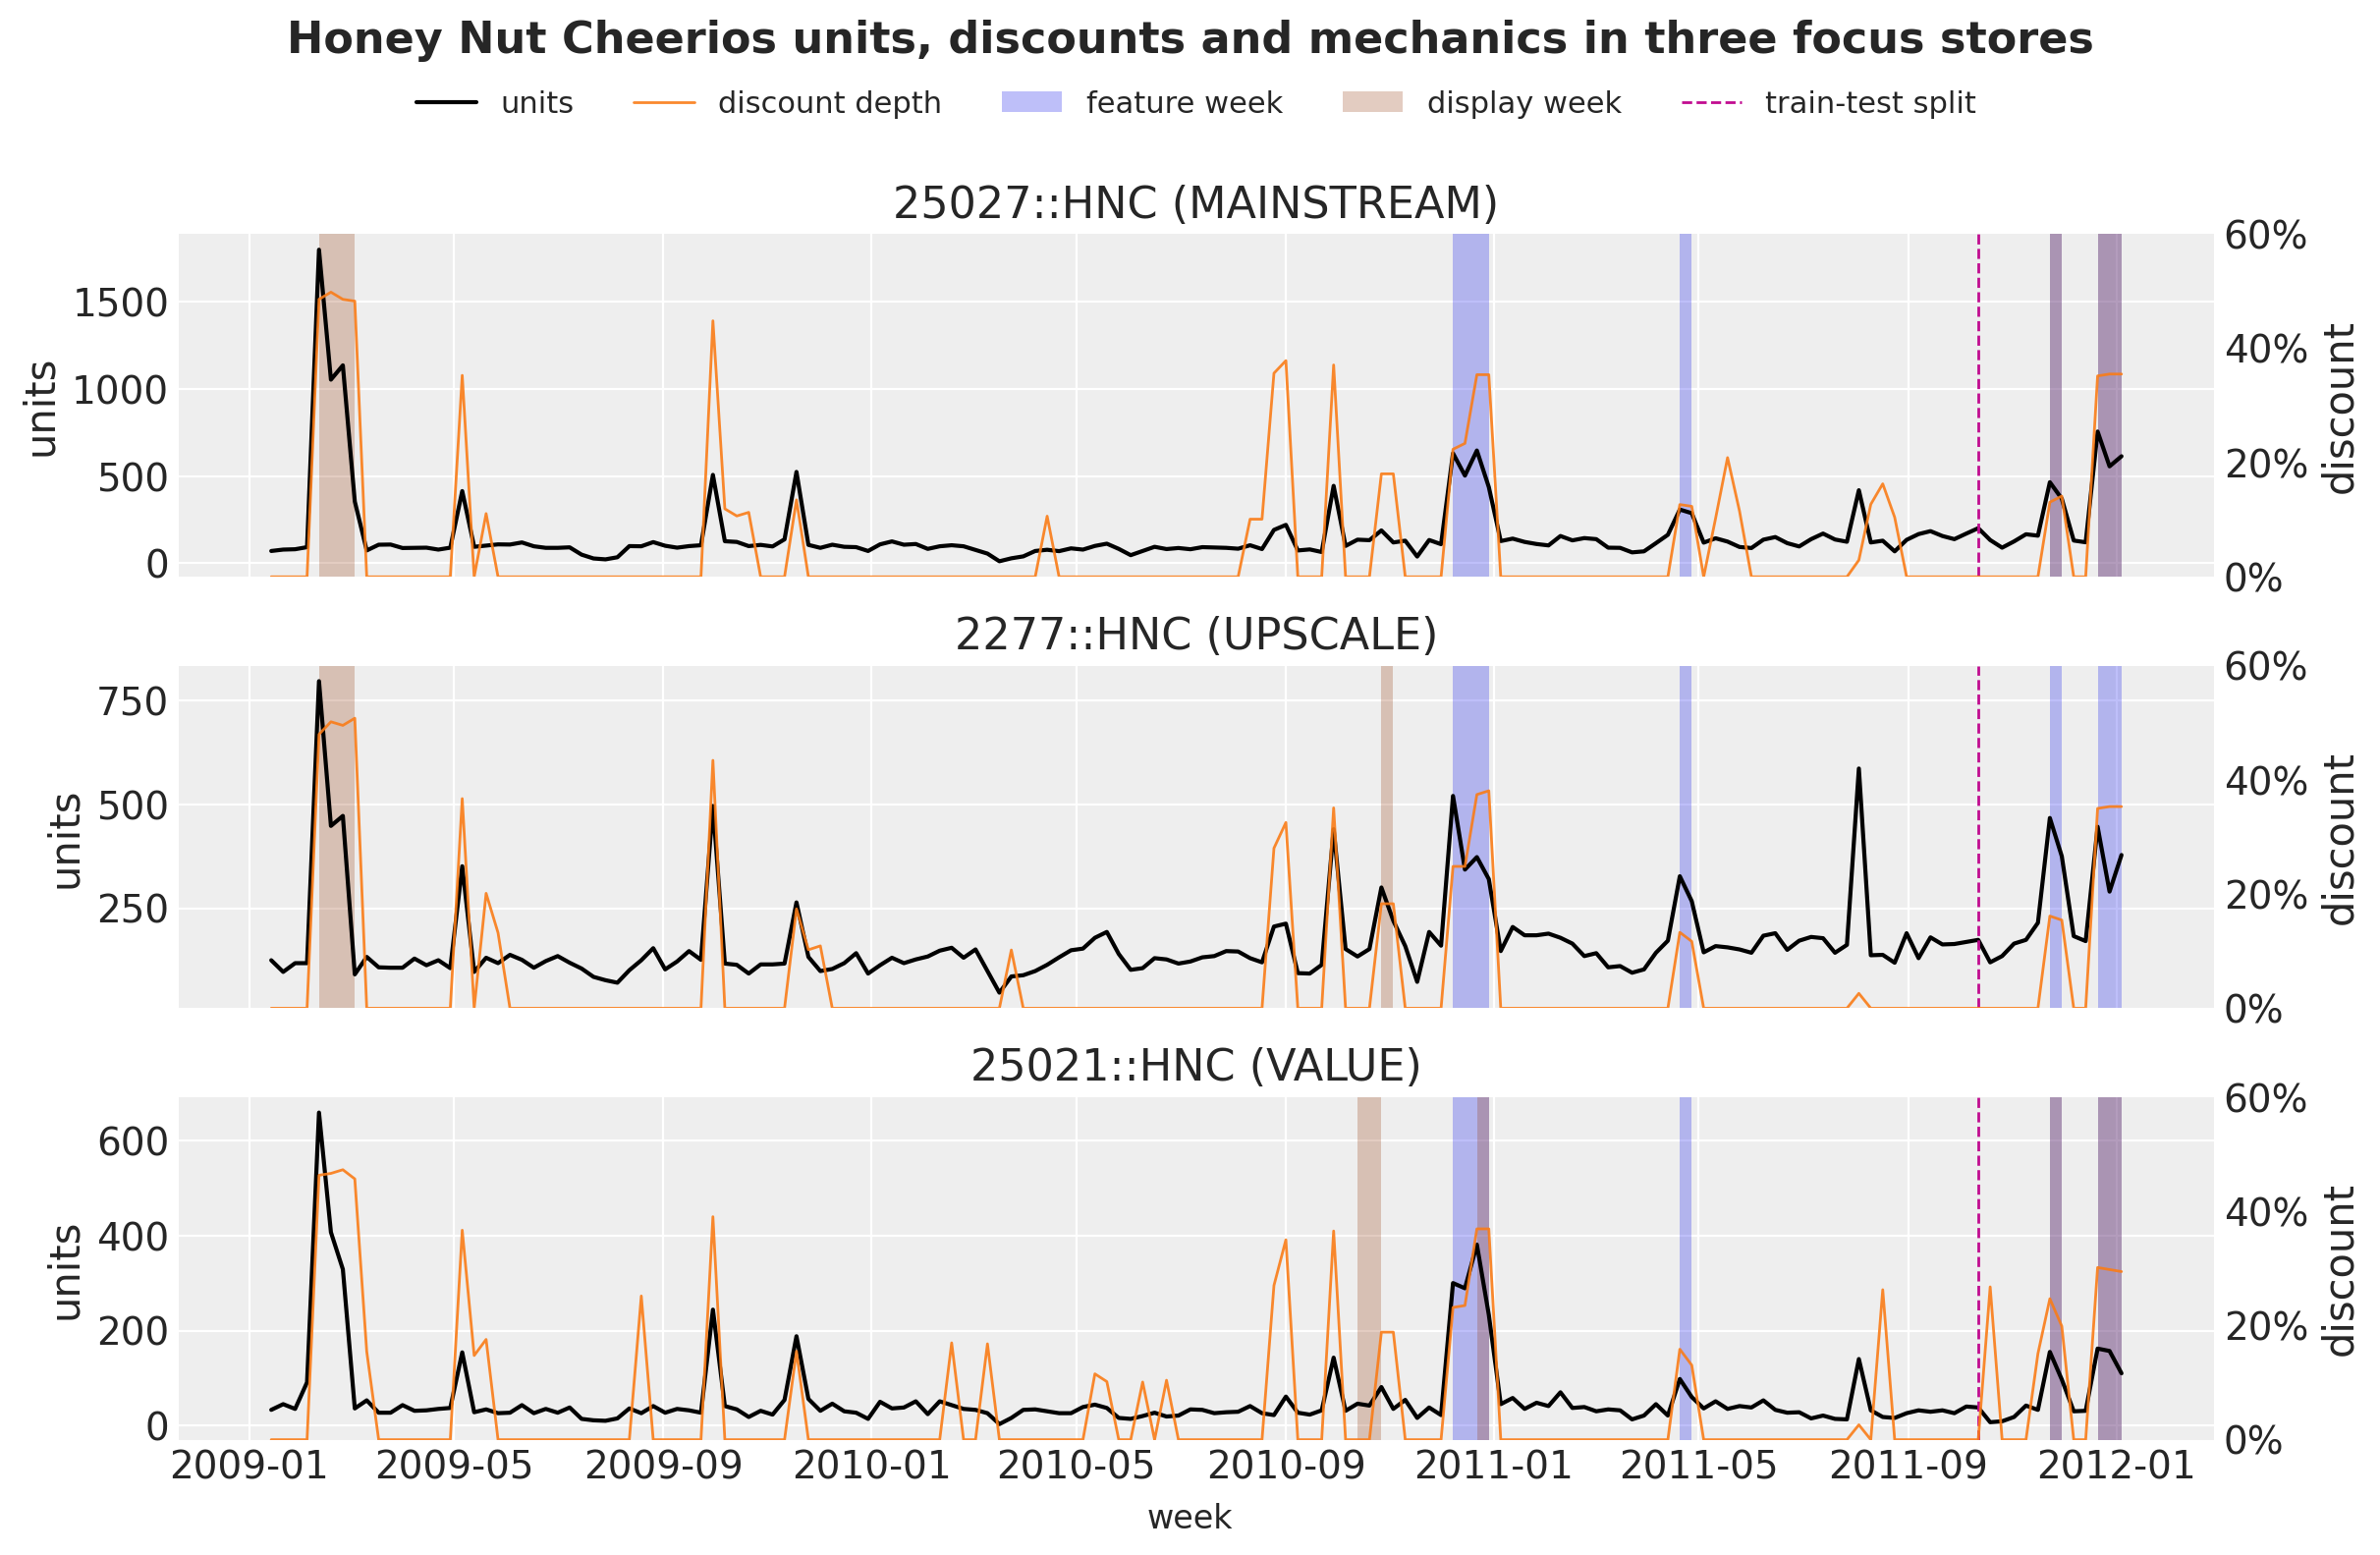

In [14]:
focus_stores = [
    int(selected.filter(pl.col("SEG_VALUE_NAME") == segment)["STORE_NUM"][0])
    for segment in ["MAINSTREAM", "UPSCALE", "VALUE"]
]
focus_labels = [f"{store}::{FOCAL}" for store in focus_stores]

fig, axes = plt.subplots(
    nrows=len(focus_labels),
    figsize=(12, 2.6 * len(focus_labels)),
    sharex=True,
    layout="constrained",
)
for ax, label, store in zip(axes, focus_labels, focus_stores, strict=True):
    (units_line,) = ax.plot(
        dates, panel_ds["units"].sel(series=label), color="black", linewidth=1.5, label="units"
    )
    split_line = ax.axvline(
        split_x, color="C3", linestyle="--", linewidth=1, label="train-test split"
    )
    feature_span = ax.fill_between(
        dates,
        0,
        1,
        where=(panel_ds["feature"].sel(series=label) > 0.5).to_numpy().tolist(),
        transform=ax.get_xaxis_transform(),
        color="C0",
        alpha=0.3,
        linewidth=0,
        step="mid",
        label="feature week",
    )
    display_span = ax.fill_between(
        dates,
        0,
        1,
        where=(panel_ds["display"].sel(series=label) > 0.5).to_numpy().tolist(),
        transform=ax.get_xaxis_transform(),
        color="C4",
        alpha=0.25,
        linewidth=0,
        step="mid",
        label="display week",
    )
    ax.set(title=f"{label} ({store_segment[store]})", ylabel="units")
    ax_twin = ax.twinx()
    (discount_line,) = ax_twin.plot(
        dates,
        panel_ds["discount"].sel(series=label).clip(0.0, 1.0),
        color="C1",
        alpha=0.9,
        linewidth=1,
        label="discount depth",
    )
    ax_twin.grid(False)
    ax_twin.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax_twin.set(ylabel="discount", ylim=(0, 0.6))
axes[0].legend(
    handles=[units_line, discount_line, feature_span, display_span, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.5),
    ncol=5,
    fontsize=11,
)
fig.supxlabel("week")
fig.suptitle(
    "Honey Nut Cheerios units, discounts and mechanics in three focus stores",
    fontsize=16,
    fontweight="bold",
);

## Identification: the estimand, the promotion calendar and the naive elasticity

The quantity we want is the expected weekly units of the focal product under a discount $d$ and a mechanics $m$, with the other covariates at their factual values. This is a promotional elasticity: the response to a temporary cut below the base price, not the response to a change in the base price itself, which the level of each series absorbs. The regular-price elasticity would need a different design (Bijmolt, van Heerde and Pieters (2005) document that promotional elasticities exceed regular-price ones), and this notebook cannot answer regular-price questions.

Prices were not randomized. The retailer and the manufacturers set the promotion calendar through trade deals, and the same deal sets the cut, the feature and the display together. The causal graph below draws the identifying assumption: conditional on the mechanics flags, the sibling flags, the competitor prices and the seasonal and level terms, the depth of the cut is as good as random with respect to the unobserved demand shocks. The right-hand cluster shows what would break it: a demand shock (a coupon drop, a competitor's promotion in another retailer) that moves both the deal calendar and the units. We cannot test the assumption with these data; the holdout below validates the forecasting engine under the realized calendar, not the counterfactual ones.

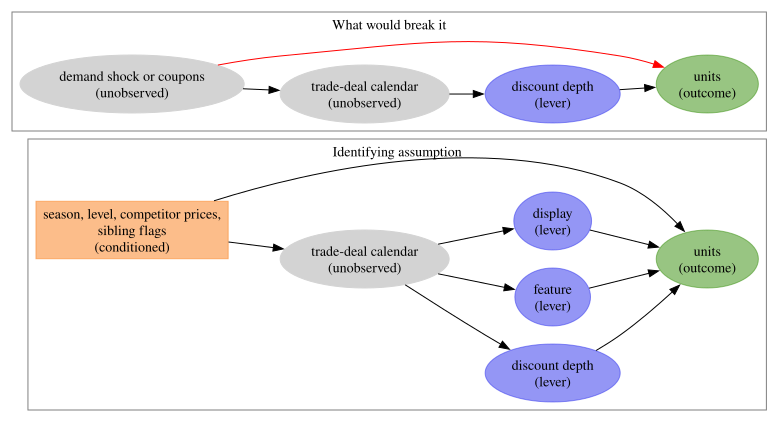

In [15]:
dag = gr.Digraph()
dag.attr(rankdir="LR")
with dag.subgraph(name="cluster_assumption") as cluster:
    cluster.attr(label="Identifying assumption", color="gray")
    cluster.node("U", label="trade-deal calendar\n(unobserved)", color="lightgray", style="filled")
    cluster.node("d", label="discount depth\n(lever)", color="#2a2eec80", style="filled")
    cluster.node("F", label="feature\n(lever)", color="#2a2eec80", style="filled")
    cluster.node("D", label="display\n(lever)", color="#2a2eec80", style="filled")
    cluster.node(
        "Z",
        label="season, level, competitor prices,\nsibling flags\n(conditioned)",
        shape="box",
        color="#fa7c1780",
        style="filled",
    )
    cluster.node("Y", label="units\n(outcome)", color="#328c0680", style="filled")
    for lever in ("d", "F", "D"):
        cluster.edge("U", lever)
        cluster.edge(lever, "Y")
    cluster.edge("Z", "Y")
    cluster.edge("Z", "U")
with dag.subgraph(name="cluster_violation") as cluster:
    cluster.attr(label="What would break it", color="gray")
    cluster.node(
        "V", label="demand shock or coupons\n(unobserved)", color="lightgray", style="filled"
    )
    cluster.node(
        "U2", label="trade-deal calendar\n(unobserved)", color="lightgray", style="filled"
    )
    cluster.node("d2", label="discount depth\n(lever)", color="#2a2eec80", style="filled")
    cluster.node("Y2", label="units\n(outcome)", color="#328c0680", style="filled")
    cluster.edge("V", "U2")
    cluster.edge("U2", "d2")
    cluster.edge("d2", "Y2")
    cluster.edge("V", "Y2", color="red")
dag

### The naive elasticity and what the flags absorb

Before the Bayesian model, three within-store least-squares regressions of log units on the log price ratio show the identification problem in numbers: alone, with the mechanics flags, the sibling flags and the other five prices, and with the extra depth slopes under feature and display. The regressions remove store fixed effects by demeaning and include annual seasonality and a trend. The pooled row stacks the six products. A fourth specification replaces the log-linear price term by depth bins, a check of the functional form the model assumes.

For the focal product the naive elasticity is $-2.60$ (standard error $0.06$); with the flags it is $-1.33$, and with the depth slopes $-1.08$. Pooled over the six products the gap is $-1.86$ against $-0.95$: the flags absorb about half of the naive price effect, which is the trade-deal calendar at work. The focal product's full regression gives a feature multiplier of $1.99$ and a display multiplier of $1.44$, a feature-depth slope of $+0.36$ (standard error $0.14$) and a display-depth slope of $+0.13$ (standard error $0.14$). The least-squares cross terms range from $-0.62$ to $+0.65$; the largest is the response of the private-label twin to the focal product's price, $+0.65$. The binned specification rises with depth, from $+0.08$ for cuts up to $10\%$ to $+0.67$ above $30\%$, while the log-linear line predicts $0.08$, $0.22$, $0.38$ and $0.63$ at the bin centers against binned estimates of $0.08$, $0.09$, $0.26$ and $0.67$: on its own, a log-linear term overstates the response to moderate cuts. The model keeps the log-linear form, and its depth slopes under mechanics let the response of a featured cut differ from that of a shelf-tag cut, which is where the moderate cuts sit.

In [16]:
time_index = np.repeat(np.arange(N_WEEKS), n_series)
long_df = pl.DataFrame(
    {
        "series": np.tile(np.asarray(series_ids), N_WEEKS),
        "product": np.tile(np.asarray([s.split("::")[1] for s in series_ids]), N_WEEKS),
        "time": time_index,
        "log_units": np.log(panel_ds["units"].to_numpy().ravel()),
        "x": x_np.ravel(),
        "lam": -x_np.ravel(),
        "feature": feature_np.ravel(),
        "display": display_np.ravel(),
        "sib_feature": sib_feature_np.ravel(),
        "sib_display": sib_display_np.ravel(),
        "discount": panel_ds["discount"].to_numpy().ravel(),
        **{f"price {product}": prices_np[k].ravel() for k, product in enumerate(product_order)},
    }
).with_columns(
    *annual_fourier("time"),
    feature_display=pl.col("feature") * pl.col("display"),
    feature_lam=pl.col("feature") * pl.col("lam"),
    display_lam=pl.col("display") * pl.col("lam"),
    trend=pl.col("time") / N_WEEKS,
)
train_long = long_df.filter(pl.col("time") < t_train)
mechanics_terms = ["feature", "display", "feature_display", "sib_feature", "sib_display"]
depth_terms = ["feature_lam", "display_lam"]


def own_elasticity_row(frame: pl.DataFrame, label: str) -> dict[str, float | str]:
    """Own price coefficient under the three specifications, for one product or the pooled panel."""
    naive = within_ols(frame, ["x", *seasonal_terms])
    flags = within_ols(frame, ["x", *mechanics_terms, *seasonal_terms])
    slopes = within_ols(frame, ["x", *mechanics_terms, *depth_terms, *seasonal_terms])
    return {
        "product": label,
        "naive": float(naive["coef"][0]),
        "naive_se": float(naive["se"][0]),
        "with_flags": float(flags["coef"][0]),
        "with_flags_se": float(flags["se"][0]),
        "with_depth_slopes": float(slopes["coef"][0]),
        "with_depth_slopes_se": float(slopes["se"][0]),
    }


own_elasticity_ols = pl.DataFrame(
    [own_elasticity_row(train_long.filter(pl.col("product") == p), p) for p in product_order]
    + [own_elasticity_row(train_long, "pooled")]
)
own_elasticity_ols

product,naive,naive_se,with_flags,with_flags_se,with_depth_slopes,with_depth_slopes_se
"""HNC""",-2.601798,0.05715,-1.326977,0.07021,-1.084921,0.099629
"""Cheerios 12oz""",-0.666798,0.051086,-0.3183,0.038673,-0.31104,0.039819
"""Cheerios 18oz""",-2.748362,0.046263,-1.961065,0.104096,-1.511146,0.160804
"""Mini Wheats""",-2.619433,0.077762,-1.558958,0.10673,-1.626816,0.128205
"""PL Honey Nut Oats""",-1.837123,0.160595,-1.446412,0.173565,-1.468914,0.181495
"""PL Frosted Wheat""",-1.129432,0.081269,-0.8505,0.08354,-0.886696,0.087231
"""pooled""",-1.86253,0.026677,-0.948401,0.028264,-0.674752,0.033019


In [17]:
hnc_long = train_long.filter(pl.col("product") == FOCAL)
cross_terms = [f"price {product}" for product in product_order if product != FOCAL]
hnc_full_ols = within_ols(
    hnc_long, ["x", *mechanics_terms, *depth_terms, *cross_terms, *seasonal_terms]
).with_columns(
    multiplier=pl.when(pl.col("term").is_in(mechanics_terms))
    .then(pl.col("coef").exp())
    .otherwise(None)
)
hnc_full_ols.filter(~pl.col("term").is_in(seasonal_terms))

term,coef,se,multiplier
"""x""",-0.957322,0.101149,null
"""feature""",0.689083,0.052251,1.991889
"""display""",0.362616,0.061912,1.437084
"""feature_display""",-0.054911,0.071154,0.946569
"""sib_feature""",-0.089341,0.018196,0.914534
"""sib_display""",-0.030933,0.017986,0.969541
"""feature_lam""",0.36053,0.144082,null
"""display_lam""",0.126645,0.143309,null
"""price Cheerios 12oz""",-0.232351,0.043367,null
"""price Cheerios 18oz""",-0.301489,0.052951,null


In [18]:
cross_rows = []
for product in product_order:
    others = [f"price {other}" for other in product_order if other != product]
    fit = within_ols(
        train_long.filter(pl.col("product") == product),
        ["x", *mechanics_terms, *others, *seasonal_terms],
    )
    coefs = dict(zip(fit["term"].to_list(), fit["coef"].to_list(), strict=True))
    row: dict[str, float | str] = {"units of": product}
    for other in product_order:
        row[f"price of {other}"] = coefs["x"] if other == product else coefs[f"price {other}"]
    cross_rows.append(row)
cross_ols = pl.DataFrame(cross_rows)
cross_values = cross_ols.drop("units of").to_numpy()
off_diagonal = cross_values[~np.eye(n_products, dtype=bool)]
print(f"OLS cross terms: min {off_diagonal.min():.2f} | max {off_diagonal.max():.2f}")
cross_ols

OLS cross terms: min -0.62 | max 0.65


units of,price of HNC,price of Cheerios 12oz,price of Cheerios 18oz,price of Mini Wheats,price of PL Honey Nut Oats,price of PL Frosted Wheat
"""HNC""",-1.145766,-0.224495,-0.316926,-0.130353,0.162423,0.177489
"""Cheerios 12oz""",0.07092,-0.34379,0.277201,-0.057408,-0.62447,0.349092
"""Cheerios 18oz""",-0.047858,0.198809,-1.988508,0.184071,0.119586,0.179472
"""Mini Wheats""",0.024222,-0.010586,0.010404,-1.557781,0.385047,0.145947
"""PL Honey Nut Oats""",0.654352,0.010516,0.069029,-0.030701,-1.495217,0.500309
"""PL Frosted Wheat""",0.011771,0.020995,0.127626,0.499231,0.255877,-0.815959


In [19]:
def depth_bins(labels: list[str], edges: list[float]) -> list[pl.Expr]:
    """Build one 0/1 column per discount bin (lo, hi], in the order of ``labels``."""
    return [
        ((pl.col("discount") > lo) & (pl.col("discount") <= hi)).cast(pl.Float64).alias(label)
        for label, lo, hi in zip(labels, edges[:-1], edges[1:], strict=True)
    ]


bin_edges = [0.02, 0.10, 0.20, 0.30, 1.0]
bin_labels = ["cut (2%, 10%]", "cut (10%, 20%]", "cut (20%, 30%]", "cut > 30%"]
binned = hnc_long.with_columns(depth_bins(bin_labels, bin_edges))
binned_ols = within_ols(binned, [*bin_labels, *mechanics_terms, *seasonal_terms]).filter(
    pl.col("term").is_in(bin_labels)
)
hnc_slope = float(own_elasticity_ols.filter(pl.col("product") == FOCAL)["with_flags"][0])
bin_mids = np.array([0.06, 0.15, 0.25, 0.38])
binned_ols = binned_ols.with_columns(
    log_linear_at_bin_center=pl.Series(hnc_slope * np.log1p(-bin_mids)),
)
binned_ols

term,coef,se,log_linear_at_bin_center
"""cut (2%, 10%]""",0.076028,0.076769,0.082107
"""cut (10%, 20%]""",0.093826,0.027315,0.215659
"""cut (20%, 30%]""",0.263718,0.048844,0.381747
"""cut > 30%""",0.668813,0.04247,0.634342


### The weeks that identify the elasticity

The own elasticity of a product is identified by the weeks in which its price moved without a feature or a display, the `TPR_ONLY` weeks, plus the variation of the cut inside feature and display weeks. The first table counts them per product and per series; a product with a few dozen identifying store-weeks leans on the prior and on the partial pooling across stores. The second table gives the support of the focal product's discount depth under each mechanics over all 77 stores, which decides the grid of counterfactual policies: the shaded cells in the later figures are the depths with fewer than 20 observed store-weeks within $\pm 2.5$ points. The third block shows how the six log price ratios move together within a store-week, and how often a sibling is featured when the focal product is.

The focal product has 212 shelf-tag-only store-weeks in the training panel, between 6 and 22 per store; Cheerios 18 oz has 23, at most 4 per store, so its own elasticity leans on the depth variation inside its feature and display weeks and on the prior. Over all 77 stores the focal product's cut depth has a median of $14\%$ under a shelf tag, $20\%$ under a feature and $27\%$ under feature with display; $17\%$ of the display weeks and $18\%$ of the feature weeks carry no cut. The thin cells are a display at $10\%$, $15\%$, $35\%$ and $40\%$, a feature at $5\%$, and a shelf-tag cut at $5\%$ or $40\%$. The within-store correlations of the log price ratios stay below $0.30$, and a sibling is featured in $27\%$ of the store-weeks in which the focal product is featured, against $37\%$ otherwise.

In [20]:
def tpr_weeks_spread(df: pl.DataFrame) -> pl.DataFrame:
    """Summarize the shelf-tag-only weeks per series as a min, median and max per product."""
    return (
        df.group_by("series", "product")
        .agg(tpr_weeks=pl.col("TPR_ONLY").sum())
        .group_by("product")
        .agg(
            tpr_per_series_min=pl.col("tpr_weeks").min(),
            tpr_per_series_median=pl.col("tpr_weeks").median(),
            tpr_per_series_max=pl.col("tpr_weeks").max(),
        )
    )


train_panel_df = panel_df.filter(pl.col("WEEK_END_DATE").is_in(all_weeks[:t_train].to_list()))
identification = (
    train_panel_df.group_by("product", maintain_order=True)
    .agg(
        tpr_only=pl.col("TPR_ONLY").sum(),
        feature=pl.col("FEATURE").sum(),
        display=pl.col("DISPLAY").sum(),
    )
    .join(train_panel_df.pipe(tpr_weeks_spread), on="product")
    .pipe(sort_by_order, "product", product_order)
)
identification

product,tpr_only,feature,display,tpr_per_series_min,tpr_per_series_median,tpr_per_series_max
"""HNC""",212,230,199,6,10.5,22
"""Cheerios 12oz""",894,263,272,31,53.0,62
"""Cheerios 18oz""",23,224,227,0,1.0,4
"""Mini Wheats""",168,287,141,4,9.0,13
"""PL Honey Nut Oats""",394,94,104,5,18.5,39
"""PL Frosted Wheat""",604,137,103,22,35.5,44


In [21]:
DEPTH_GRID = np.round(np.arange(0.0, 0.401, 0.05), 2)
MECHANICS: dict[str, tuple[float, float]] = {
    "TPR-only": (0.0, 0.0),
    "display": (0.0, 1.0),
    "feature": (1.0, 0.0),
    "feature + display": (1.0, 1.0),
}
hnc_all_stores = cereal_df.filter(pl.col("product") == FOCAL).with_columns(depth=cut_depth())
support_rows = []
support_counts: dict[str, np.ndarray] = {}
for mechanics_name in MECHANICS:
    subset = hnc_all_stores.filter(pl.col("mechanics") == mechanics_name)
    depth = subset["depth"].to_numpy()
    counts = np.array([int(np.sum(np.abs(depth - d) <= 0.025)) for d in DEPTH_GRID])
    support_counts[mechanics_name] = counts
    support_rows.append(
        {
            "mechanics": mechanics_name,
            "store_weeks": depth.size,
            "share_without_cut": float(np.mean(depth <= 0.02)),
            "p05": float(np.quantile(depth, 0.05)),
            "p50": float(np.quantile(depth, 0.50)),
            "p95": float(np.quantile(depth, 0.95)),
            **{f"n@{d:.2f}": int(c) for d, c in zip(DEPTH_GRID, counts, strict=True)},
        }
    )
support_table = pl.DataFrame(support_rows)
support_table

mechanics,store_weeks,share_without_cut,p05,p50,p95,n@0.00,n@0.05,n@0.10,n@0.15,n@0.20,n@0.25,n@0.30,n@0.35,n@0.40
"""TPR-only""",1088,0.0,0.102894,0.144591,0.336067,0,0,336,398,169,67,58,36,6
"""display""",334,0.170659,0.0,0.28031,0.492163,57,24,9,9,30,34,20,14,3
"""feature""",456,0.177632,0.0,0.198613,0.451561,83,18,39,67,34,37,22,88,28
"""feature + display""",863,0.077636,0.0,0.266423,0.482759,68,37,65,95,81,100,54,156,38


In [22]:
x_store_week = x_np[:t_train].reshape(t_train, n_stores, n_products).reshape(-1, n_products)
price_correlation = pl.DataFrame(
    {
        "x of": product_order,
        **{p: np.corrcoef(x_store_week.T)[:, k] for k, p in enumerate(product_order)},
    }
)
feature_store_week = feature_np[:t_train].reshape(t_train, n_stores, n_products)
hnc_featured = feature_store_week[:, :, FOCAL_INDEX] == 1
sibling_featured = np.delete(feature_store_week, FOCAL_INDEX, axis=2).max(axis=2) == 1
print(f"P(sibling featured | HNC featured): {sibling_featured[hnc_featured].mean():.2f}")
print(f"P(sibling featured | HNC not featured): {sibling_featured[~hnc_featured].mean():.2f}")
price_correlation

P(sibling featured | HNC featured): 0.27
P(sibling featured | HNC not featured): 0.37


x of,HNC,Cheerios 12oz,Cheerios 18oz,Mini Wheats,PL Honey Nut Oats,PL Frosted Wheat
"""HNC""",1.0,0.297353,0.123075,-0.078147,0.103915,-0.050287
"""Cheerios 12oz""",0.297353,1.0,0.278749,-0.013253,0.093249,-0.189566
"""Cheerios 18oz""",0.123075,0.278749,1.0,0.001388,-0.024091,-0.102736
"""Mini Wheats""",-0.078147,-0.013253,0.001388,1.0,-0.016099,-0.051092
"""PL Honey Nut Oats""",0.103915,0.093249,-0.024091,-0.016099,1.0,-0.103449
"""PL Frosted Wheat""",-0.050287,-0.189566,-0.102736,-0.051092,-0.103449,1.0


## Model specification

For series $i$ let $\text{prod}(i)$ be its product and $s(i)$ its store; $t$ indexes weeks and $u \le t$ the past weeks; $y_{t,i}$ is the unit count and $\mu_{t,i}$ its conditional mean. The observed inputs at week $t$ are the log price ratio $x_{t,i} = \log(\text{PRICE}_{t,i} / \text{BASE\_PRICE}_{t,i}) \le 0$, the log depth $\lambda_{t,i} = -x_{t,i}$, the flags $F_{t,i}$ (feature) and $D_{t,i}$ (display), the sibling flags $F^{\text{sib}}_{t,i}$ and $D^{\text{sib}}_{t,i}$, and the log price ratios $x_{k,t,s}$ of every product $k$ at store $s$. The latent quantities are the initial level $\ell_{0,i}$ and the weekly level innovations $\delta_{u,i}$ (a random walk on the log scale); the annual Fourier basis $f(t)$ with two harmonics and product coefficients $\beta_p$; the own promotional elasticity $\varepsilon_i$ of each series, partially pooled around a product mean; the cross elasticities $\gamma_{k,p}$, the response of product $p$'s units to product $k$'s price, zero on the diagonal; the mechanics effects $b^{\text{feat}}_p$, $b^{\text{disp}}_p$ and their interaction $b^{\text{fd}}_p$; the depth slopes under mechanics $b^{\text{feat},\lambda}_p$ and $b^{\text{disp},\lambda}_p$; the sibling-mechanics effects $b^{\text{sib,feat}}_p$ and $b^{\text{sib,disp}}_p$; and the negative binomial concentration $\phi_p$. With $p = \text{prod}(i)$ and $s = s(i)$:

$$
\log \mu_{t,i} = \ell_{0,i} + \sum_{u \le t} \delta_{u,i} + f(t)^\top \beta_p + \varepsilon_i\, x_{t,i} + \sum_{k \ne p} \gamma_{k,p}\, x_{k,t,s} + b^{\text{feat}}_p F_{t,i} + b^{\text{disp}}_p D_{t,i} + b^{\text{fd}}_p F_{t,i} D_{t,i} + b^{\text{feat},\lambda}_p F_{t,i} \lambda_{t,i} + b^{\text{disp},\lambda}_p D_{t,i} \lambda_{t,i} + b^{\text{sib,feat}}_p F^{\text{sib}}_{t,i} + b^{\text{sib,disp}}_p D^{\text{sib}}_{t,i}
$$

$$
y_{t,i} \sim \text{NegativeBinomial}(\mu_{t,i}, \phi_p),
$$

in the mean and concentration parameterization. Because $\lambda = -\log(1 - d)$ for a fractional discount $d$, the depth response under a mechanics $m = (F_m, D_m)$ is $(1 - d)^{\varepsilon_m}$ with the mechanics-specific elasticity $\varepsilon_m = \varepsilon - b^{\text{feat},\lambda} F_m - b^{\text{disp},\lambda} D_m$ (a positive slope makes the response steeper), and the mechanics uplift at zero depth is $e^{b_m}$ with $b_m = b^{\text{feat}} F_m + b^{\text{disp}} D_m + b^{\text{fd}} F_m D_m$. Every decision threshold below uses $\varepsilon_m$, never the bare $\varepsilon$. The sibling-mechanics effects are averages over "any sibling featured or displayed", so under a policy in which only the focal product is featured the mechanics part of the cannibalization is attenuated toward the average sibling. Remark: with a Poisson likelihood the same code runs with `dist.Poisson`; with continuous sales the link would be a Normal on the log scale.

We write each additive piece of $\log \mu$ as a component that samples its own sites and returns its contribution, the pattern of the NumPyro [Hilbert space Gaussian process example](https://num.pyro.ai/en/stable/examples/hsgp.html): the model creates the plates once, samples the centering values, sums the pieces and calls `predict`. The level innovations, the store-level elasticities and the cross terms use NumPyro's [`LocScaleReparam`](https://num.pyro.ai/en/stable/reparam.html) with a sampled centering value in $[0, 1]$, the idiom of the [hierarchical forecasting example](hierarchical_forecasting_1.html): $0$ is the non-centered parameterization, $1$ the centered one. A reparameterization does not change the posterior, so under NUTS this value has no likelihood and cannot be learned: its posterior would be its prior and its chains would wander over the unit interval. Under variational inference the ELBO does depend on it, so the inference section learns it with a short SVI pass and hands it to NUTS as a constant, the recipe of [Gorinova, Moore and Hoffman (2020)](https://arxiv.org/abs/1906.03028). Only the 30 off-diagonal cross terms are sampled and scattered into the $6 \times 6$ matrix. The Fourier basis is computed once outside the model and sliced inside it, because the cached helper must not run under a trace.

In [23]:
@dataclass(frozen=True)
class CerealPriors:
    """Prior hyperparameters of the cereal demand model (all on the log scale)."""

    eps_loc: float
    eps_sd: float
    eps_store_sd: float
    drift_mu: float
    drift_sigma: float
    conc_mu: float
    conc_sigma: float
    mech_loc: float
    mech_sd: float
    aux_sd: float
    cross_sd: float
    seasonal_sd: float
    level_loc: float
    level_sd: float


CENTERING_SITES = ["centered_drift", "centered_eps", "centered_gamma"]


def local_level(
    h: Horizon,
    series_plate: numpyro.plate,
    centered_drift: Float[Array, ""],
    priors: CerealPriors,
) -> Float[Array, " duration n_series"]:
    """Random-walk level per series: initial level plus the cumulative sum of the innovations."""
    with series_plate:
        level0 = cast(
            "Array", numpyro.sample("level0", dist.Normal(priors.level_loc, priors.level_sd))
        )
        drift_scale = cast(
            "Array",
            numpyro.sample("drift_scale", dist.LogNormal(priors.drift_mu, priors.drift_sigma)),
        )
        # innovations opens its own time plate at dim=-2 and registers the horizon
        # innovations as a separate site, so the forecast continues the walk. The
        # centering value is a sampled site that SVI learns and NUTS receives as a constant.
        drift = innovations(
            h,
            "drift",
            lambda: dist.Normal(0.0, drift_scale),
            reparam=LocScaleReparam(centered=centered_drift),
        )
    return level0 + jnp.cumsum(drift, axis=-2)


def annual_seasonality(
    fourier: Float[Array, " duration n_fourier"],
    product_plate: numpyro.plate,
    fourier_plate: numpyro.plate,
    series_to_product: Int[Array, " n_series"],
    priors: CerealPriors,
) -> Float[Array, " duration n_series"]:
    """Annual Fourier seasonality with one coefficient vector per product."""
    with fourier_plate, product_plate:
        beta_s = cast("Array", numpyro.sample("beta_s", dist.Normal(0.0, priors.seasonal_sd)))
    return (fourier @ beta_s)[:, series_to_product]


def own_price_effect(
    x: Float[Array, " duration n_series"],
    product_plate: numpyro.plate,
    series_plate: numpyro.plate,
    series_to_product: Int[Array, " n_series"],
    centered_eps: Float[Array, ""],
    priors: CerealPriors,
) -> Float[Array, " duration n_series"]:
    """Own promotional elasticity per series, partially pooled around its product mean."""
    with product_plate:
        eps_prod = cast(
            "Array", numpyro.sample("eps_prod", dist.Normal(priors.eps_loc, priors.eps_sd))
        )
    eps_scale = cast("Array", numpyro.sample("eps_scale", dist.HalfNormal(priors.eps_store_sd)))
    with series_plate, handlers.reparam(config={"eps": LocScaleReparam(centered=centered_eps)}):
        eps = cast(
            "Array", numpyro.sample("eps", dist.Normal(eps_prod[series_to_product], eps_scale))
        )
    return eps * x


def cross_price_effect(
    prices: Float[Array, " n_products duration n_series"],
    pair_plate: numpyro.plate,
    series_to_product: Int[Array, " n_series"],
    pair_rows: Int[Array, " n_pairs"],
    pair_cols: Int[Array, " n_pairs"],
    centered_gamma: Float[Array, ""],
    priors: CerealPriors,
    n_products: int,
) -> Float[Array, " duration n_series"]:
    """Cross-price contribution from the 30 off-diagonal elasticities, shrunk toward zero."""
    cross_scale = cast("Array", numpyro.sample("cross_scale", dist.HalfNormal(priors.cross_sd)))
    with (
        pair_plate,
        handlers.reparam(config={"gamma_offdiag": LocScaleReparam(centered=centered_gamma)}),
    ):
        gamma_offdiag = cast(
            "Array", numpyro.sample("gamma_offdiag", dist.Normal(0.0, cross_scale))
        )
    gamma = cast(
        "Array",
        numpyro.deterministic(
            "gamma",
            jnp.zeros((n_products, n_products)).at[pair_rows, pair_cols].set(gamma_offdiag),
        ),
    )
    # cross[t, n] = sum_k gamma[k, p(n)] * prices[k, t, n]: for series n (product p(n) sold at
    # store s(n)), take the log price ratio of every product k at the same store and weight it
    # by the cross elasticity of p(n) with respect to k; the own cell k == p(n) is zero in
    # gamma and is handled by own_price_effect.
    return jnp.einsum("ktn,kn->tn", prices, gamma[:, series_to_product])


def mechanics_effect(
    feature: Float[Array, " duration n_series"],
    display: Float[Array, " duration n_series"],
    lam: Float[Array, " duration n_series"],
    sib_feature: Float[Array, " duration n_series"],
    sib_display: Float[Array, " duration n_series"],
    product_plate: numpyro.plate,
    series_to_product: Int[Array, " n_series"],
    priors: CerealPriors,
) -> Float[Array, " duration n_series"]:
    """Feature and display uplifts, their interaction, the depth slopes and the sibling effects."""
    with product_plate:
        b_feat = cast(
            "Array", numpyro.sample("b_feat", dist.Normal(priors.mech_loc, priors.mech_sd))
        )
        b_disp = cast(
            "Array", numpyro.sample("b_disp", dist.Normal(priors.mech_loc, priors.mech_sd))
        )
        b_fd = cast("Array", numpyro.sample("b_fd", dist.Normal(0.0, priors.aux_sd)))
        b_feat_depth = cast(
            "Array", numpyro.sample("b_feat_depth", dist.Normal(0.0, priors.aux_sd))
        )
        b_disp_depth = cast(
            "Array", numpyro.sample("b_disp_depth", dist.Normal(0.0, priors.aux_sd))
        )
        b_sib_feat = cast("Array", numpyro.sample("b_sib_feat", dist.Normal(0.0, priors.aux_sd)))
        b_sib_disp = cast("Array", numpyro.sample("b_sib_disp", dist.Normal(0.0, priors.aux_sd)))
    p = series_to_product
    return (
        b_feat[p] * feature
        + b_disp[p] * display
        + b_fd[p] * feature * display
        + b_feat_depth[p] * feature * lam
        + b_disp_depth[p] * display * lam
        + b_sib_feat[p] * sib_feature
        + b_sib_disp[p] * sib_display
    )


def dispersion(
    product_plate: numpyro.plate, series_to_product: Int[Array, " n_series"], priors: CerealPriors
) -> Float[Array, " n_series"]:
    """Negative binomial concentration per product, gathered to the series axis."""
    with product_plate:
        conc = cast(
            "Array", numpyro.sample("conc", dist.LogNormal(priors.conc_mu, priors.conc_sigma))
        )
    return conc[series_to_product]


def make_cereal_model(
    series_to_product: Int[Array, " n_series"],
    fourier_full: Float[Array, " duration_full n_fourier"],
    priors: CerealPriors,
    n_products: int,
    n_series: int,
) -> ForecastModel:
    """Build the cereal demand model as the plain ``(covariates, data=None)`` callable.

    Parameters
    ----------
    series_to_product
        Product index of every series, shape ``(n_series,)``.
    fourier_full
        Annual Fourier basis over the full duration, computed outside any trace.
    priors
        Prior hyperparameters.
    n_products
        Number of products (the cross matrix is ``n_products`` square).
    n_series
        Number of store-product series (the trailing observation axis).

    Returns
    -------
    ForecastModel
        The model function, callable as ``model(covariates)`` for prior sampling and
        ``model(covariates, data)`` for training and forecasting.
    """
    rows_np, cols_np = np.where(~np.eye(n_products, dtype=bool))
    pair_rows = jnp.asarray(rows_np, dtype=jnp.int32)
    pair_cols = jnp.asarray(cols_np, dtype=jnp.int32)
    n_pairs = int(rows_np.size)
    n_fourier = int(fourier_full.shape[-1])

    def cereal_model(
        covariates: Float[Array, " inputs duration n_series"],
        data: Int[Array, " t_obs n_series"] | None = None,
    ) -> None:
        """Sample the joint model (the drivers call this for training and forecasting)."""
        h = Horizon.from_data(covariates, data)
        duration = covariates.shape[-2]
        x = covariates[0]
        feature = covariates[1]
        display = covariates[2]
        sib_feature = covariates[3]
        sib_display = covariates[4]
        prices = covariates[PRICE_BLOCK:]
        assert isinstance(prices, Float[Array, " n_products duration n_series"])  # ty: ignore[invalid-argument-type]
        lam = -x

        product_plate = numpyro.plate("product", n_products, dim=-1)
        fourier_plate = numpyro.plate("fourier", n_fourier, dim=-2)
        pair_plate = numpyro.plate("pair", n_pairs, dim=-1)
        series_plate = numpyro.plate("series", n_series, dim=-1)
        # One centering value per reparameterized site, in [0, 1]: 0 is non-centered, 1 centered.
        centered_drift = cast("Array", numpyro.sample("centered_drift", dist.Uniform(0.0, 1.0)))
        centered_eps = cast("Array", numpyro.sample("centered_eps", dist.Uniform(0.0, 1.0)))
        centered_gamma = cast("Array", numpyro.sample("centered_gamma", dist.Uniform(0.0, 1.0)))

        eta = (
            local_level(h, series_plate, centered_drift, priors)
            + annual_seasonality(
                fourier_full[:duration], product_plate, fourier_plate, series_to_product, priors
            )
            + own_price_effect(
                x, product_plate, series_plate, series_to_product, centered_eps, priors
            )
            + cross_price_effect(
                prices,
                pair_plate,
                series_to_product,
                pair_rows,
                pair_cols,
                centered_gamma,
                priors,
                n_products,
            )
            + mechanics_effect(
                feature,
                display,
                lam,
                sib_feature,
                sib_display,
                product_plate,
                series_to_product,
                priors,
            )
        )
        conc_series = dispersion(product_plate, series_to_product, priors)
        if h.future > 0:
            # The conditional mean over the horizon, for the decision layer; registered
            # only in forecast mode so the training posterior carries no extra array.
            numpyro.deterministic("mu_future", jnp.exp(eta)[h.t_obs :])
        predict(h, lambda e: dist.NegativeBinomial2(jnp.exp(e), conc_series), eta)

    return cereal_model


fourier_full = jnp.asarray(fourier_features(N_WEEKS, 52.18, 2))
pair_rows_np, pair_cols_np = np.where(~np.eye(n_products, dtype=bool))
pair_labels = [
    f"{product_order[k]} -> {product_order[p]}"
    for k, p in zip(pair_rows_np, pair_cols_np, strict=True)
]
fourier_names = ["sin1", "sin2", "cos1", "cos2"]

## Priors and prior predictive checks

Every prior has a reason, and the table prints the $94\%$ interval of each one with the quantity it implies, so the numbers quoted here come from the cells. The product elasticity prior $\text{Normal}(-1.5, 1)$ is centered where the meta-analysis of [Bijmolt, van Heerde and Pieters (2005)](https://doi.org/10.1509/jmkr.42.2.141.62296) puts price elasticities (an average of about $-2.6$ across studies, with promotional elasticities above regular-price ones in magnitude), and it leaves the positive tail open so the data can reject the sign. The store deviations around the product mean have a $\text{HalfNormal}(0.5)$ scale, deviations of up to about one unit. The weekly innovation scale of the level comes from `preliz.maxent`: we ask for a log-normal with $94\%$ of its mass between weekly innovations of $1\%$ and $8\%$, because a wider prior lets the level absorb one-week promotion spikes (a check against the least-squares mechanics effects follows the fit). The concentration prior $\text{LogNormal}(2, 1)$ implies, at 80 units a week, a coefficient of variation near the within-store spread of the focal product's weeks. The feature and display effects have a $\text{Normal}(0.5, 0.5)$ prior, a median multiplier of $1.65$ against the least-squares multipliers printed above, with negative values allowed. The interaction, the depth slopes and the sibling effects are centered at zero. The cross terms share a $\text{HalfNormal}(0.5)$ scale that shrinks the 30 cells toward zero. The seasonal coefficients have a $\text{Normal}(0, 0.2)$ prior, the initial level a $\text{Normal}(3, 2)$ prior on the log scale, and the three centering values a $\text{Uniform}(0, 1)$ prior, which the SVI pass of the inference section turns into a choice of parameterization. `preliz.maxent` returns $\text{LogNormal}(-3.3, 0.488)$, a median weekly innovation of $3.7\%$. The prior predictive bands cover the observed units of the focus series, and the prior implied multiplier of the focal product at a $35\%$ cut under feature with display has a median of $4.5$ with a $94\%$ HDI from $0.3$ to $27.5$: wide, as a prior should be, and centered on a plausible value.

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    drift_scale_prior = pz.maxent(pz.LogNormal(), lower=0.01, upper=0.08, mass=0.94, plot=False)
print(f"weekly drift scale prior: {drift_scale_prior} | median {drift_scale_prior.median():.3f}")

priors = CerealPriors(
    eps_loc=-1.5,
    eps_sd=1.0,
    eps_store_sd=0.5,
    drift_mu=float(drift_scale_prior.mu),
    drift_sigma=float(drift_scale_prior.sigma),
    conc_mu=2.0,
    conc_sigma=1.0,
    mech_loc=0.5,
    mech_sd=0.5,
    aux_sd=0.5,
    cross_sd=0.5,
    seasonal_sd=0.2,
    level_loc=3.0,
    level_sd=2.0,
)
prior_distributions = {
    "eps_prod": pz.Normal(priors.eps_loc, priors.eps_sd),
    "eps_scale": pz.HalfNormal(priors.eps_store_sd),
    "drift_scale": pz.LogNormal(priors.drift_mu, priors.drift_sigma),
    "conc": pz.LogNormal(priors.conc_mu, priors.conc_sigma),
    "b_feat, b_disp": pz.Normal(priors.mech_loc, priors.mech_sd),
    "b_fd, depth slopes, sibling effects": pz.Normal(0.0, priors.aux_sd),
    "cross_scale": pz.HalfNormal(priors.cross_sd),
    "beta_s": pz.Normal(0.0, priors.seasonal_sd),
    "level0": pz.Normal(priors.level_loc, priors.level_sd),
}
prior_rows = []
for site, distribution in prior_distributions.items():
    lower, upper = distribution.eti(mass=0.94)
    median = float(distribution.median())
    if site == "drift_scale":
        implied = f"level drift over 13 weeks about {np.sqrt(HORIZON) * median:.0%} (median)"
    elif site == "conc":
        implied = f"CV at 80 units about {np.sqrt(1 / 80 + 1 / median):.2f} (median)"
    elif site == "b_feat, b_disp":
        implied = (
            f"multiplier {np.exp(lower):.2f} to {np.exp(upper):.2f}, median {np.exp(median):.2f}"
        )
    elif site == "level0":
        implied = f"{np.exp(lower):.1f} to {np.exp(upper):.0f} units, median {np.exp(median):.0f}"
    else:
        implied = ""
    prior_rows.append(
        {
            "site": site,
            "prior": str(distribution),
            "median": median,
            "eti94_lower": float(lower),
            "eti94_upper": float(upper),
            "implied": implied,
        }
    )
prior_table = pl.DataFrame(prior_rows)
prior_table

weekly drift scale prior: LogNormal(mu=-3.3, sigma=0.488) | median 0.037


site,prior,median,eti94_lower,eti94_upper,implied
"""eps_prod""","""Normal(mu=-1.5, sigma=1)""",-1.5,-3.38,0.38,""""""
"""eps_scale""","""HalfNormal(sigma=0.5)""",0.337245,0.02,1.09,""""""
"""drift_scale""","""LogNormal(mu=-3.3, sigma=0.488)""",0.036894,0.01,0.09,"""level drift over 13 weeks about 13% (median)"""
"""conc""","""LogNormal(mu=2, sigma=1)""",7.389056,1.13,48.46,"""CV at 80 units about 0.38 (median)"""
"""b_feat, b_disp""","""Normal(mu=0.5, sigma=0.5)""",0.5,-0.44,1.44,"""multiplier 0.64 to 4.22, median 1.65"""
"""b_fd, depth slopes, sibling effects""","""Normal(mu=0, sigma=0.5)""",0.0,-0.94,0.94,""""""
"""cross_scale""","""HalfNormal(sigma=0.5)""",0.337245,0.02,1.09,""""""
"""beta_s""","""Normal(mu=0, sigma=0.2)""",0.0,-0.38,0.38,""""""
"""level0""","""Normal(mu=3, sigma=2)""",3.0,-0.76,6.76,"""0.5 to 863 units, median 20"""


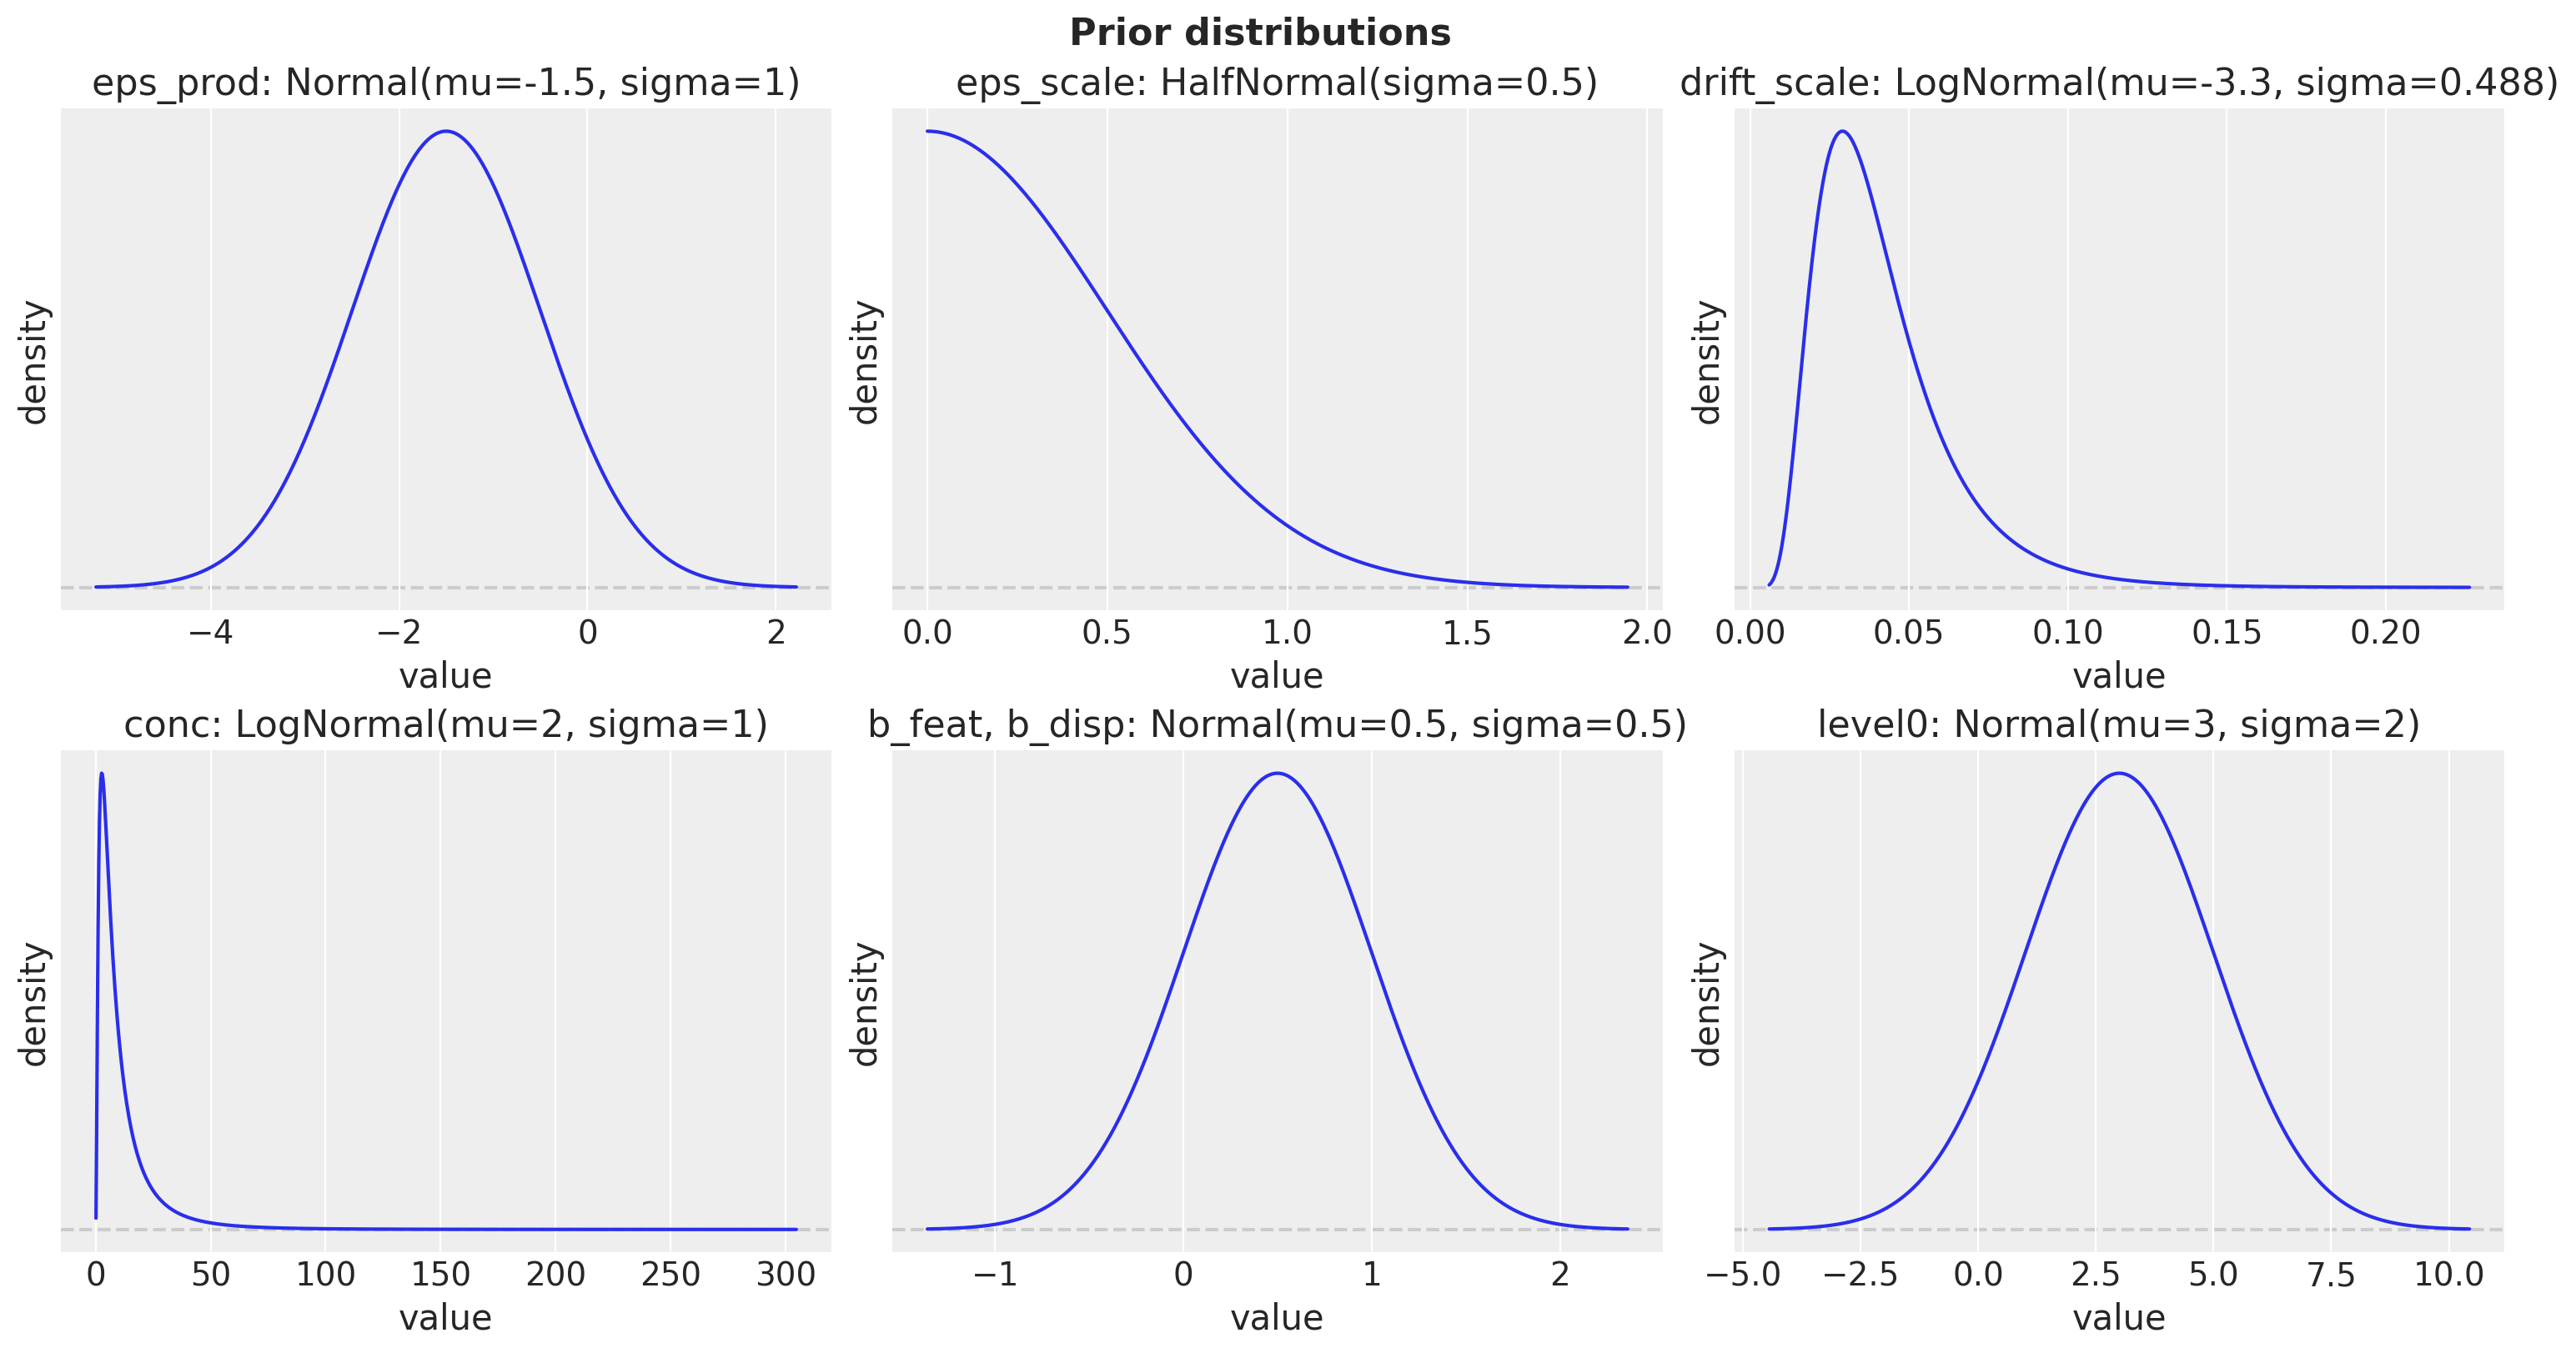

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), layout="constrained")
panels = ["eps_prod", "eps_scale", "drift_scale", "conc", "b_feat, b_disp", "level0"]
for ax, site in zip(axes.ravel(), panels, strict=True):
    prior_distributions[site].plot_pdf(ax=ax, legend=None, color="C0")
    ax.set(title=f"{site}: {prior_distributions[site]}", xlabel="value", ylabel="density")
fig.suptitle("Prior distributions", fontsize=16, fontweight="bold");

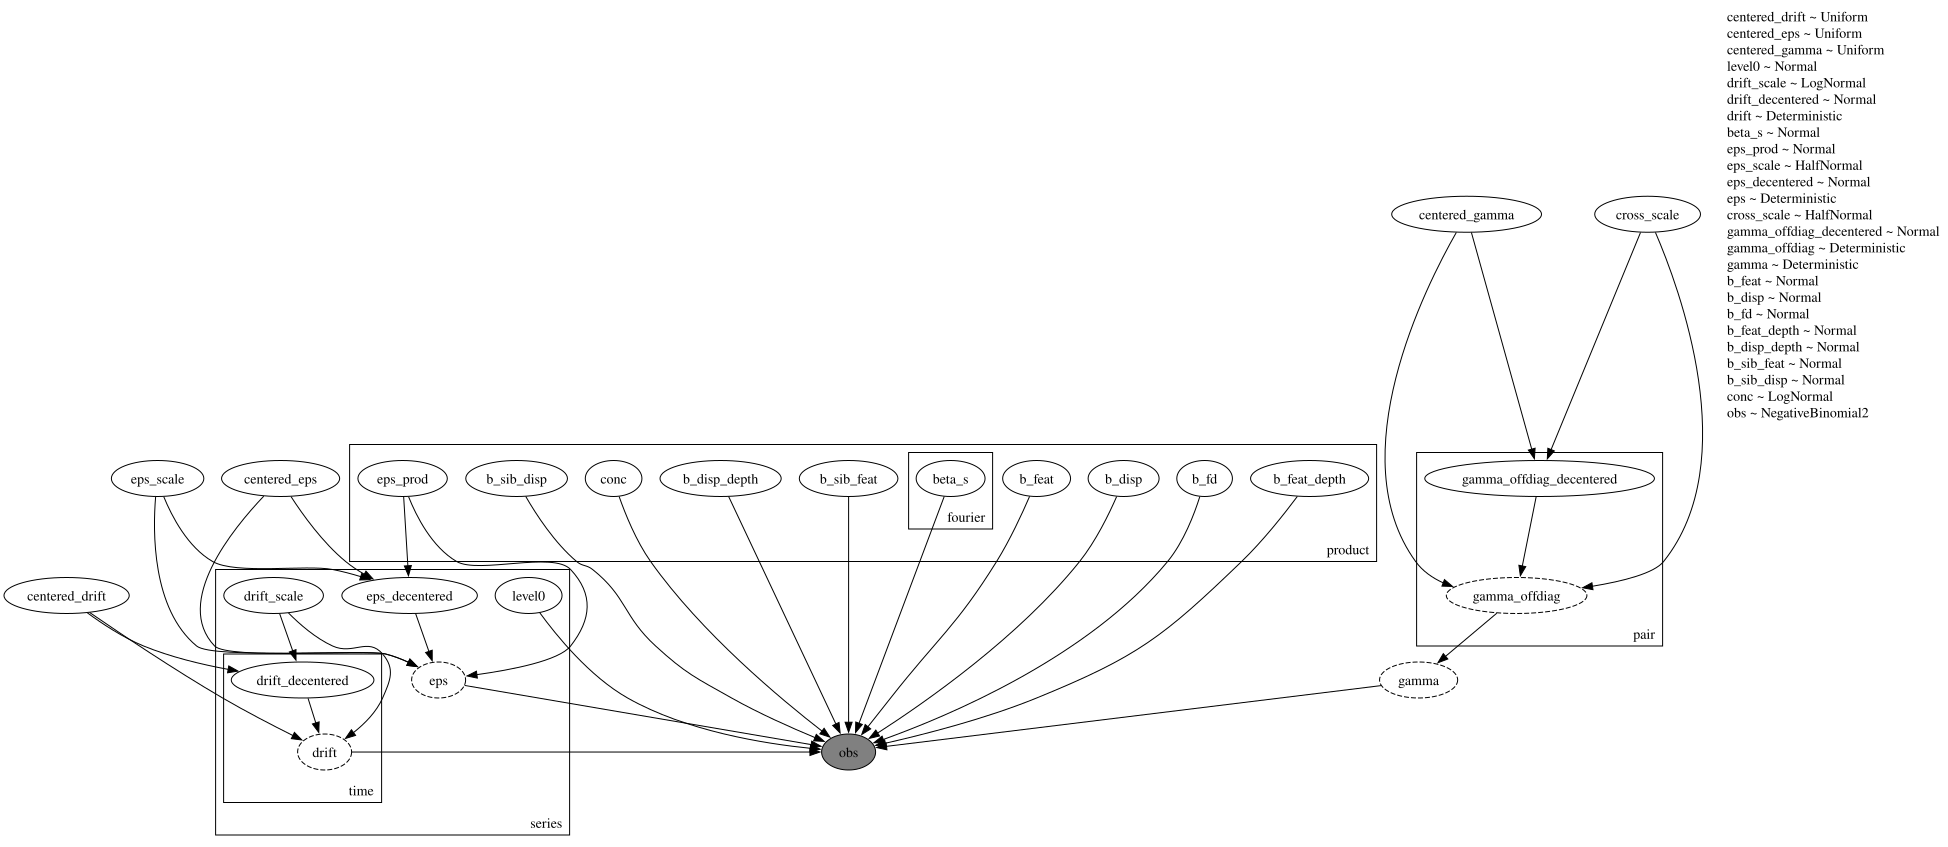

In [26]:
model = make_cereal_model(series_to_product, fourier_full, priors, n_products, n_series)
numpyro.render_model(model, model_args=(covariates_train, y_train), render_distributions=True)

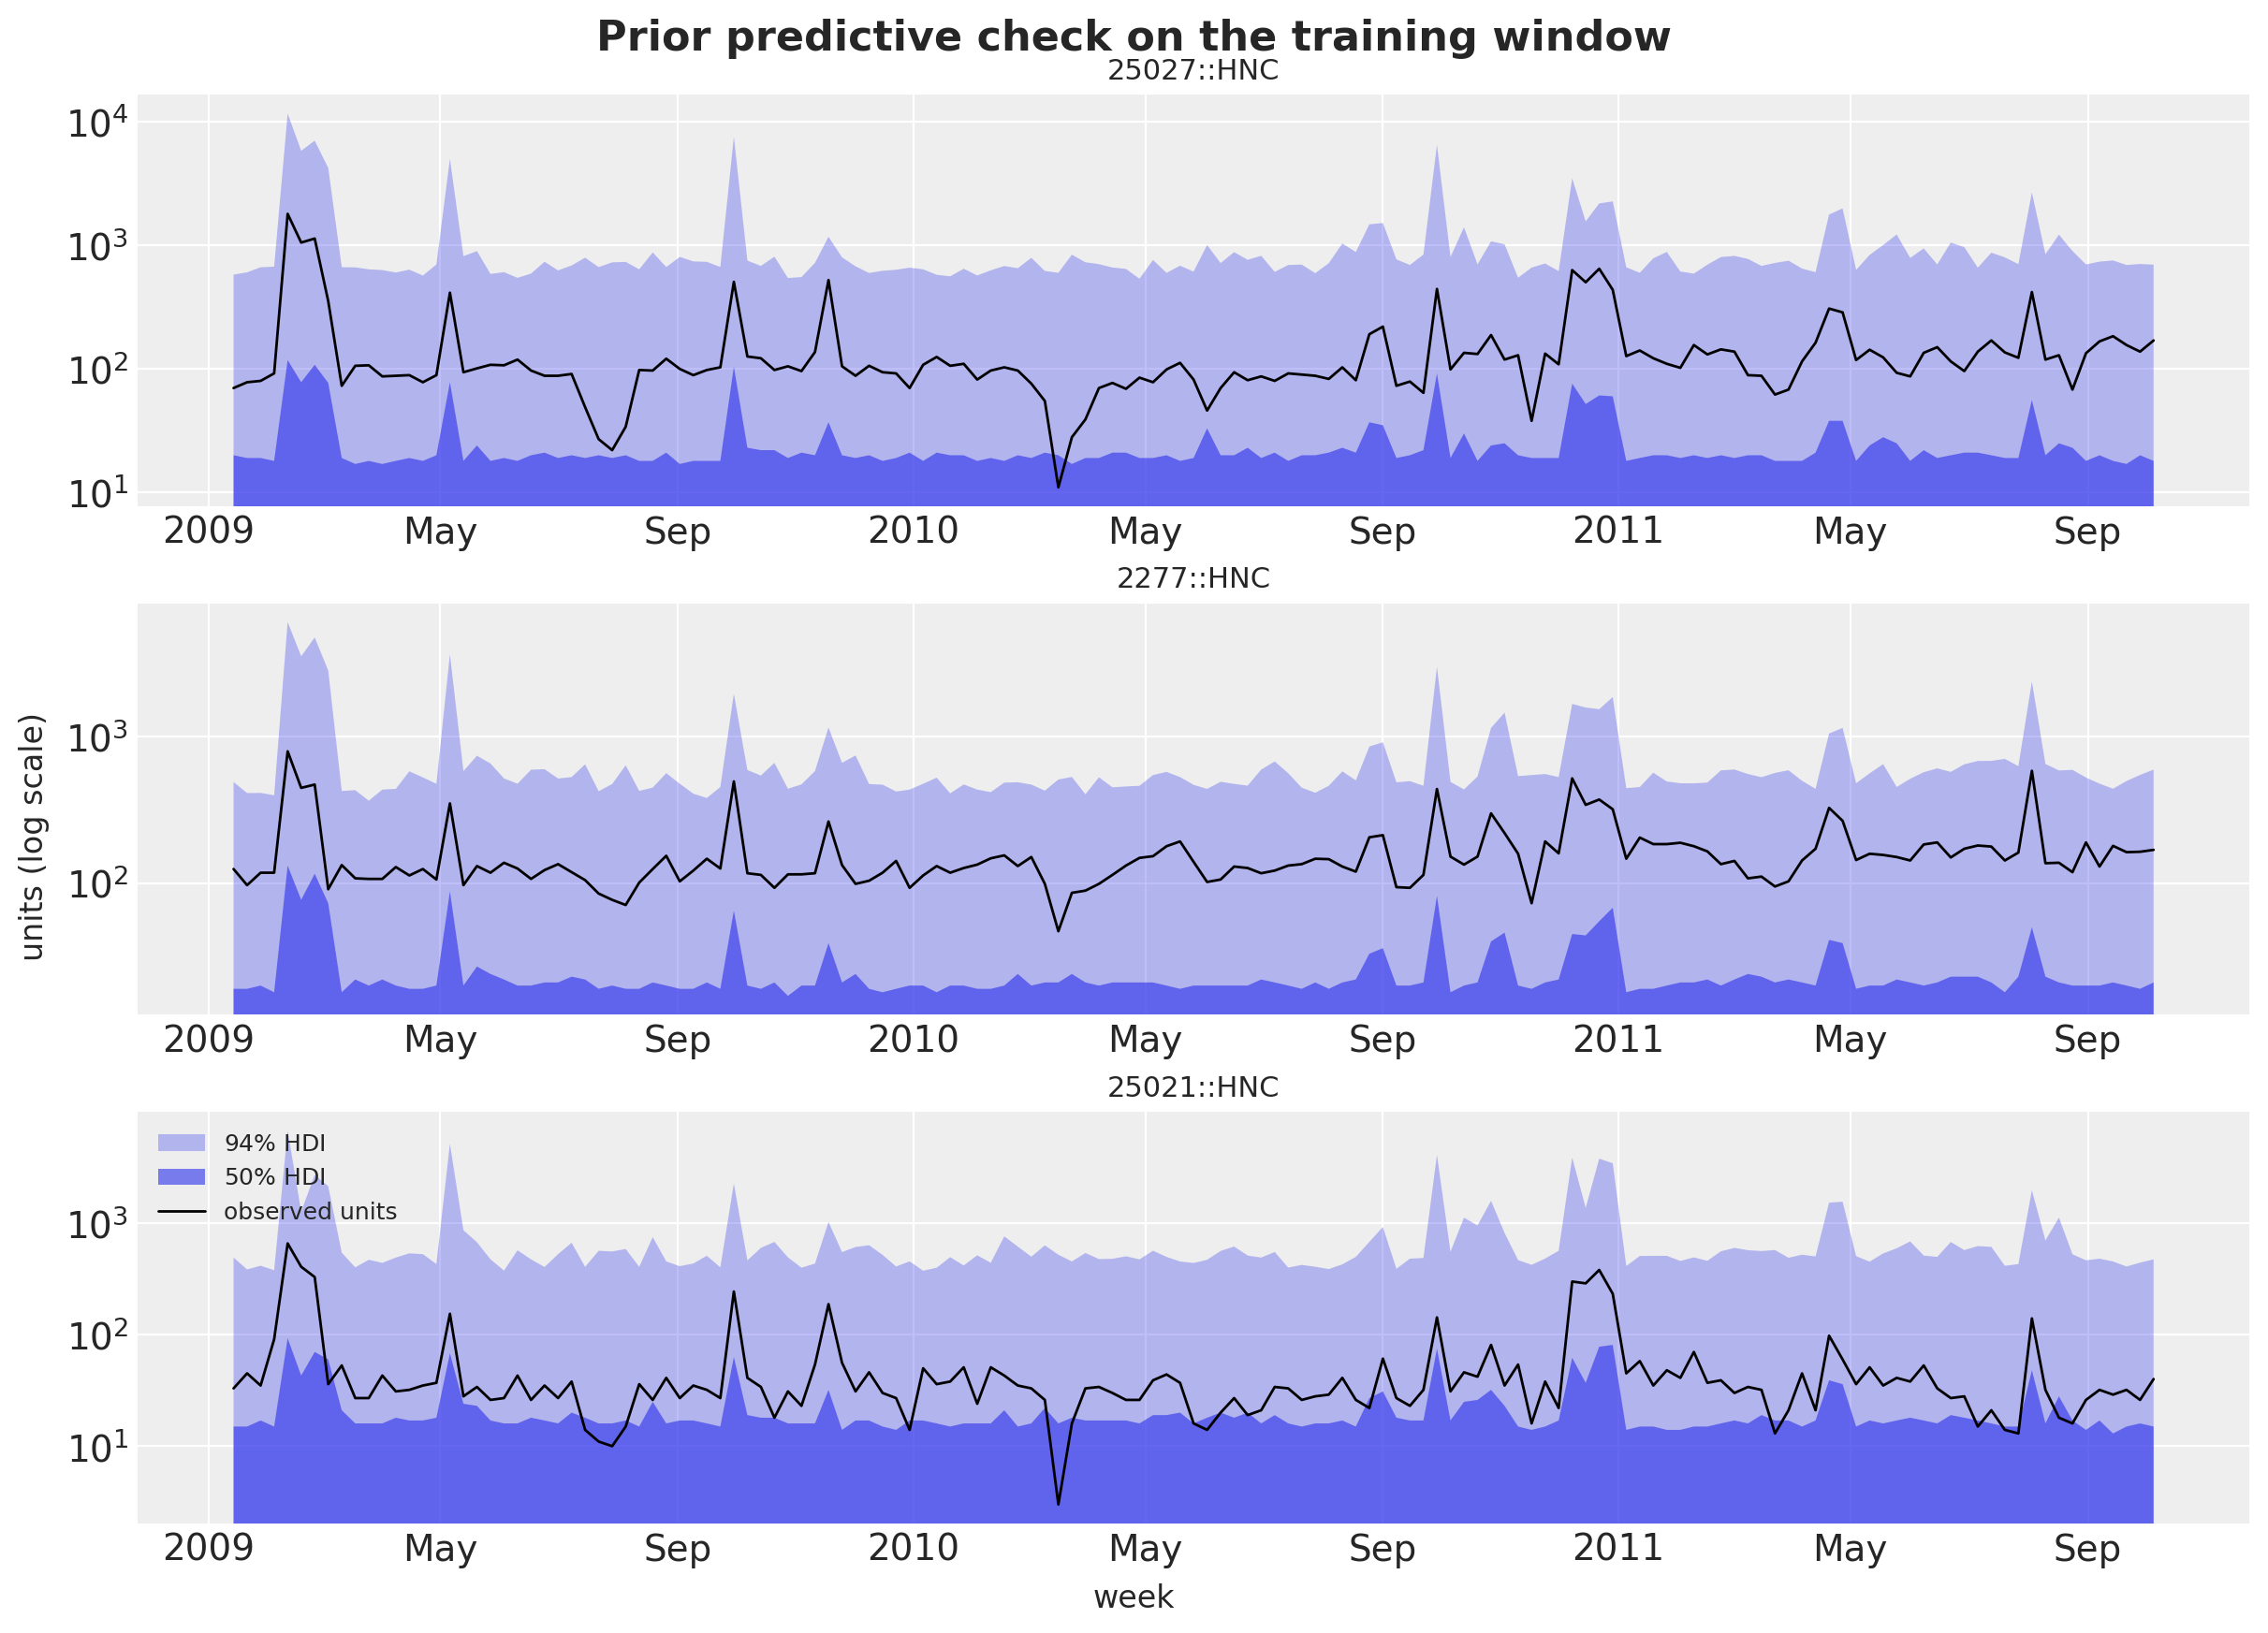

In [27]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


def hdi_bounds(draws: Float[np.ndarray, " sample"], prob: float) -> tuple[float, float]:
    """Highest density interval of one-dimensional draws (the shortest interval with mass ``prob``)."""
    ordered = np.sort(np.asarray(draws, dtype=np.float64))
    n_draws = ordered.size
    width = int(np.floor(prob * n_draws))
    widths = ordered[width:] - ordered[: n_draws - width]
    start = int(np.argmin(widths))
    return float(ordered[start]), float(ordered[start + width])


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]

rng_key, key_prior = random.split(rng_key)
prior_sites = ["obs", "eps_prod", "b_feat", "b_disp", "b_fd", "b_feat_depth", "b_disp_depth"]
prior_draws = Predictive(model, num_samples=500, return_sites=prior_sites)(
    key_prior, covariates_train
)
prior_obs = np.asarray(prior_draws["obs"], dtype=np.float32)

pc = az.plot_lm(
    predictions_to_datatree(
        prior_obs[:, :, [series_ids.index(label) for label in focus_labels]],
        dates_num[:t_train],
        focus_labels,
        group="prior_predictive",
    ),
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    col_wrap=1,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 2.8 * len(focus_labels))},
)
truth_da = (
    panel_ds["units"]
    .isel(time=slice(None, t_train))
    .sel(series=focus_labels)
    .assign_coords(time=dates_num[:t_train])
    .rename("t")
)
x_da = xr.DataArray(dates_num[:t_train], dims=["time"], coords={"time": dates_num[:t_train]})
pc.map(
    az.visuals.line_xy, "truth", data=truth_da, x=x_da, ignore_aes=pc.aes_set, color="black", lw=1
)
for label in focus_labels:
    ax = pc.get_target("t", {"series": label})
    ax.set_title(label, fontsize=11)
    ax.set_yscale("log")
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
bands = pc.viz["ci_band"]["t"].sel(series=focus_labels[-1])
band_handles = []
for prob in (0.94, 0.5):
    band = bands.sel(prob=prob).item()
    band.set_label(hdi_label(prob))
    band_handles.append(band)
truth_line = pc.viz["truth"]["t"].sel(series=focus_labels[-1]).item()
truth_line.set_label("observed units")
pc.get_target("t", {"series": focus_labels[-1]}).legend(
    handles=[*band_handles, truth_line], loc="upper left", fontsize=9
)
fig = pc.viz["figure"].item()
fig.supxlabel("week")
fig.supylabel("units (log scale)")
fig.suptitle(
    "Prior predictive check on the training window", fontsize=16, fontweight="bold", y=1.02
);

In [28]:
depth_check = 0.35
lam_check = float(-np.log1p(-depth_check))
eps_prior = np.asarray(prior_draws["eps_prod"])[:, FOCAL_INDEX]
uplift_prior = np.exp(
    np.asarray(prior_draws["b_feat"])[:, FOCAL_INDEX]
    + np.asarray(prior_draws["b_disp"])[:, FOCAL_INDEX]
    + np.asarray(prior_draws["b_fd"])[:, FOCAL_INDEX]
)
eps_m_prior = (
    eps_prior
    - np.asarray(prior_draws["b_feat_depth"])[:, FOCAL_INDEX]
    - np.asarray(prior_draws["b_disp_depth"])[:, FOCAL_INDEX]
)
multiplier_prior = uplift_prior * (1.0 - depth_check) ** eps_m_prior
lower_m, upper_m = hdi_bounds(multiplier_prior, 0.94)
print(
    f"prior implied HNC multiplier at a {depth_check:.0%} cut with feature + display: "
    f"median {np.median(multiplier_prior):.1f}x, 94% HDI {lower_m:.1f}x to {upper_m:.1f}x"
)

prior implied HNC multiplier at a 35% cut with feature + display: median 4.5x, 94% HDI 0.3x to 27.5x


## Inference

### The parameterization, learned with SVI

The three centering values decide how the sampler sees the hierarchy. At $0$ a site is drawn as a standard normal and shifted and scaled afterwards; at $1$ it is drawn on its own scale. A reparameterization leaves the posterior unchanged, so NUTS cannot choose between them. A mean-field variational approximation can: the ELBO of an `AutoNormal` guide depends on the parameterization, because a diagonal Gaussian fits one geometry better than the other. So we run a short SVI pass first, read the fitted centering values from the guide, and hand them to NUTS through `handlers.condition`, which fixes the three sites at those values. The guide's draws are used for nothing else. The ELBO curve is the convergence check of the pass. How to read the learned values: near $0$ the non-centered form fits a mean-field Gaussian best, near $1$ the centered form, and small innovation scales push the drift value toward $0$. The pass takes $13$ seconds of wall time for $5{,}000$ Adam steps, and the negative ELBO is flat over the second half of the run: the mean of the last $500$ steps is $63{,}502$ against $63{,}543$ for steps $3{,}000$ to $3{,}500$. The learned values are $0.34$ for the level innovations, $0.68$ for the store elasticities and $0.40$ for the cross terms, with $90\%$ intervals of the guide from $0.33$ to $0.34$, from $0.66$ to $0.70$ and from $0.36$ to $0.45$: the innovations and the cross terms lean toward the non-centered form, the store elasticities toward the centered one.

In [29]:
%%time

guide = AutoNormal(model, init_loc_fn=init_to_median)
svi = SVI(model, guide, Adam(step_size=0.01), Trace_ELBO())
rng_key, key_svi = random.split(rng_key)
svi_result = svi.run(key_svi, 5_000, covariates_train, y_train, progress_bar=False)
svi_losses = np.asarray(jax.block_until_ready(svi_result.losses))

CPU times: user 26.1 s, sys: 15.6 s, total: 41.7 s
Wall time: 12.6 s


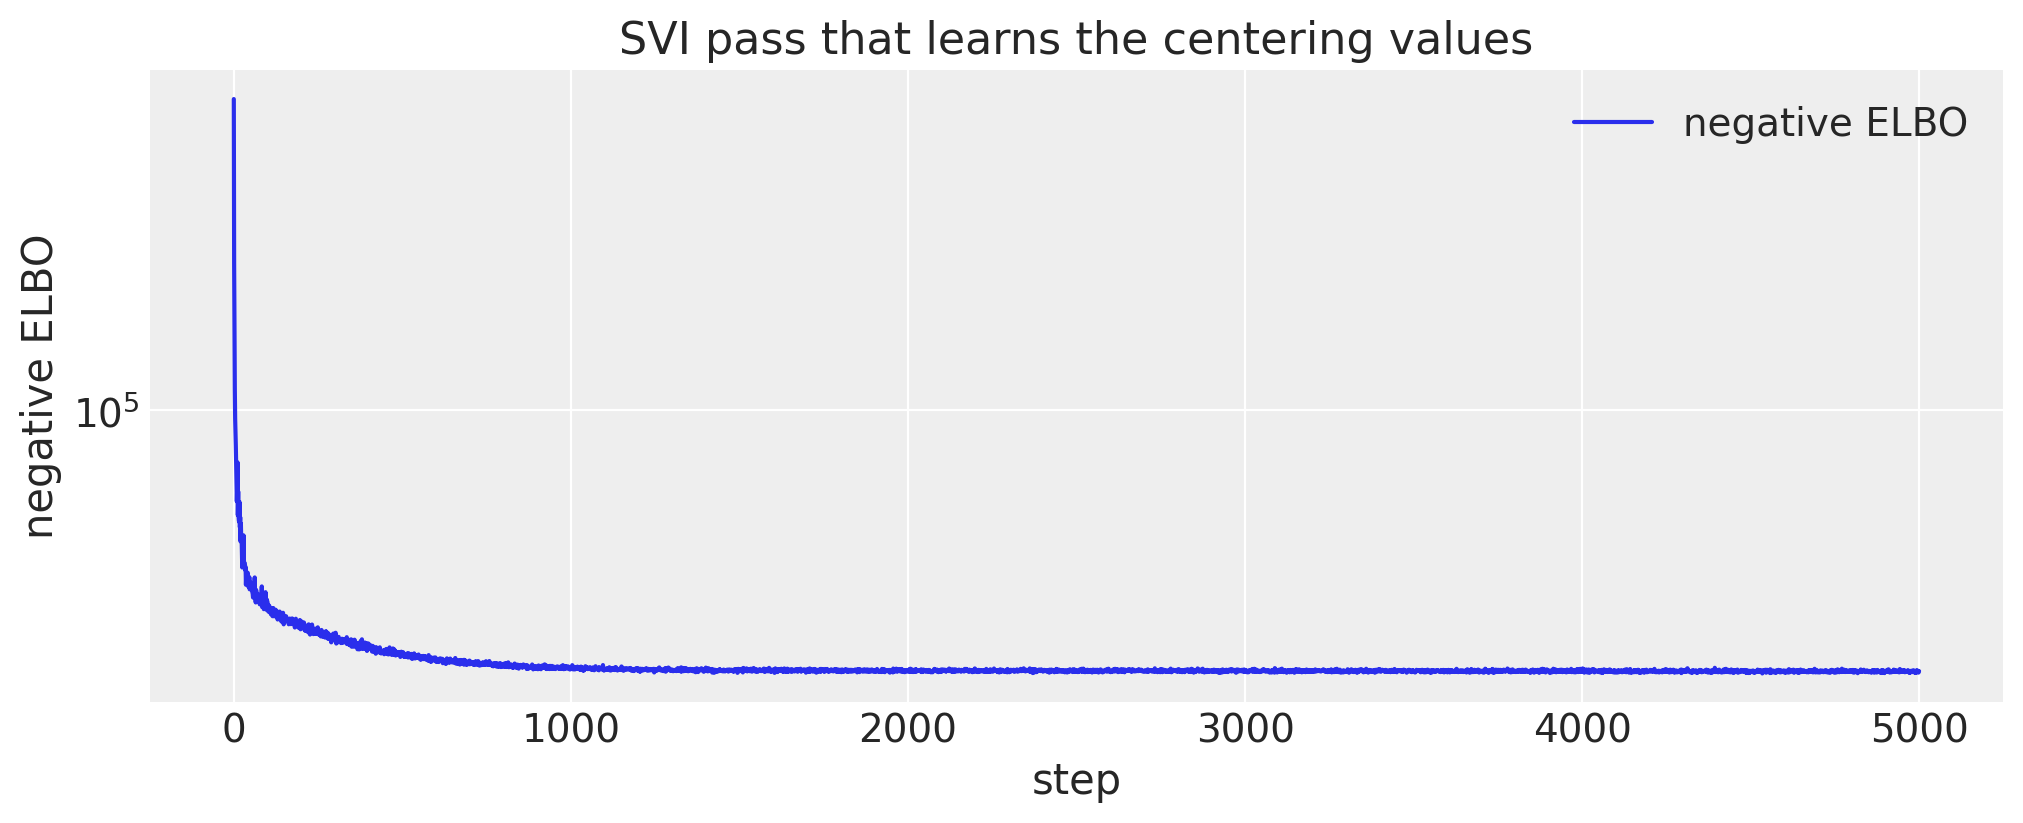

In [30]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(svi_losses, color="C0", label="negative ELBO")
ax.set_yscale("log")
ax.legend(loc="upper right")
ax.set(title="SVI pass that learns the centering values", xlabel="step", ylabel="negative ELBO");

In [31]:
centering_median = guide.median(svi_result.params)
centering_quantiles = guide.quantiles(svi_result.params, [0.05, 0.95])
centering_table = pl.DataFrame(
    {
        "site": CENTERING_SITES,
        "learned centering": [round(float(centering_median[name]), 3) for name in CENTERING_SITES],
        "q05": [round(float(centering_quantiles[name][0]), 3) for name in CENTERING_SITES],
        "q95": [round(float(centering_quantiles[name][1]), 3) for name in CENTERING_SITES],
    }
)
learned_centering: dict[str, ArrayLike] = {
    name: jnp.asarray(centering_median[name], dtype=jnp.float32) for name in CENTERING_SITES
}
# NUTS samples the model with the three centering sites fixed at the learned values.
nuts_model = handlers.condition(model, data=learned_centering)
print(
    f"final loss {svi_losses[-1]:,.0f} | mean of the last 500 steps {svi_losses[-500:].mean():,.0f} "
    f"| mean of steps 3,000 to 3,500 {svi_losses[3_000:3_500].mean():,.0f}"
)
centering_table

final loss 63,524 | mean of the last 500 steps 63,502 | mean of steps 3,000 to 3,500 63,543


site,learned centering,q05,q95
"""centered_drift""",0.336,0.334,0.338
"""centered_eps""",0.677,0.655,0.698
"""centered_gamma""",0.404,0.363,0.446


### Sampling with NUTS

The panel is small enough for full NUTS: four chains of $1{,}000$ warmup and $1{,}000$ draws each, run in parallel on four host devices, on the model conditioned on the learned centering values. Two settings matter. The initialization is `init_to_median`, because NumPyro's default uniform initialization in the unconstrained space can put the cumulative level of a series far outside the range where the negative binomial mean is finite. And we ask NUTS for the number of leapfrog steps of every iteration, which gives the tree depth: a sampler stuck at the depth cap of 10 is the sign of a badly conditioned posterior. The fit takes $8$ minutes and $20$ seconds of wall time, with no divergences and every iteration at tree depth 8, so the depth cap is never reached.

In [32]:
%%time


def fit_nuts(rng_key: Array, model: ForecastModel, data: Array, covariates: Array) -> MCMC:
    """Fit ``model`` with NUTS (4 chains, 1,000 warmup and 1,000 draws each, median init)."""
    mcmc = MCMC(
        NUTS(model, target_accept_prob=0.9, init_strategy=init_to_median()),
        num_warmup=1_000,
        num_samples=1_000,
        num_chains=4,
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data, extra_fields=("diverging", "num_steps"))
    return mcmc


rng_key, key_fit = random.split(rng_key)
mcmc = fit_nuts(key_fit, nuts_model, y_train, covariates_train)
# The chains run asynchronously on the host devices; block on the draws so the wall time is real.
posterior = jax.block_until_ready(mcmc.get_samples())
assert not any(name in posterior for name in CENTERING_SITES), "the centering sites must be fixed"
n_draws = int(posterior["eps_prod"].shape[0])

CPU times: user 56min 16s, sys: 16min 26s, total: 1h 12min 42s
Wall time: 8min 20s


In [33]:
num_steps = np.asarray(mcmc.get_extra_fields()["num_steps"])
tree_depth = np.ceil(np.log2(num_steps + 1)).astype(int)
depth_values, depth_counts = np.unique(tree_depth, return_counts=True)
print(
    f"posterior draws: {n_draws} | divergences: {int(np.asarray(mcmc.get_extra_fields()['diverging']).sum())}"
)
print(f"share of iterations at the depth-10 cap: {np.mean(num_steps == 1023):.1%}")
pl.DataFrame({"tree_depth": depth_values, "share": depth_counts / depth_counts.sum()})

posterior draws: 4000 | divergences: 0
share of iterations at the depth-10 cap: 0.0%


tree_depth,share
8,1.0


## Diagnostics

The posterior, the in-sample predictive and the holdout forecast go into one ArviZ tree with named coordinates. The convergence table lists the product-level parameters and the hyperparameters: the maximum $\hat R$ is $1.01$, on the mechanics effects of Cheerios 18 oz, the product with the fewest identifying weeks, and the smallest bulk effective sample size is 608, for the private-label twin's concentration. The centering values are constants of the NUTS run, so they do not appear in the table. The trace plots show the six hyperparameters with overlapping chains and no drift.

In [34]:
coords = {
    "series": series_ids,
    "obs_dim": series_ids,
    "product": product_order,
    "competitor": product_order,
    "pair": pair_labels,
    "fourier": fourier_names,
    "input": input_names,
}
product_sites = [
    "eps_prod",
    "conc",
    "b_feat",
    "b_disp",
    "b_fd",
    "b_feat_depth",
    "b_disp_depth",
    "b_sib_feat",
    "b_sib_disp",
]
posterior_dims = {
    "level0": ["series"],
    "drift_scale": ["series"],
    "eps": ["series"],
    "eps_decentered": ["series"],
    "drift": ["time", "series"],
    "drift_decentered": ["time", "series"],
    **{site: ["product"] for site in product_sites},
    "beta_s": ["fourier", "product"],
    "gamma": ["competitor", "product"],
    "gamma_offdiag": ["pair"],
    "gamma_offdiag_decentered": ["pair"],
}
rng_key, key_tree = random.split(rng_key)
tree = to_datatree(
    key_tree,
    nuts_model,
    posterior,
    y_train,
    covariates,
    num_chains=4,
    time_coord=list(dates),
    covariate_dims=["input", "time", "series"],
    coords=coords,
    posterior_dims=posterior_dims,
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:                   (chain: 4, draw: 1000, product: 6, fourier: 4,
│                                      time: 143, series: 108, competitor: 6, pair: 30)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│         * product                   (product) <U17 408B 'HNC' ... 'PL Frosted Wheat'
│         * fourier                   (fourier) <U4 64B 'sin1' 'sin2' 'cos1' 'cos2'
│         * time                      (time) datetime64[s] 1kB 2009-01-14 ... 2011-10-05
│         * series                    (series) <U24 10kB '25027::HNC' ... '6431::PL F...
│         * competitor                (competitor) <U17 408B 'HNC' ... 'PL Frosted Wh...
│         * pair                      (pair) <U37 4kB 'HNC -> Cheerios 12oz' ... 'PL ...
│       Data variables: (12/21)
│           b_disp                    (chain, draw, product) float32 96kB 0.3411 ... ...
│           b_disp_depth              (chain, draw, product) float32 96kB -0.02473 .....
│           b_fd                      (chain, draw, product) float32 96kB 0.01275 ......
│           b_feat                    (chain, draw, product) float32 96kB 0.7142 ... ...
│           b_feat_depth              (chain, draw, product) float32 96kB 0.154 ... -...
│           b_sib_disp                (chain, draw, product) float32 96kB -0.03467 .....
│           ...                        ...
│           eps_prod                  (chain, draw, product) float32 96kB -1.244 ... ...
│           eps_scale                 (chain, draw) float32 16kB 0.4144 ... 0.3397
│           gamma                     (chain, draw, competitor, product) float32 576kB ...
│           gamma_offdiag             (chain, draw, pair) float32 480kB 0.06844 ... 0...
│           gamma_offdiag_decentered  (chain, draw, pair) float32 480kB 0.1501 ... 0....
│           level0                    (chain, draw, series) float32 2MB 4.558 ... 2.814
│       Attributes:
│           created_at:                 2026-09-07T13:25:52.911307+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 143, obs_dim: 108)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) datetime64[s] 1kB 2009-01-14 2009-01-21 ... 2011-10-05
│         * obs_dim  (obs_dim) <U24 10kB '25027::HNC' ... '6431::PL Frosted Wheat'
│       Data variables:
│           obs      (chain, draw, time, obs_dim) int32 247MB 89 146 49 37 ... 16 5 32
│       Attributes:
│           created_at:                 2026-09-07T13:26:10.486057+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 143, obs_dim: 108)
│       Coordinates:
│         * time     (time) datetime64[s] 1kB 2009-01-14 2009-01-21 ... 2011-10-05
│         * obs_dim  (obs_dim) <U24 10kB '25027::HNC' ... '6431::PL Frosted Wheat'
│       Data variables:
│           obs      (time, obs_dim) int32 62kB 70 181 69 46 50 100 ... 19 20 18 14 18
│       Attributes:
│           created_at:                 2026-09-07T13:26:10.488747+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dim

In [35]:
hyper_vars = [*product_sites, "eps_scale", "cross_scale"]
summary = az.summary(tree, var_names=hyper_vars, ci_kind="hdi", ci_prob=0.94)
print(
    f"max r_hat: {summary['r_hat'].astype(float).max():.3f} | "
    f"min ess_bulk: {summary['ess_bulk'].astype(float).min():.0f}"
)
summary

max r_hat: 1.010 | min ess_bulk: 608


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eps_prod[HNC],-1.083,0.11,-1.3,-0.88,2491,2882,1.00,0.0022,0.0016
eps_prod[Cheerios 12oz],-0.381,0.081,-0.53,-0.23,2609,2527,1.00,0.0016,0.0011
eps_prod[Cheerios 18oz],-1.912,0.151,-2.2,-1.6,1492,2075,1.00,0.0039,0.0028
eps_prod[Mini Wheats],-1.946,0.126,-2.2,-1.7,3161,2903,1.00,0.0022,0.0016
eps_prod[PL Honey Nut Oats],-1.927,0.157,-2.2,-1.6,2908,3202,1.00,0.0029,0.0021
eps_prod[PL Frosted Wheat],-1.034,0.106,-1.2,-0.84,4621,3130,1.00,0.0016,0.0011
conc[HNC],17.19,0.79,16,19,693,1865,1.00,0.03,0.021
conc[Cheerios 12oz],19.18,0.83,18,21,2424,2505,1.00,0.017,0.012
conc[Cheerios 18oz],21.95,1.04,20,24,4087,2338,1.00,0.016,0.012
conc[Mini Wheats],18.85,0.87,17,21,3125,2535,1.00,0.016,0.011


In [36]:
az.summary(tree, var_names=["gamma_offdiag"], ci_kind="hdi", ci_prob=0.94)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gamma_offdiag[HNC -> Cheerios 12oz],0.11,0.048,0.019,0.2,3393,2868,1.00,0.00083,0.00057
gamma_offdiag[HNC -> Cheerios 18oz],0.017,0.047,-0.073,0.1,3511,2855,1.00,0.00079,0.00057
gamma_offdiag[HNC -> Mini Wheats],-0.025,0.048,-0.12,0.063,4237,3108,1.00,0.00074,0.00053
gamma_offdiag[HNC -> PL Honey Nut Oats],0.695,0.053,0.59,0.79,5078,3882,1.00,0.00075,0.00054
gamma_offdiag[HNC -> PL Frosted Wheat],0.079,0.0453,-0.0059,0.16,4401,3288,1.00,0.00068,0.00045
gamma_offdiag[Cheerios 12oz -> HNC],-0.25,0.0393,-0.32,-0.18,4343,3033,1.00,0.0006,0.00042
gamma_offdiag[Cheerios 12oz -> Cheerios 18oz],0.15,0.0353,0.084,0.22,4075,2895,1.00,0.00055,0.0004
gamma_offdiag[Cheerios 12oz -> Mini Wheats],0.032,0.0379,-0.04,0.1,4121,3014,1.00,0.00059,0.00044
gamma_offdiag[Cheerios 12oz -> PL Honey Nut Oats],-0.056,0.0411,-0.14,0.02,3980,3025,1.00,0.00065,0.00046
gamma_offdiag[Cheerios 12oz -> PL Frosted Wheat],-0.008,0.0348,-0.074,0.058,4059,3129,1.00,0.00055,0.00039


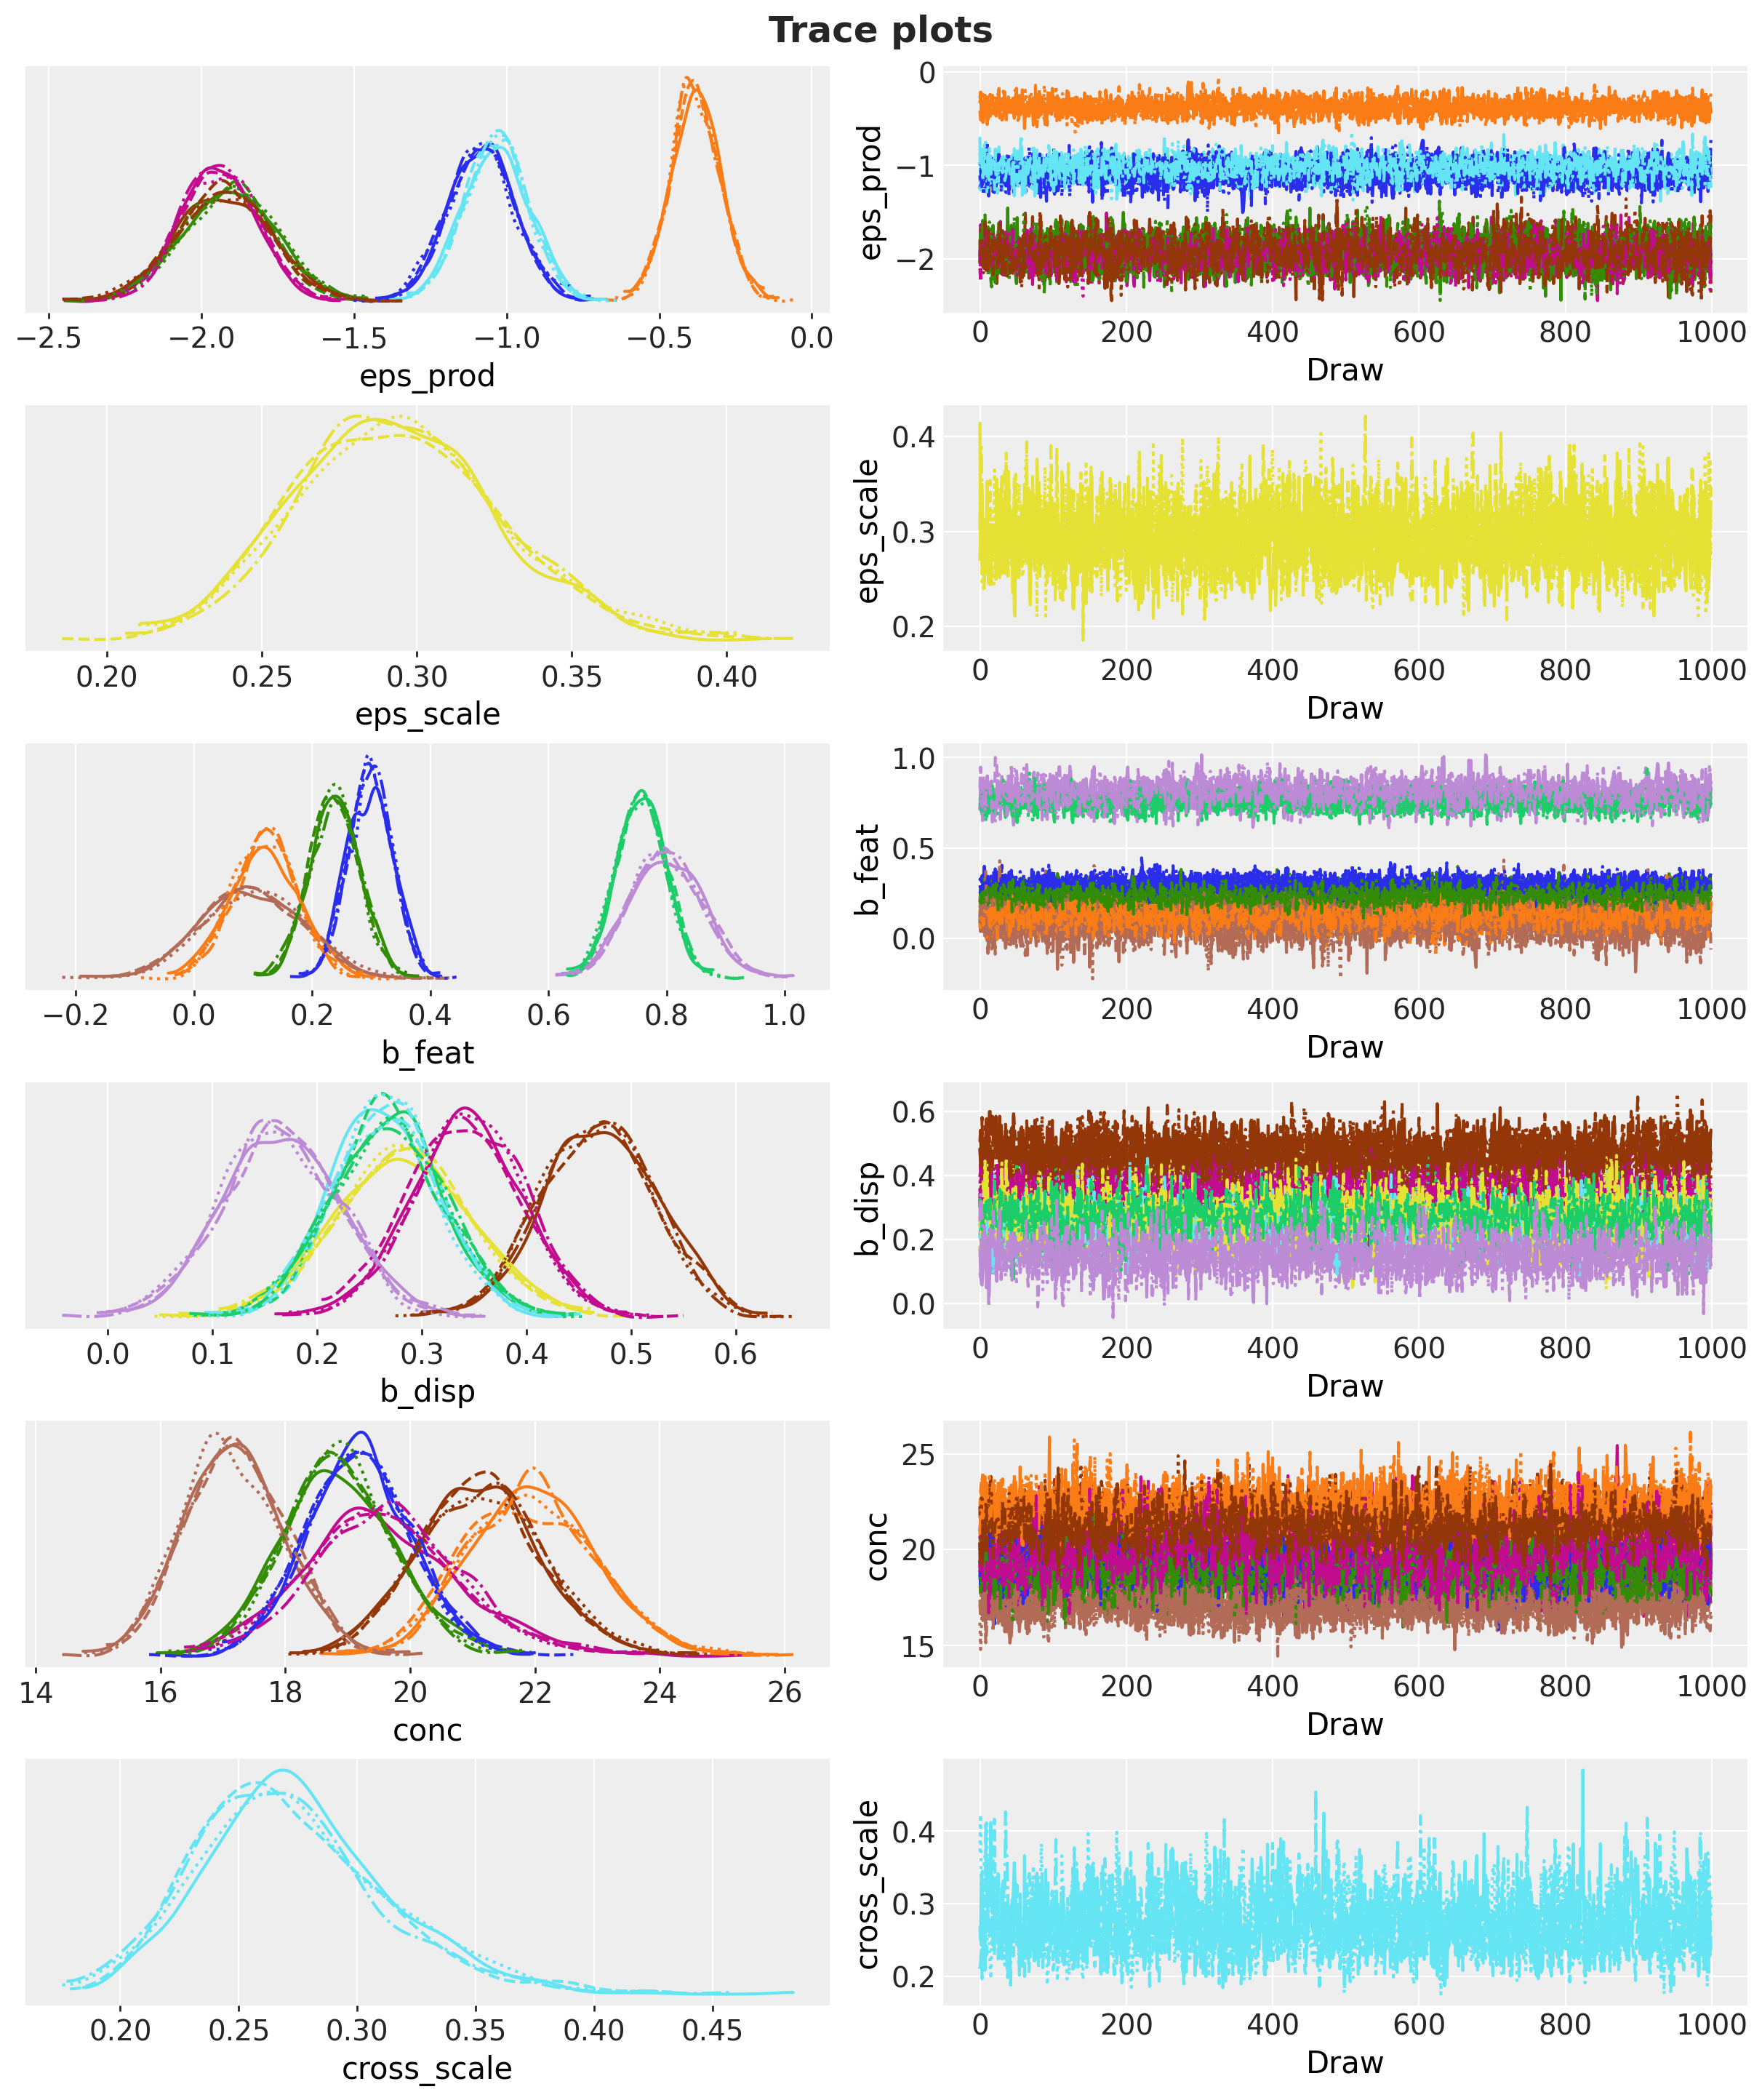

In [37]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=["eps_prod", "eps_scale", "b_feat", "b_disp", "conc", "cross_scale"],
    compact=True,
    figure_kwargs={"figsize": (12, 14)},
)
pc_trace.viz["figure"].item().suptitle("Trace plots", fontsize=18, fontweight="bold", y=1.02);

## What the model learned

The first table puts the posterior of each product's own elasticity next to the least-squares estimates with and without the depth slopes. A model whose feature and display effects fall far below the least-squares ones would be a model whose random-walk level absorbs the promotion spikes; the second table compares the mechanics multipliers. The forest plots show the own elasticities and the mechanics effects with their $50\%$ and $94\%$ HDIs, annotated with the identifying store-weeks; the heatmap shows the cross matrix, its cells annotated with the posterior probability of a positive cross elasticity (a positive value means that a cheaper competitor takes units away). The store-level plot of the focal product's elasticity shows the partial pooling at work: the within-store least-squares estimates scatter widely, the posterior medians shrink toward the product mean.

The focal product's elasticity has a posterior median of $-1.08$ ($94\%$ HDI $-1.29$ to $-0.88$), on top of the least-squares estimate with depth slopes. Cheerios 18 oz, with 23 identifying store-weeks, still gets a median of $-1.91$ (HDI $-2.21$ to $-1.64$), because its cut depth varies inside its feature and display weeks. The feature multiplier of the focal product is $2.13$ (HDI $1.96$ to $2.29$) and the display multiplier $1.41$ (HDI $1.27$ to $1.55$), above and near the pooled least-squares multipliers of $1.65$ and $1.49$, so the level is not absorbing the promotion spikes. The depth slopes under feature and display of the focal product are centered near zero, so its mechanics-specific elasticities differ little from the plain one. The cross matrix has one large cell: the focal product's price on the private-label twin's units, $+0.69$ (HDI $+0.59$ to $+0.79$, posterior probability of a positive value $1.00$), while the twin's price barely moves the focal product ($-0.08$, HDI $-0.28$ to $+0.13$). The store-level elasticities of the focal product have a least-squares spread of $0.37$ across stores and a posterior-median spread of $0.31$, the shrinkage the planner section uses. The posterior-mean seasonal component peaks in horizon week 12, the week of December 28, and the level innovation scales range from $0.019$ to $0.218$ across series.

In [38]:
eps_prod_draws = np.asarray(posterior["eps_prod"])


def interval_row(draws: Float[np.ndarray, " sample"]) -> dict[str, float]:
    r"""Posterior median with the $50\%$ and $94\%$ HDI bounds of one-dimensional draws."""
    lower_50, upper_50 = hdi_bounds(draws, 0.5)
    lower_94, upper_94 = hdi_bounds(draws, 0.94)
    return {
        "median": float(np.median(draws)),
        "hdi50_lower": lower_50,
        "hdi50_upper": upper_50,
        "hdi94_lower": lower_94,
        "hdi94_upper": upper_94,
    }


elasticity_table = pl.DataFrame(
    [
        {
            "product": product,
            "ols_with_flags": float(
                own_elasticity_ols.filter(pl.col("product") == product)["with_flags"][0]
            ),
            "ols_with_depth_slopes": float(
                own_elasticity_ols.filter(pl.col("product") == product)["with_depth_slopes"][0]
            ),
            **interval_row(eps_prod_draws[:, k]),
        }
        for k, product in enumerate(product_order)
    ]
)
elasticity_table

product,ols_with_flags,ols_with_depth_slopes,median,hdi50_lower,hdi50_upper,hdi94_lower,hdi94_upper
"""HNC""",-1.326977,-1.084921,-1.082029,-1.139235,-0.994873,-1.289832,-0.875182
"""Cheerios 12oz""",-0.3183,-0.31104,-0.382625,-0.429511,-0.323211,-0.537446,-0.232483
"""Cheerios 18oz""",-1.961065,-1.511146,-1.905879,-1.998456,-1.794018,-2.209666,-1.642067
"""Mini Wheats""",-1.558958,-1.626816,-1.94702,-2.027605,-1.857185,-2.186641,-1.711004
"""PL Honey Nut Oats""",-1.446412,-1.468914,-1.927437,-2.046492,-1.83645,-2.222483,-1.633524
"""PL Frosted Wheat""",-0.8505,-0.886696,-1.032909,-1.094682,-0.956179,-1.218427,-0.823438


In [39]:
pooled_flags = within_ols(train_long, ["x", *mechanics_terms, *seasonal_terms])
ols_multipliers = dict(
    zip(pooled_flags["term"].to_list(), np.exp(pooled_flags["coef"].to_numpy()), strict=True)
)
multiplier_rows = []
for site, term in [
    ("b_feat", "feature"),
    ("b_disp", "display"),
    ("b_sib_feat", "sib_feature"),
    ("b_sib_disp", "sib_display"),
]:
    draws_site = np.exp(np.asarray(posterior[site]))
    for k, product in enumerate(product_order):
        multiplier_rows.append(
            {
                "effect": term,
                "product": product,
                "ols_pooled_multiplier": float(ols_multipliers[term]),
                **interval_row(draws_site[:, k]),
            }
        )
multiplier_table = pl.DataFrame(multiplier_rows)
multiplier_table.filter(pl.col("effect").is_in(["feature", "display"]))

effect,product,ols_pooled_multiplier,median,hdi50_lower,hdi50_upper,hdi94_lower,hdi94_upper
"""feature""","""HNC""",1.654384,2.131905,2.06832,2.187409,1.956841,2.291173
"""feature""","""Cheerios 12oz""",1.654384,2.219052,2.126567,2.310077,1.980169,2.486434
"""feature""","""Cheerios 18oz""",1.654384,1.102757,1.036413,1.163704,0.94592,1.291129
"""feature""","""Mini Wheats""",1.654384,1.348858,1.318365,1.387212,1.257218,1.445063
"""feature""","""PL Honey Nut Oats""",1.654384,1.127978,1.079181,1.16256,1.009625,1.245206
"""feature""","""PL Frosted Wheat""",1.654384,1.269117,1.227314,1.298753,1.173447,1.37554
"""display""","""HNC""",1.494406,1.408505,1.356387,1.455645,1.266144,1.546968
"""display""","""Cheerios 12oz""",1.494406,1.599538,1.540608,1.657762,1.447606,1.768491
"""display""","""Cheerios 18oz""",1.494406,1.303566,1.257622,1.343683,1.18035,1.426616
"""display""","""Mini Wheats""",1.494406,1.325217,1.25908,1.37297,1.16014,1.487416


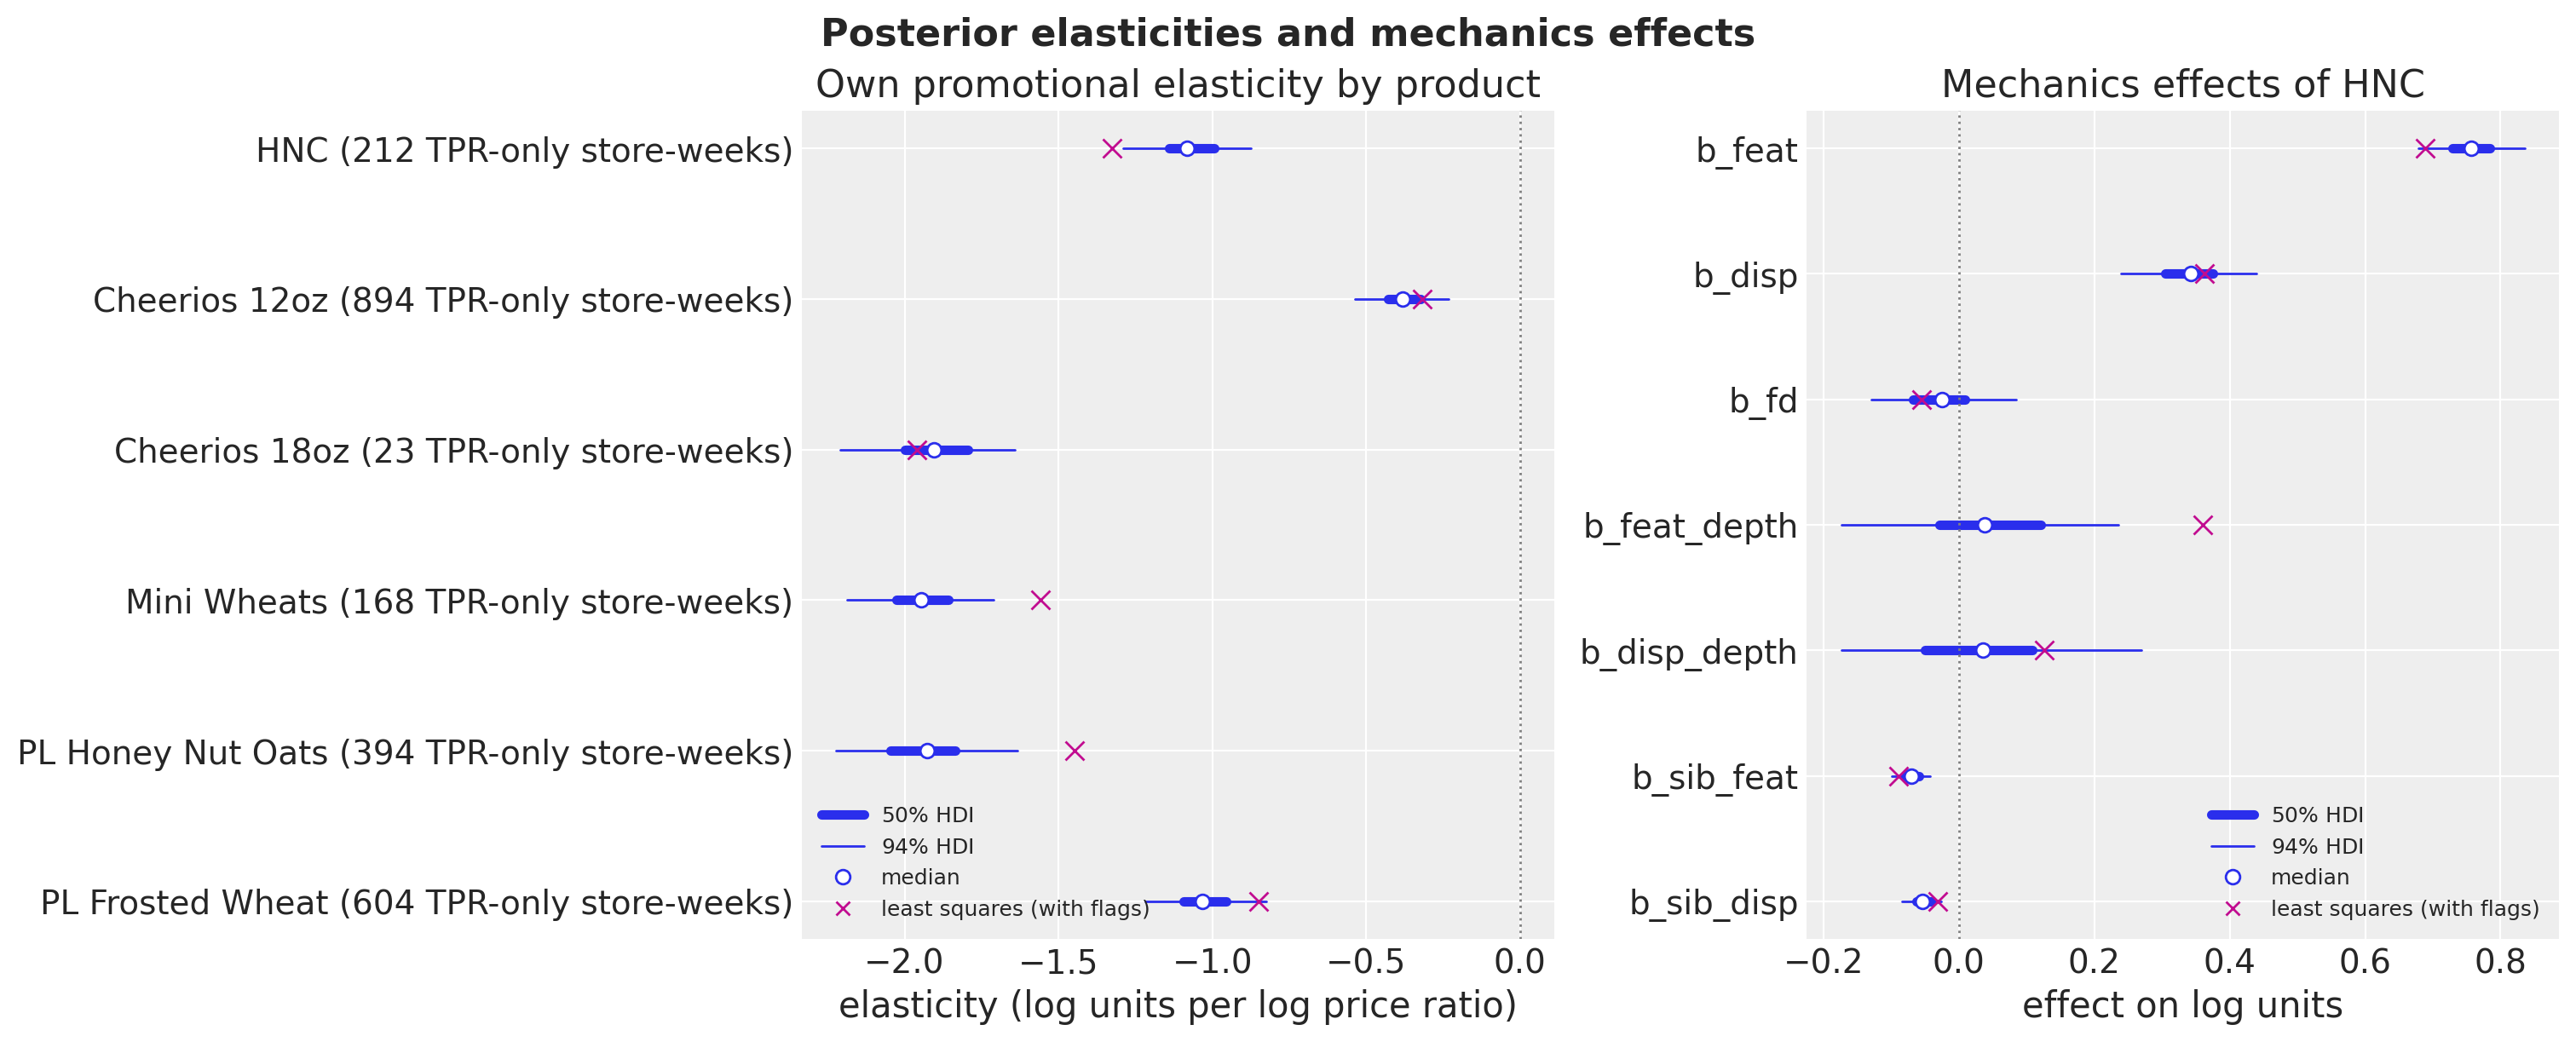

In [40]:
def plot_intervals(
    ax: Axes,
    labels: list[str],
    draws: Float[np.ndarray, " sample k"],
    color: str = "C0",
    reference: Float[np.ndarray, " k"] | None = None,
    reference_label: str = "least squares",
) -> None:
    r"""Draw posterior medians with $50\%$ (thick) and $94\%$ (thin) HDI lines, one row per label."""
    positions = np.arange(len(labels))
    for position, column in zip(positions, range(draws.shape[1]), strict=True):
        lower_94, upper_94 = hdi_bounds(draws[:, column], 0.94)
        lower_50, upper_50 = hdi_bounds(draws[:, column], 0.5)
        ax.plot([lower_94, upper_94], [position, position], color=color, linewidth=1)
        ax.plot([lower_50, upper_50], [position, position], color=color, linewidth=4)
        ax.plot(
            np.median(draws[:, column]),
            position,
            "o",
            color="white",
            markeredgecolor=color,
            markersize=6,
        )
    if reference is not None:
        ax.plot(reference, positions, "x", color="C3", markersize=8, label=reference_label)
    ax.set_yticks(positions, labels)
    ax.invert_yaxis()
    ax.axvline(0.0, color="gray", linestyle=":", linewidth=1)


interval_handles = [
    mlines.Line2D([], [], color="C0", linewidth=4, label=hdi_label(0.5)),
    mlines.Line2D([], [], color="C0", linewidth=1, label=hdi_label(0.94)),
    mlines.Line2D(
        [], [], color="C0", marker="o", markerfacecolor="white", linewidth=0, label="median"
    ),
    mlines.Line2D([], [], color="C3", marker="x", linewidth=0, label="least squares (with flags)"),
]
identifying_weeks = dict(
    zip(identification["product"].to_list(), identification["tpr_only"].to_list(), strict=True)
)
fig, axes = plt.subplots(ncols=2, figsize=(15, 6), layout="constrained")
plot_intervals(
    axes[0],
    [f"{p} ({identifying_weeks[p]} TPR-only store-weeks)" for p in product_order],
    eps_prod_draws,
    reference=own_elasticity_ols.filter(pl.col("product") != "pooled")["with_flags"].to_numpy(),
)
axes[0].set(
    title="Own promotional elasticity by product",
    xlabel="elasticity (log units per log price ratio)",
)
axes[0].legend(handles=interval_handles, loc="lower left", fontsize=9)
mechanics_sites = [
    "b_feat",
    "b_disp",
    "b_fd",
    "b_feat_depth",
    "b_disp_depth",
    "b_sib_feat",
    "b_sib_disp",
]
hnc_mechanics_draws = np.stack(
    [np.asarray(posterior[site])[:, FOCAL_INDEX] for site in mechanics_sites], axis=1
)
hnc_ols_terms = dict(
    zip(hnc_full_ols["term"].to_list(), hnc_full_ols["coef"].to_list(), strict=True)
)
plot_intervals(
    axes[1],
    mechanics_sites,
    hnc_mechanics_draws,
    reference=np.array(
        [
            hnc_ols_terms[t]
            for t in [
                "feature",
                "display",
                "feature_display",
                "feature_lam",
                "display_lam",
                "sib_feature",
                "sib_display",
            ]
        ]
    ),
)
axes[1].set(title=f"Mechanics effects of {FOCAL}", xlabel="effect on log units")
axes[1].legend(handles=interval_handles, loc="lower right", fontsize=9)
fig.suptitle("Posterior elasticities and mechanics effects", fontsize=16, fontweight="bold");

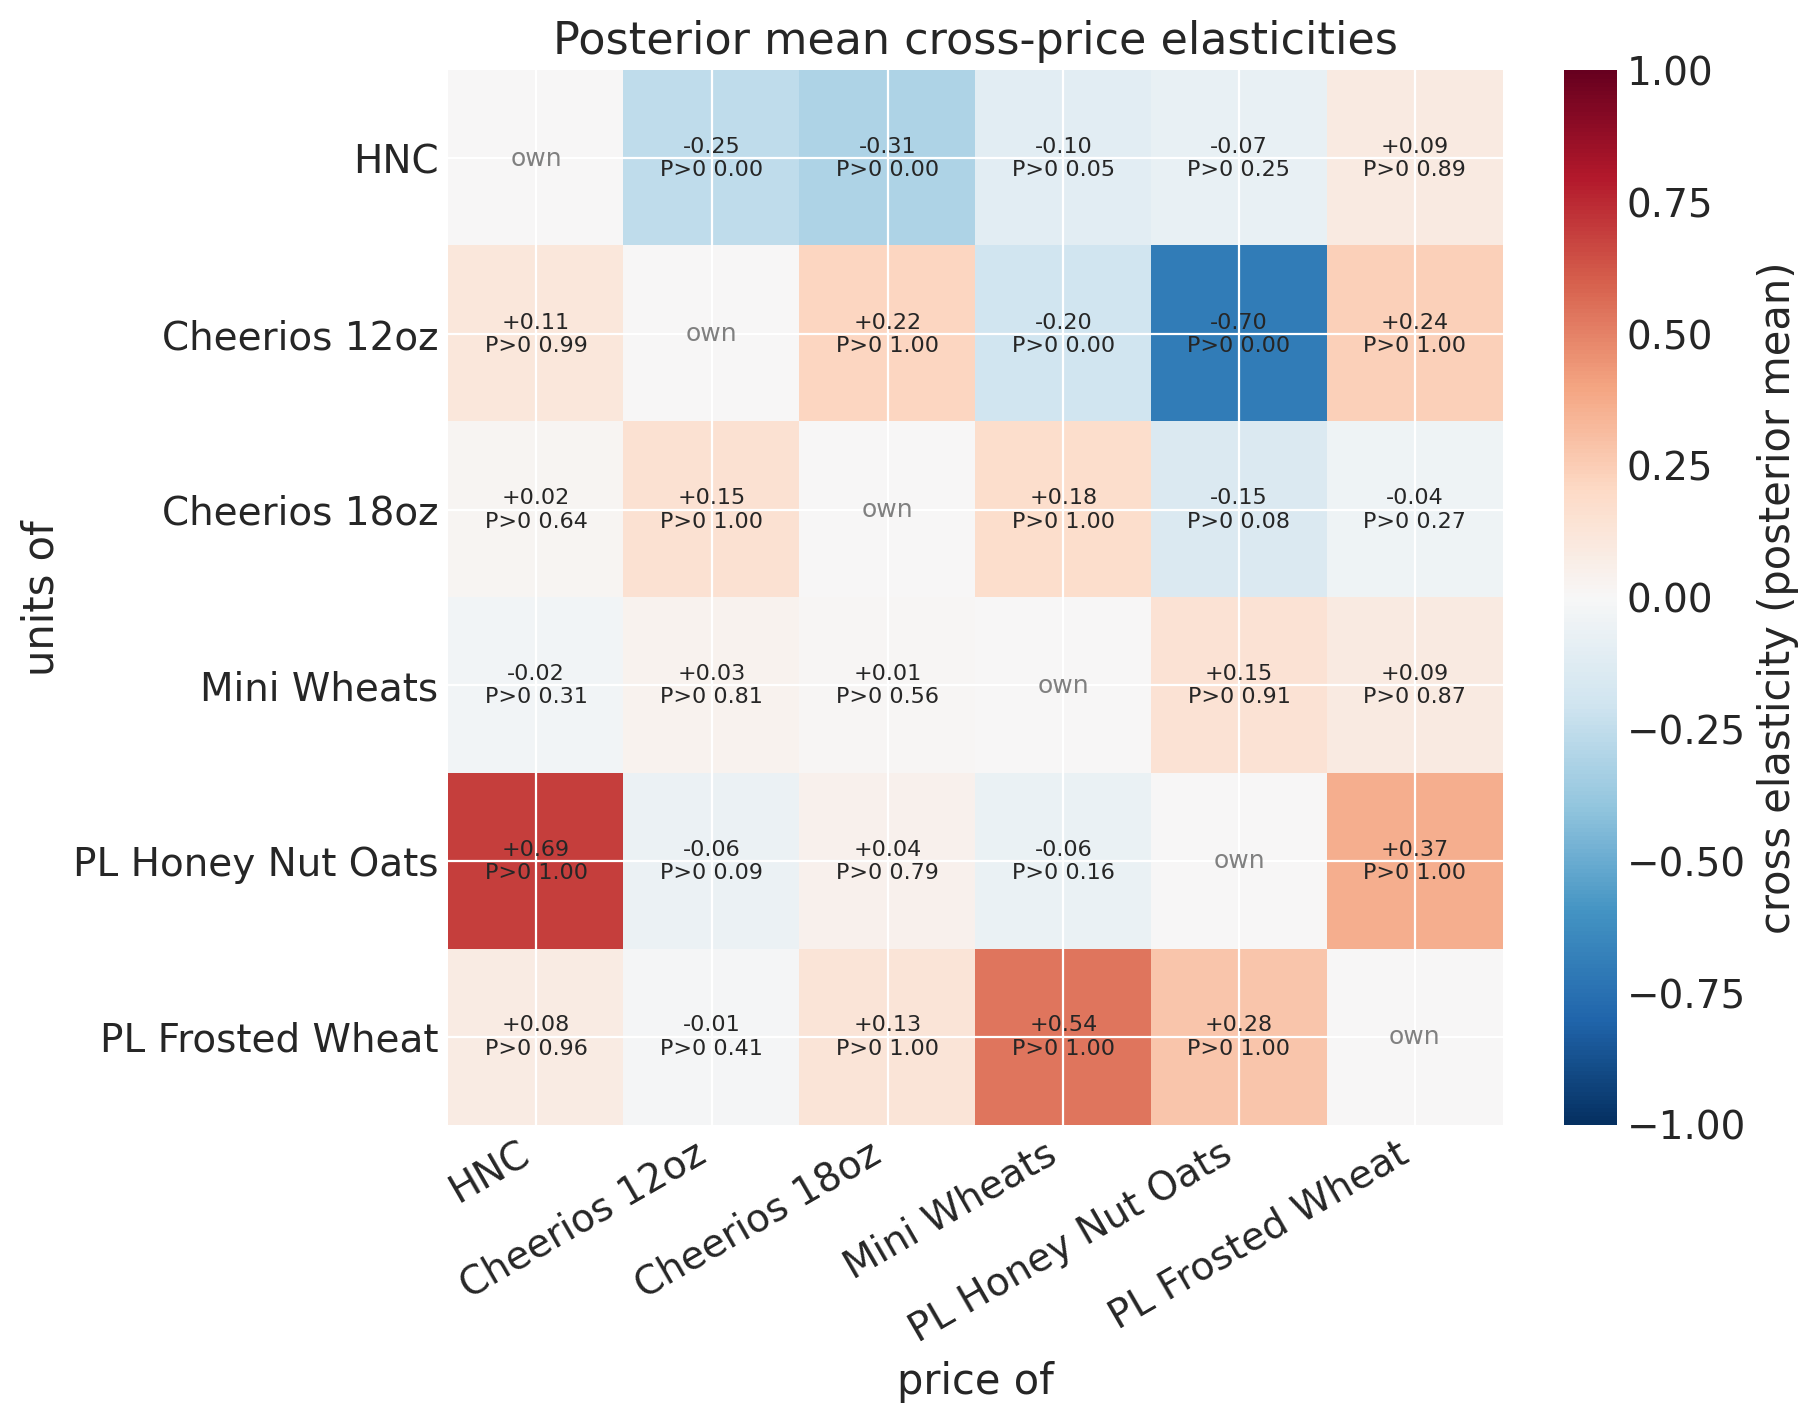

In [41]:
gamma_draws = np.asarray(posterior["gamma"])  # (sample, competitor, product)
gamma_mean = gamma_draws.mean(axis=0)
gamma_positive = (gamma_draws > 0).mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
image = ax.imshow(gamma_mean.T, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
for p in range(n_products):
    for k in range(n_products):
        if k == p:
            ax.text(k, p, "own", ha="center", va="center", fontsize=9, color="gray")
        else:
            ax.text(
                k,
                p,
                f"{gamma_mean[k, p]:+.2f}\nP>0 {gamma_positive[k, p]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )
ax.set_xticks(range(n_products), product_order, rotation=30, ha="right")
ax.set_yticks(range(n_products), product_order)
ax.set(xlabel="price of", ylabel="units of", title="Posterior mean cross-price elasticities")
fig.colorbar(image, ax=ax, label="cross elasticity (posterior mean)");

In [42]:
twin_index = product_order.index("PL Honey Nut Oats")
twin_cell = gamma_draws[:, FOCAL_INDEX, twin_index]
reverse_cell = gamma_draws[:, twin_index, FOCAL_INDEX]
for name, draws_cell in [
    ("HNC price on PL Honey Nut Oats units", twin_cell),
    ("PL Honey Nut Oats price on HNC units", reverse_cell),
]:
    lower_c, upper_c = hdi_bounds(draws_cell, 0.94)
    print(
        f"{name}: median {np.median(draws_cell):+.2f}, 94% HDI {lower_c:+.2f} "
        f"to {upper_c:+.2f}, P(> 0) {np.mean(draws_cell > 0):.2f}"
    )

HNC price on PL Honey Nut Oats units: median +0.69, 94% HDI +0.59 to +0.79, P(> 0) 1.00
PL Honey Nut Oats price on HNC units: median -0.08, 94% HDI -0.28 to +0.13, P(> 0) 0.25


spread across stores: least squares sd 0.37 | posterior medians sd 0.31


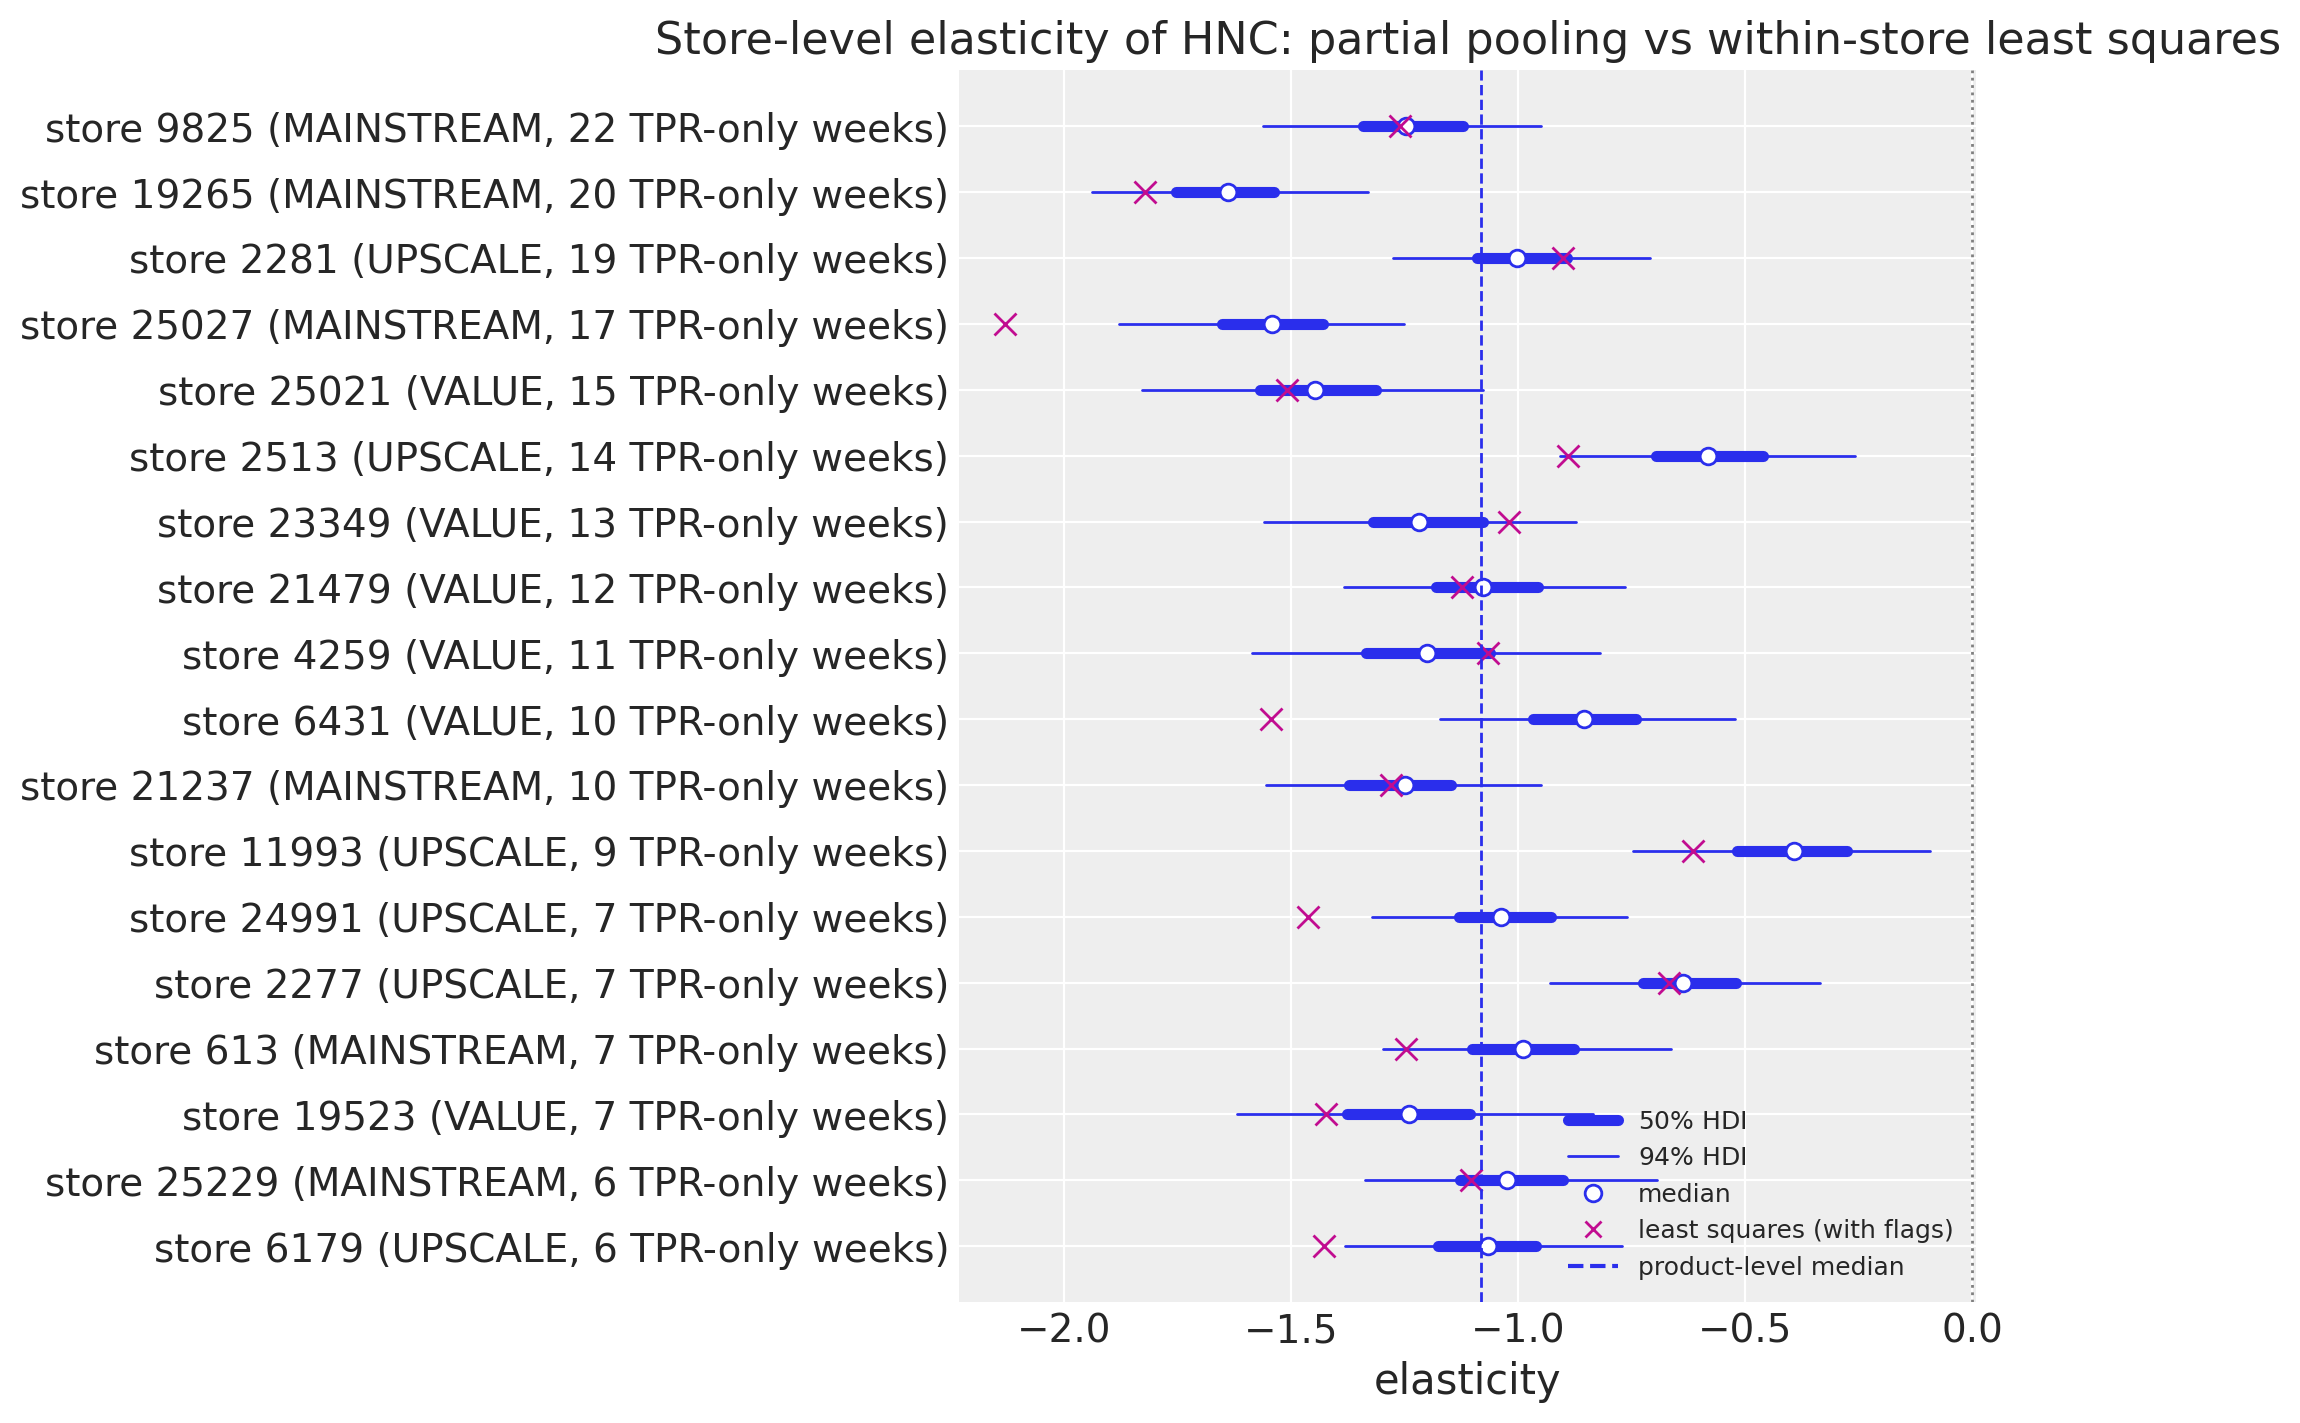

In [43]:
hnc_series_index = [n for n in range(n_series) if series_ids[n].endswith(f"::{FOCAL}")]
hnc_store_ids = [int(series_ids[n].split("::")[0]) for n in hnc_series_index]
eps_store_draws = np.asarray(posterior["eps"])[:, hnc_series_index]
store_ols = np.array(
    [
        float(
            within_ols(
                hnc_long.filter(pl.col("series") == f"{store}::{FOCAL}"),
                ["x", *mechanics_terms, *seasonal_terms],
            )["coef"][0]
        )
        for store in hnc_store_ids
    ]
)
store_tpr_weeks = np.array(
    [
        int(train_panel_df.filter(pl.col("series") == f"{store}::{FOCAL}")["TPR_ONLY"].sum())
        for store in hnc_store_ids
    ]
)
store_order = np.argsort(-store_tpr_weeks)
fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
plot_intervals(
    ax,
    [
        f"store {hnc_store_ids[j]} ({store_segment[hnc_store_ids[j]]}, {store_tpr_weeks[j]} TPR-only weeks)"
        for j in store_order
    ],
    eps_store_draws[:, store_order],
    reference=store_ols[store_order],
)
ax.axvline(
    float(np.median(eps_prod_draws[:, FOCAL_INDEX])),
    color="C0",
    linestyle="--",
    linewidth=1,
    label="product median",
)
ax.legend(
    handles=[
        *interval_handles,
        mlines.Line2D([], [], color="C0", linestyle="--", label="product-level median"),
    ],
    loc="lower right",
    fontsize=9,
)
ax.set(
    title=f"Store-level elasticity of {FOCAL}: partial pooling vs within-store least squares",
    xlabel="elasticity",
)
print(
    f"spread across stores: least squares sd {store_ols.std():.2f} | posterior medians sd "
    f"{np.median(eps_store_draws, axis=0).std():.2f}"
)

In [44]:
beta_mean = np.asarray(posterior["beta_s"]).mean(axis=0)
seasonal_mean = np.asarray(fourier_full) @ beta_mean
hnc_seasonal_horizon = seasonal_mean[t_train:, FOCAL_INDEX]
peak_week = int(np.argmax(hnc_seasonal_horizon)) + 1
print(
    f"posterior-mean seasonal component of {FOCAL} peaks in horizon week {peak_week} ({holdout_weeks[peak_week - 1]})"
)
print(
    f"drift scale posterior medians across series: {np.median(np.asarray(posterior['drift_scale']), axis=0).min():.3f} "
    f"to {np.median(np.asarray(posterior['drift_scale']), axis=0).max():.3f}"
)

posterior-mean seasonal component of HNC peaks in horizon week 12 (2011-12-28)
drift scale posterior medians across series: 0.019 to 0.218


## In-sample fit and holdout forecast

We draw the in-sample posterior predictive and the holdout forecast with the realized covariates and score them with the continuous ranked probability score (CRPS), the mean absolute error, and the coverage of the central $50\%$ and $94\%$ intervals (central intervals, while the figures draw HDI bands). The seasonal naive comparator is the two-member ensemble of the units 52 and 104 weeks earlier, and the MASE scale is computed per product on its training block, because a pooled scale would be dominated by the high-volume products. Calibration is read the way [Gneiting and Katzfuss (2014)](https://doi.org/10.1146/annurev-statistics-062713-085831) frame it, sharpness subject to calibration, with the randomized probability integral transform (PIT) for counts of [Czado, Gneiting and Held (2009)](https://doi.org/10.1111/j.1541-0420.2009.01191.x): for a count $y$ with predictive CDF $G$, $u = G(y - 1) + v\,(G(y) - G(y - 1))$ with $v \sim \text{Uniform}(0, 1)$ is uniform for a calibrated forecast, U-shaped for an under-dispersed one and hump-shaped for an over-dispersed one. Two cautions: the holdout is the holiday quarter, with only two earlier Decembers in the training window; and the holdout cells of one series share a level path, so the effective sample size behind the histogram is well below the number of cells.

The holdout CRPS is $12.98$ against $22.13$ for the seasonal naive ensemble and the mean absolute error $17.65$ against $26.57$; the central $50\%$ and $94\%$ intervals cover $56\%$ and $92\%$ of the $1{,}404$ holdout cells (in sample, $62\%$ and $96\%$). Per product the model's MASE is below the naive one and below one everywhere, with the focal product the hardest at $0.95$ against $1.56$ and a $94\%$ coverage of $0.84$ in its promotion-heavy quarter. The model beats the naive forecast in every horizon week except week 12, the week of the deepest realized cut. The PIT histogram slopes downward, with $16\%$ of the cells in the lowest decile and $4\%$ in the highest: the holdout forecasts run high on average, so the calibration is good but not perfect, and the effective sample size behind the histogram is far below $1{,}404$.

In [45]:
rng_key, key_in, key_fc = random.split(rng_key, 3)
pred_train = np.asarray(
    predict_in_sample(key_in, nuts_model, posterior, covariates_train, device="host"),
    dtype=np.float32,
)
pred_test = np.asarray(
    forecast(key_fc, nuts_model, posterior, y_train, covariates, device="host"), dtype=np.float32
)
y_np = np.asarray(y, dtype=np.float32)
naive_test = np.stack(
    [y_np[t_train - 52 : t_train - 52 + HORIZON], y_np[t_train - 104 : t_train - 104 + HORIZON]]
)
print(
    f"in-sample draws {pred_train.shape} | holdout draws {pred_test.shape} | holdout cells {y_test_f.size:,}"
)


def score(
    pred: Float[np.ndarray, " sample time n_series"], truth: Float[np.ndarray, " time n_series"]
) -> dict[str, float]:
    """CRPS, MAE and central-interval coverage of an ensemble against the truth."""
    return {
        "crps": float(eval_crps(pred, truth)),
        "mae": float(eval_mae(pred, truth)),
        "coverage_50": float(eval_coverage(pred, truth, alpha=0.5)),
        "coverage_94": float(eval_coverage(pred, truth, alpha=0.94)),
    }


metrics_table = pl.DataFrame(
    [
        {"forecast": "model (train)", **score(pred_train, y_train_f)},
        {"forecast": "model (test)", **score(pred_test, y_test_f)},
        {"forecast": "seasonal naive (test)", **score(naive_test, y_test_f)},
    ]
)
metrics_table

in-sample draws (4000, 143, 108) | holdout draws (4000, 13, 108) | holdout cells 1,404


forecast,crps,mae,coverage_50,coverage_94
"""model (train)""",7.917095,10.87364,0.62432,0.959596
"""model (test)""",12.975068,17.647436,0.561254,0.919516
"""seasonal naive (test)""",22.127493,26.566952,0.151709,0.29416


In [46]:
product_rows = []
for k, product in enumerate(product_order):
    idx = np.where(series_to_product_np == k)[0]
    mase = make_mase(y_train_f[:, idx], seasonality=52)
    product_rows.append(
        {
            "product": product,
            "crps_model": float(eval_crps(pred_test[:, :, idx], y_test_f[:, idx])),
            "crps_naive": float(eval_crps(naive_test[:, :, idx], y_test_f[:, idx])),
            "mase_model": float(
                mase(jnp.asarray(pred_test[:, :, idx]), jnp.asarray(y_test_f[:, idx]))
            ),
            "mase_naive": float(
                mase(jnp.asarray(naive_test[:, :, idx]), jnp.asarray(y_test_f[:, idx]))
            ),
            "coverage_94": float(
                eval_coverage(pred_test[:, :, idx], y_test_f[:, idx], alpha=0.94)
            ),
        }
    )
per_product_table = pl.DataFrame(product_rows)
per_product_table

product,crps_model,crps_naive,mase_model,mase_naive,coverage_94
"""HNC""",37.492382,69.972229,0.952045,1.555362,0.837607
"""Cheerios 12oz""",11.245326,21.534189,0.550353,0.976913,0.965812
"""Cheerios 18oz""",4.746489,6.376069,0.255705,0.293871,0.965812
"""Mini Wheats""",6.565374,10.685898,0.412274,0.560507,0.978633
"""PL Honey Nut Oats""",7.784356,10.254274,0.809331,0.926579,0.893162
"""PL Frosted Wheat""",10.016487,13.942308,0.647122,0.811573,0.876068


PIT bin shares: [0.159 0.108 0.122 0.107 0.11  0.115 0.099 0.084 0.061 0.036]


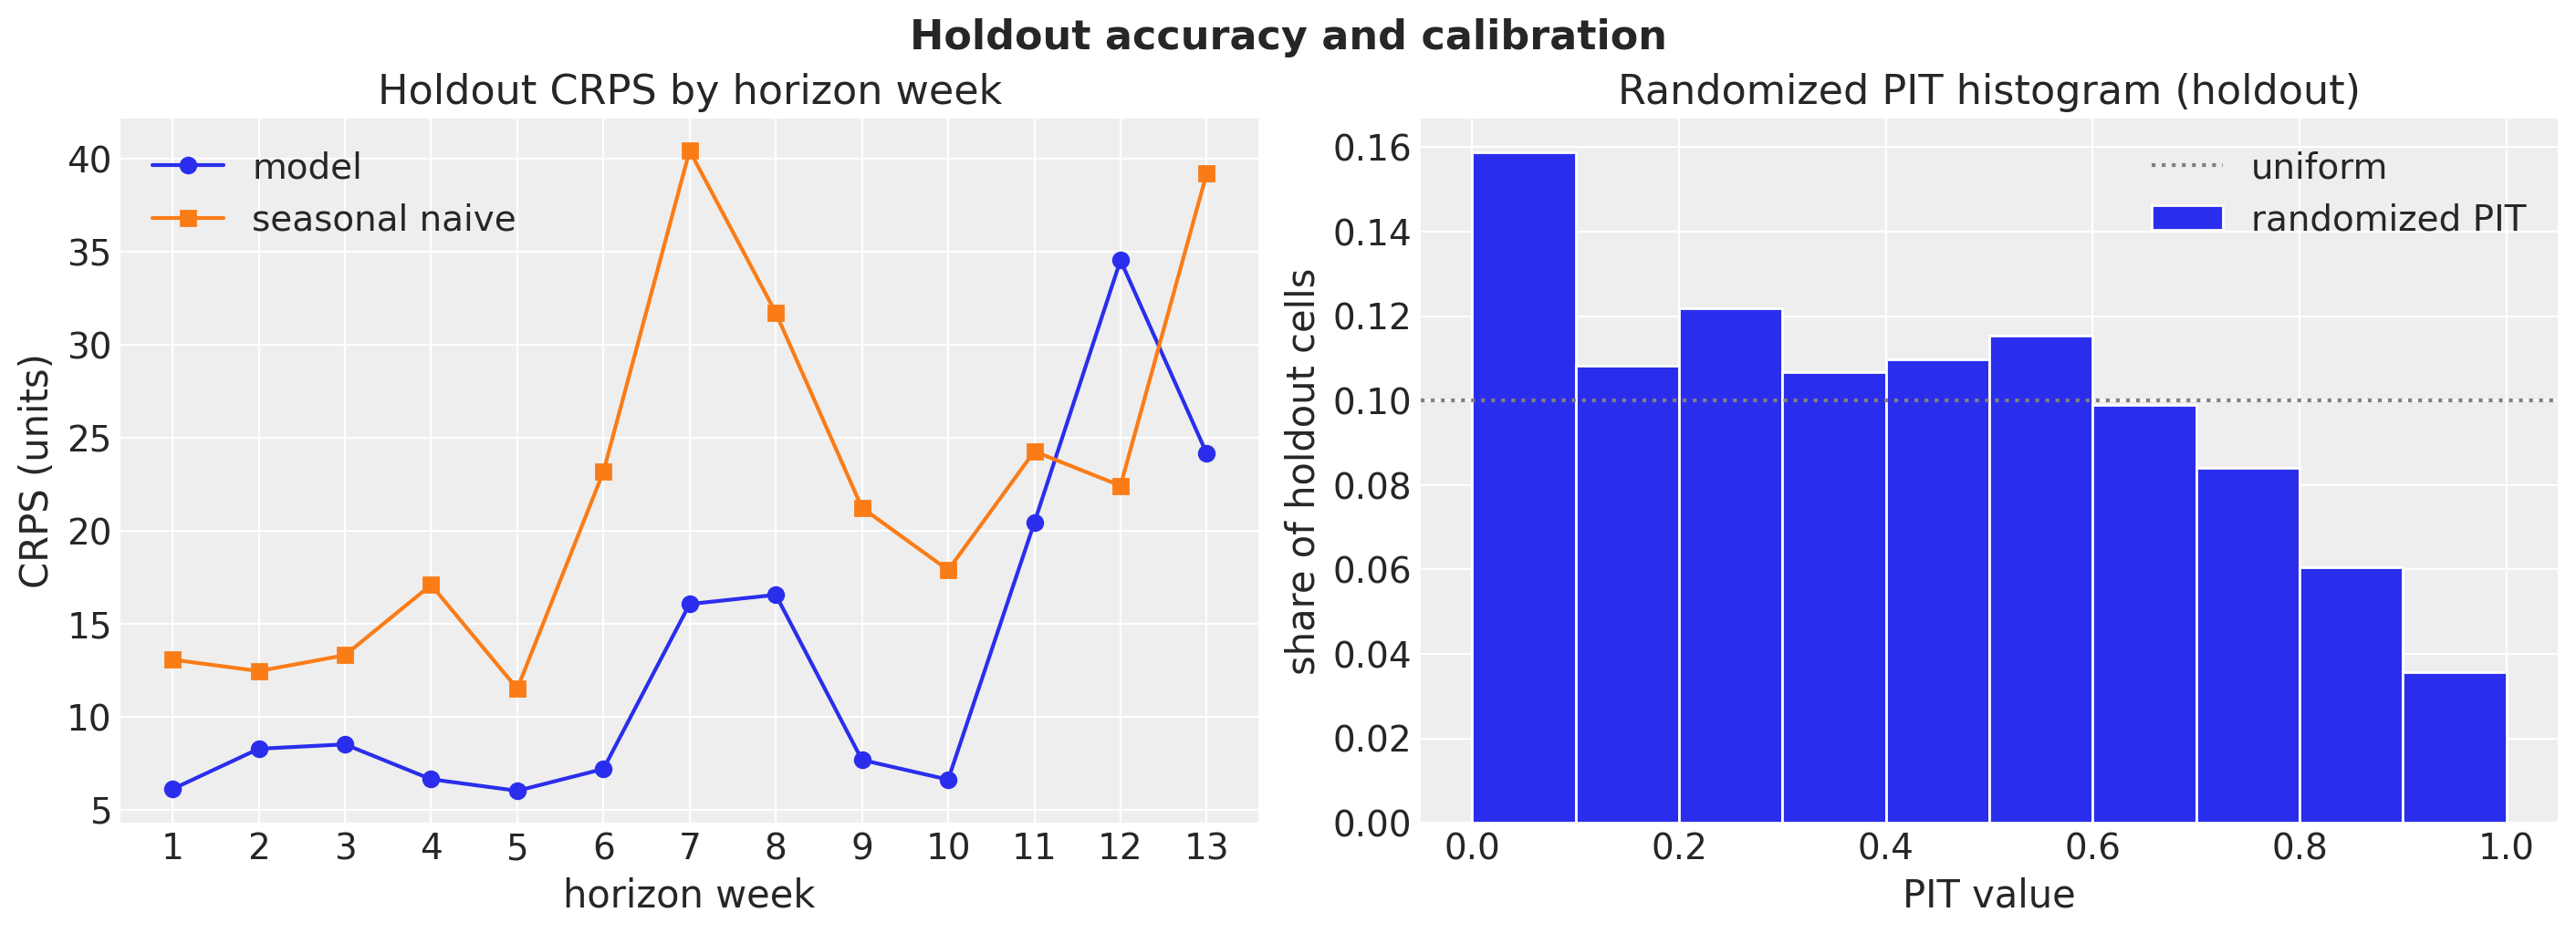

In [47]:
crps_week_model = np.array(
    [float(crps_empirical(pred_test[:, t, :], y_test_f[t, :]).mean()) for t in range(HORIZON)]
)
crps_week_naive = np.array(
    [float(crps_empirical(naive_test[:, t, :], y_test_f[t, :]).mean()) for t in range(HORIZON)]
)
cdf_at = (pred_test <= y_test_f[None]).mean(axis=0)
cdf_below = (pred_test <= y_test_f[None] - 1.0).mean(axis=0)
pit_rng = np.random.default_rng(seed=42)
pit = cdf_below + pit_rng.uniform(size=y_test_f.shape) * (cdf_at - cdf_below)
pit_counts, _ = np.histogram(pit, bins=10, range=(0.0, 1.0))
print(f"PIT bin shares: {np.round(pit_counts / pit_counts.sum(), 3)}")

fig, axes = plt.subplots(ncols=2, figsize=(14, 5), layout="constrained")
axes[0].plot(range(1, HORIZON + 1), crps_week_model, "o-", color="C0", label="model")
axes[0].plot(range(1, HORIZON + 1), crps_week_naive, "s-", color="C1", label="seasonal naive")
axes[0].legend(loc="upper left")
axes[0].set(
    xlabel="horizon week",
    ylabel="CRPS (units)",
    title="Holdout CRPS by horizon week",
    xticks=range(1, HORIZON + 1),
)
axes[1].bar(
    np.arange(0.05, 1.0, 0.1),
    pit_counts / pit_counts.sum(),
    width=0.1,
    color="C0",
    edgecolor="white",
    label="randomized PIT",
)
axes[1].axhline(0.1, color="gray", linestyle=":", label="uniform")
axes[1].legend(loc="upper right")
axes[1].set(
    xlabel="PIT value", ylabel="share of holdout cells", title="Randomized PIT histogram (holdout)"
)
fig.suptitle("Holdout accuracy and calibration", fontsize=16, fontweight="bold");

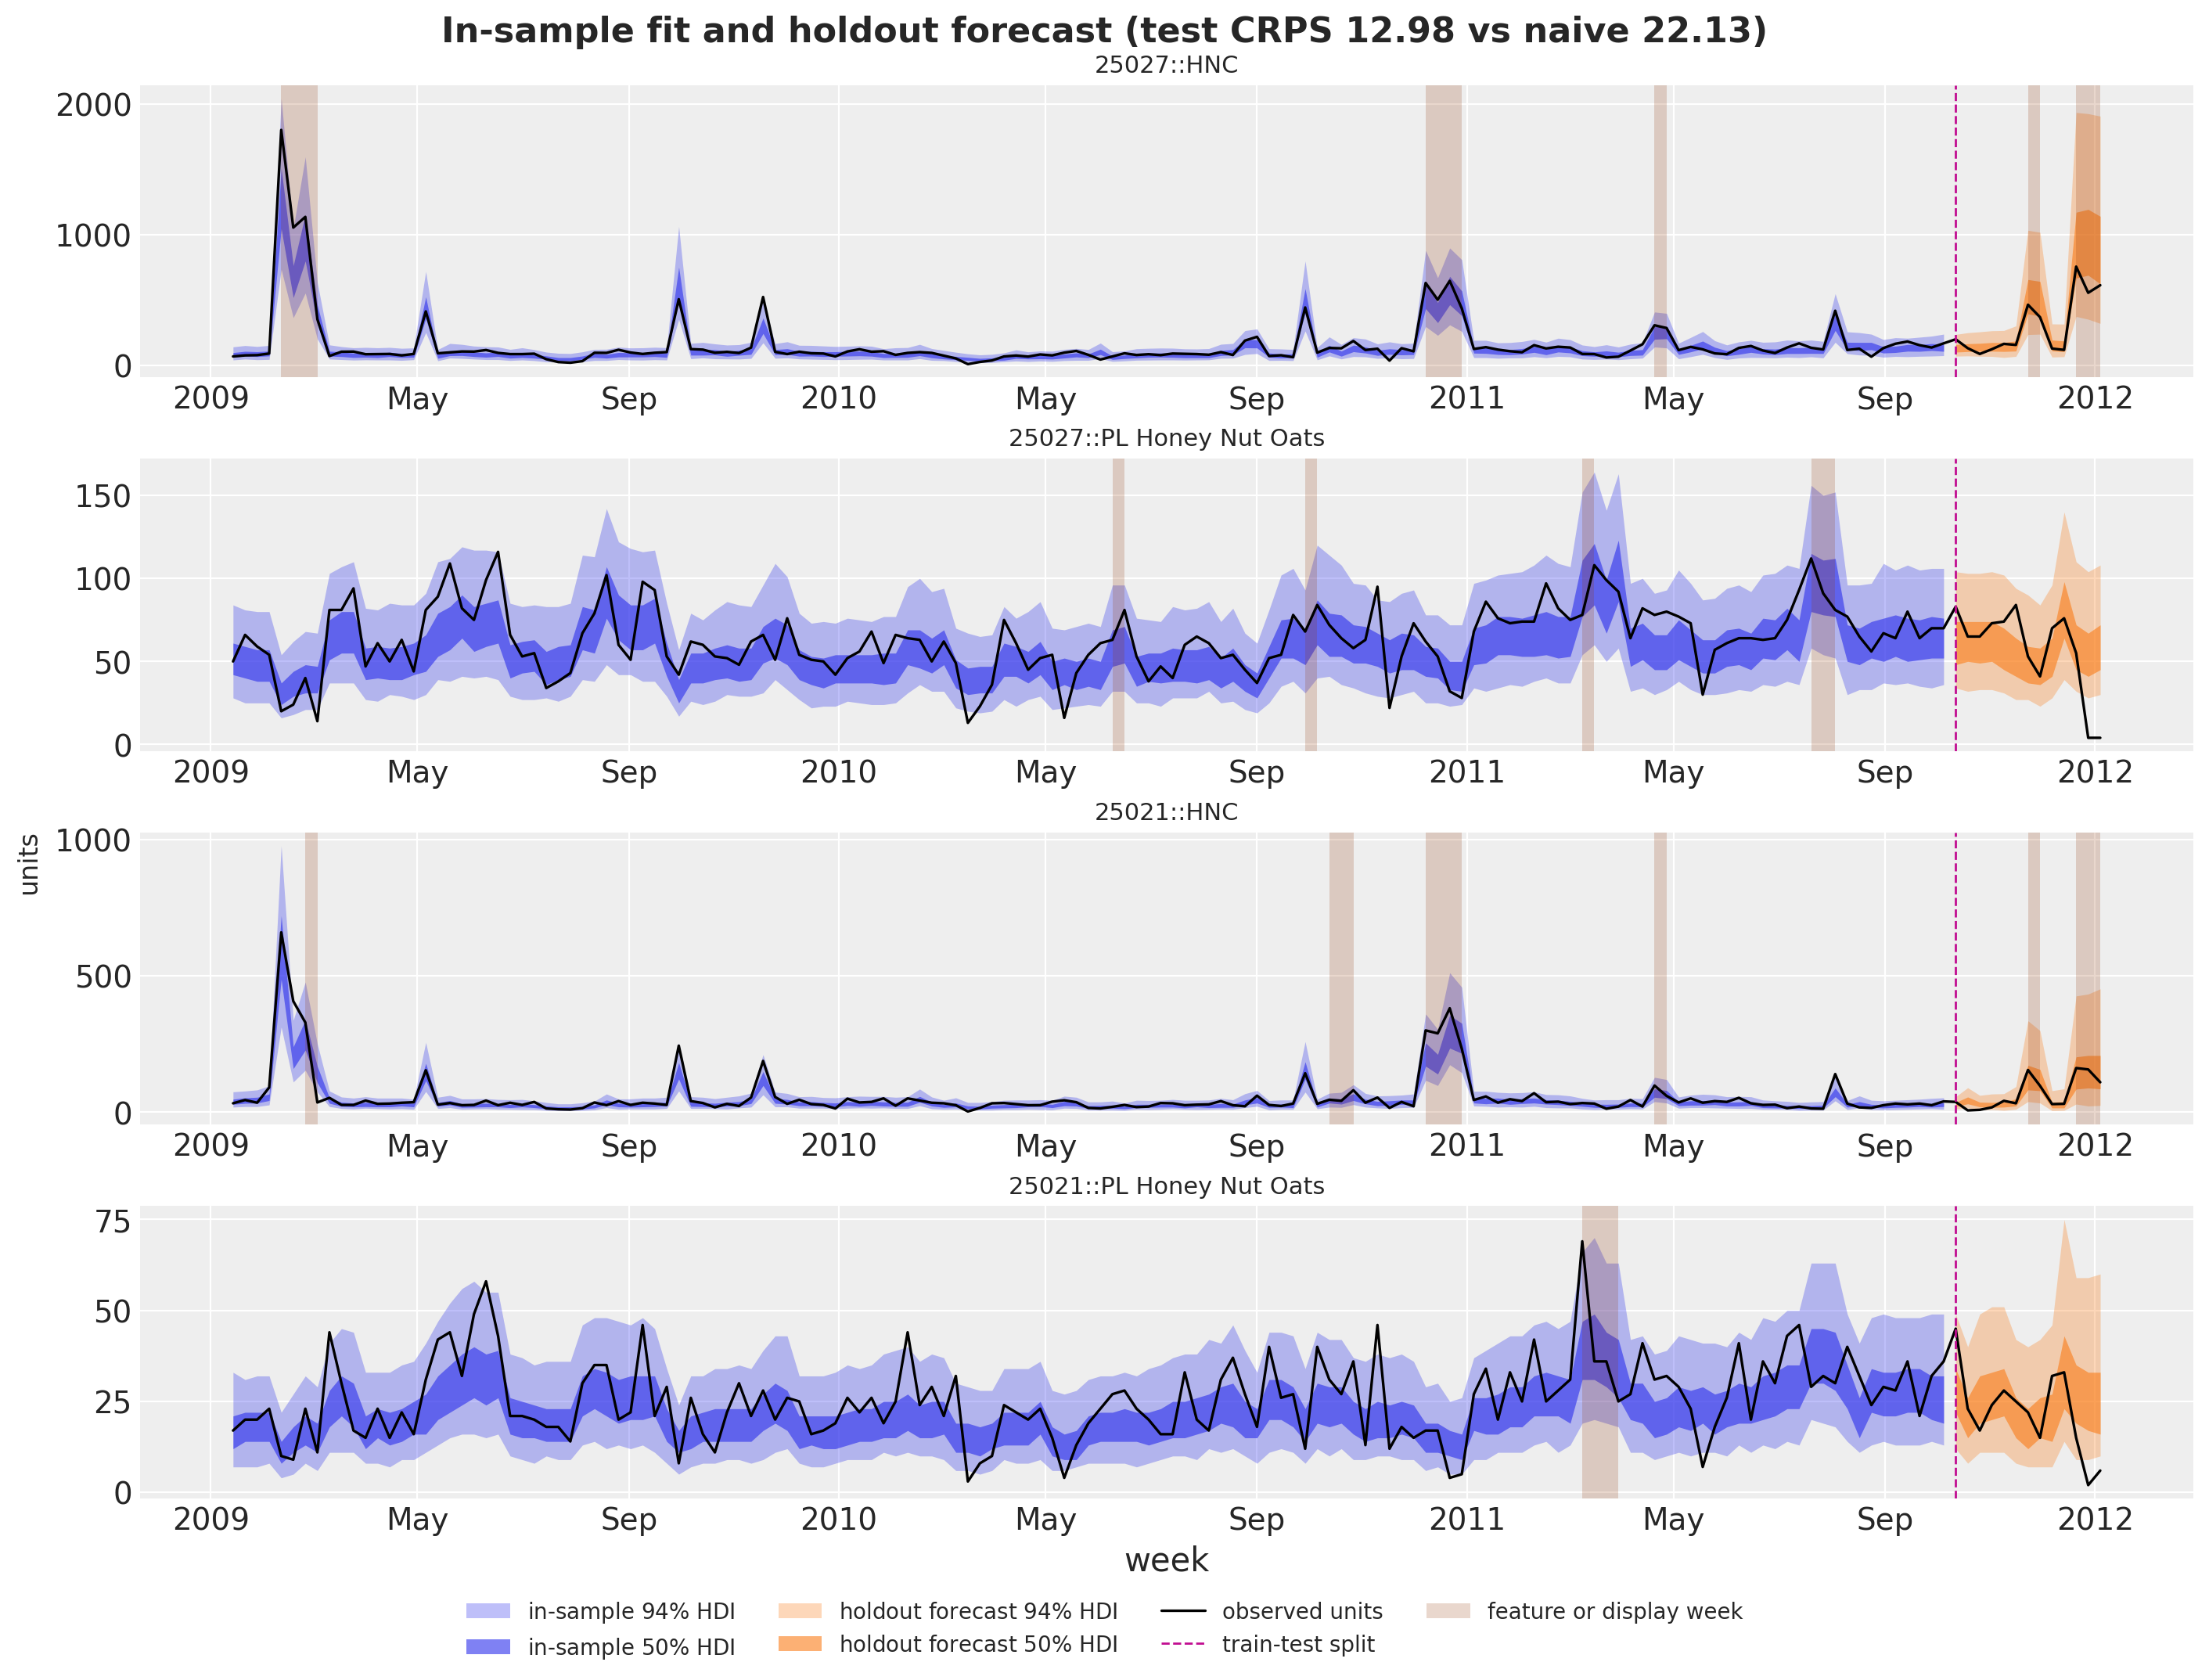

In [48]:
def plot_forecast_panel(
    pred_test_draws: Float[np.ndarray, " sample horizon n_series"],
    labels: list[str],
    forecast_color: str,
    forecast_label: str,
    suptitle: str,
) -> None:
    """Facet the in-sample predictive and the holdout forecast for the series in ``labels``."""
    idx = [series_ids.index(label) for label in labels]
    pc = az.plot_lm(
        predictions_to_datatree(pred_train[:, :, idx], dates_num[:t_train], labels),
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        col_wrap=1,
        visuals={
            "ci_band": {"color": "C0"},
            "observed_scatter": False,
            "pe_line": False,
            "xlabel": False,
            "ylabel": False,
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": (14, 2.6 * len(labels))},
    )
    train_bands = pc.viz["ci_band"]["t"].sel(series=labels[-1])
    az.plot_lm(
        predictions_to_datatree(pred_test_draws[:, :, idx], dates_num[t_train:], labels),
        y="obs",
        x="t",
        plot_dim="time",
        plot_collection=pc,
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        visuals={
            "ci_band": {"color": forecast_color},
            "observed_scatter": False,
            "pe_line": False,
            "xlabel": False,
            "ylabel": False,
        },
    )
    truth_da = panel_ds["units"].sel(series=labels).assign_coords(time=dates_num).rename("t")
    x_da = xr.DataArray(dates_num, dims=["time"], coords={"time": dates_num})
    pc.map(
        az.visuals.line_xy,
        "truth",
        data=truth_da,
        x=x_da,
        ignore_aes=pc.aes_set,
        color="black",
        lw=1.2,
    )
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=11)
        split_line = ax.axvline(split_x, color="C3", linestyle="--", linewidth=1)
        promo_span = ax.fill_between(
            dates_num,
            0,
            1,
            where=(
                (panel_ds["feature"].sel(series=label) + panel_ds["display"].sel(series=label))
                > 0.5
            )
            .to_numpy()
            .tolist(),
            transform=ax.get_xaxis_transform(),
            color="C4",
            alpha=0.2,
            linewidth=0,
            step="mid",
        )
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    test_bands = pc.viz["ci_band"]["t"].sel(series=labels[-1])
    band_handles = []
    for bands, prefix in ((train_bands, "in-sample "), (test_bands, f"{forecast_label} ")):
        for prob in (0.94, 0.5):
            band = bands.sel(prob=prob).item()
            band.set_label(hdi_label(prob, prefix=prefix))
            band_handles.append(band)
    truth_line = pc.viz["truth"]["t"].sel(series=labels[-1]).item()
    truth_line.set_label("observed units")
    split_line.set_label("train-test split")
    promo_span.set_label("feature or display week")
    fig = pc.viz["figure"].item()
    fig.legend(
        handles=[*band_handles, truth_line, split_line, promo_span],
        loc="outside lower center",
        ncols=4,
        fontsize=10,
    )
    pc.get_target("t", {"series": labels[-1]}).set_xlabel("week")
    fig.supylabel("units")
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)


plot_labels = [
    f"{store}::{product}"
    for store in (focus_stores[0], focus_stores[2])
    for product in (FOCAL, "PL Honey Nut Oats")
]
plot_forecast_panel(
    pred_test,
    plot_labels,
    forecast_color="C1",
    forecast_label="holdout forecast",
    suptitle=f"In-sample fit and holdout forecast (test CRPS "
    f"{metrics_table['crps'][1]:.2f} vs naive {metrics_table['crps'][2]:.2f})",
)

## Counterfactual promotions

A counterfactual promotion is a change of the horizon covariates, nothing else: the posterior draws stay fixed, the same PRNG key is reused, and the model is run again through NumPyro's `Predictive`. Nothing is refit. The library's `forecast` returns the sampled units; the decision layer also needs the conditional mean $\mu$ over the horizon and the future level innovations, so we wrap `Predictive` ourselves with the model as a static argument, the same pattern the library uses, and ask for three sites. The first thing to do with the wrapper is to check that it reproduces the `forecast` draws of the previous section bit for bit under the same key: that validates the engine and the key discipline, not any causal claim.

A policy is a discount depth $d$ and a mechanics $m$ for the focal product in every panel store during one contiguous two-week event, horizon weeks 7 and 8, the realized Thanksgiving slot. Every other product sits at its base price with no promotion over the whole horizon, and the grid below is a response surface for the break-even and risk analyses, not a search space. The calendar is not a lever here for two reasons printed earlier: the post-promotion dip is economically negligible, and under a multiplicative model the timing question reduces to the seasonal peak, whose posterior-mean week was printed above. The grid runs from no cut to a $40\%$ cut in steps of five points for each of the four mechanics; for the shelf-tag-only mechanics the zero-depth cell is the no-promotion baseline itself. Cells with fewer than 20 observed store-weeks within $\pm 2.5$ points of the depth are shaded in the figures as thin support. Under one key the future level innovations are bit-identical across policies and the conditional means agree wherever the covariates agree, while the sampled units are coupled but not identical (common random numbers), which the cells below print.

The engine check prints a maximum absolute difference of $0.0$ between the wrapper's draws and the `forecast` draws under the same key. Across two policies the future level innovations differ by $0.0$, the conditional means differ by $0.0$ outside the event weeks, and the focal product's event draws have a correlation of $0.99$. The 36 policies take under 30 seconds on $4{,}000$ draws each. The figures show the feature-with-display event lifting the focal product's zone-level units to more than three times the no-promotion level in the event weeks, and lowering the private-label twin's units in the same weeks.

In [49]:
def _scenario_draws(
    rng_key: Array,
    model: ForecastModel,
    posterior: dict[str, Array],
    data: Array,
    covariates: Array,
) -> dict[str, Array]:
    """Return the sampled horizon units, conditional means and future innovations of one covariate tensor."""
    predictive = Predictive(
        model,
        posterior_samples=posterior,
        return_sites=["forecast", "mu_future", "drift_future"],
        parallel=True,
    )
    return predictive(rng_key, covariates, data)


scenario_draws = jax.jit(_scenario_draws, static_argnums=(1,))

engine = scenario_draws(key_fc, nuts_model, posterior, y_train, covariates)
engine_gap = float(np.abs(np.asarray(engine["forecast"], dtype=np.float32) - pred_test).max())
print(
    f"engine check: max |scenario draws - forecast() draws| under the same key = {engine_gap:.1f}"
)

engine check: max |scenario draws - forecast() draws| under the same key = 0.0


In [50]:
EVENT_OFFSETS = [6, 7]  # horizon weeks 7 and 8, one-based
event_rows = [t_train + offset for offset in EVENT_OFFSETS]
BASELINE = ("TPR-only", 0.0)


def policy_covariates(depth: float, feature_flag: float, display_flag: float) -> Array:
    """Horizon covariates of one policy: base prices and no promotion everywhere except the event.

    During the event weeks the focal product carries the cut and the mechanics, every series of
    the same store sees the focal product's price in its cross-price block, and the siblings carry
    the sibling flags. The training rows are left untouched.
    """
    tensor = np.asarray(covariates).copy()
    tensor[:, t_train:, :] = 0.0
    x_policy = float(np.log1p(-depth))
    for n in range(n_series):
        if int(series_to_product_np[n]) == FOCAL_INDEX:
            tensor[0, event_rows, n] = x_policy
            tensor[1, event_rows, n] = feature_flag
            tensor[2, event_rows, n] = display_flag
        else:
            tensor[3, event_rows, n] = feature_flag
            tensor[4, event_rows, n] = display_flag
        tensor[PRICE_BLOCK + FOCAL_INDEX, event_rows, n] = x_policy
    return jnp.asarray(tensor, dtype=jnp.float32)


policy_a = policy_covariates(0.15, *MECHANICS["feature + display"])
policy_b = policy_covariates(0.30, *MECHANICS["TPR-only"])
assert np.array_equal(np.asarray(policy_a)[:, :t_train], np.asarray(covariates)[:, :t_train])
first_store_series = list(range(n_products))
print(
    "event row of a feature + display policy at 15% off, first store (rows: inputs, columns: products):"
)
print(
    pl.DataFrame(
        {
            "input": input_names,
            **{
                product_order[j]: np.asarray(policy_a)[:, event_rows[0], j]
                for j in first_store_series
            },
        }
    )
)

event row of a feature + display policy at 15% off, first store (rows: inputs, columns: products):
┌──────────────┬───────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ input        ┆ HNC       ┆ Cheerios     ┆ Cheerios     ┆ Mini Wheats ┆ PL Honey    ┆ PL Frosted  │
│              ┆           ┆ 12oz         ┆ 18oz         ┆             ┆ Nut Oats    ┆ Wheat       │
╞══════════════╪═══════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ x            ┆ -0.162519 ┆ 0.0          ┆ 0.0          ┆ 0.0         ┆ 0.0         ┆ 0.0         │
│ feature      ┆ 1.0       ┆ 0.0          ┆ 0.0          ┆ 0.0         ┆ 0.0         ┆ 0.0         │
│ display      ┆ 1.0       ┆ 0.0          ┆ 0.0          ┆ 0.0         ┆ 0.0         ┆ 0.0         │
│ sib_feature  ┆ 0.0       ┆ 1.0          ┆ 1.0          ┆ 1.0         ┆ 1.0         ┆ 1.0         │
│ sib_display  ┆ 0.0       ┆ 1.0          ┆ 1.0          ┆ 1.0         ┆ 1.0         ┆ 1.0   

In [51]:
rng_key, key_policy = random.split(rng_key)
out_a = scenario_draws(key_policy, nuts_model, posterior, y_train, policy_a)
out_b = scenario_draws(key_policy, nuts_model, posterior, y_train, policy_b)
non_event = [offset for offset in range(HORIZON) if offset not in EVENT_OFFSETS]
print(
    f"max |drift_future difference| across the two policies: "
    f"{float(np.abs(out_a['drift_future'] - out_b['drift_future']).max()):.2e}"
)
print(
    f"max |mu_future difference| outside the event weeks: "
    f"{float(np.abs(out_a['mu_future'][:, non_event] - out_b['mu_future'][:, non_event]).max()):.2e}"
)
event_a = np.asarray(out_a["forecast"])[:, EVENT_OFFSETS][:, :, hnc_series_index].ravel()
event_b = np.asarray(out_b["forecast"])[:, EVENT_OFFSETS][:, :, hnc_series_index].ravel()
print(
    f"correlation of the focal product's event draws across the two policies: {np.corrcoef(event_a, event_b)[0, 1]:.2f}"
)

max |drift_future difference| across the two policies: 0.00e+00
max |mu_future difference| outside the event weeks: 0.00e+00
correlation of the focal product's event draws across the two policies: 0.99


In [52]:
%%time

policies: list[tuple[str, float]] = [
    (mechanics_name, float(depth)) for mechanics_name in MECHANICS for depth in DEPTH_GRID
]
event_units_mu: dict[tuple[str, float], np.ndarray] = {}
event_units_paths: dict[tuple[str, float], np.ndarray] = {}
hnc_event_paths: dict[tuple[str, float], np.ndarray] = {}
hnc_event_mu: dict[tuple[str, float], np.ndarray] = {}
zone_paths: dict[tuple[str, float], np.ndarray] = {}
for policy in policies:
    mechanics_name, depth = policy
    out = scenario_draws(
        key_policy,
        nuts_model,
        posterior,
        y_train,
        policy_covariates(depth, *MECHANICS[mechanics_name]),
    )
    mu_horizon = np.asarray(out["mu_future"], dtype=np.float32)
    y_horizon = np.asarray(out["forecast"], dtype=np.float32)
    event_units_mu[policy] = mu_horizon[:, EVENT_OFFSETS, :].sum(axis=1)
    event_units_paths[policy] = y_horizon[:, EVENT_OFFSETS, :].sum(axis=1)
    hnc_event_paths[policy] = y_horizon[:, EVENT_OFFSETS][:, :, hnc_series_index]
    hnc_event_mu[policy] = mu_horizon[:, EVENT_OFFSETS][:, :, hnc_series_index]
    zone_paths[policy] = np.stack(
        [y_horizon[:, :, series_to_product_np == k].sum(axis=2) for k in range(n_products)],
        axis=-1,
    )
print(f"{len(policies)} policies evaluated on {n_draws} posterior draws each")

36 policies evaluated on 4000 posterior draws each
CPU times: user 4min 40s, sys: 5.78 s, total: 4min 46s
Wall time: 26.9 s


In [53]:
def plot_zone_policies(
    policy_list: list[tuple[str, float]], products: list[str], figsize: tuple[float, float]
) -> None:
    """Zone-level weekly units over the horizon: the baseline vs each policy, one facet per product and policy."""
    labels = [
        f"{product}: {mechanics_name} at {depth:.0%}"
        for product in products
        for (mechanics_name, depth) in policy_list
    ]
    baseline_draws = np.stack(
        [
            zone_paths[BASELINE][:, :, product_order.index(product)]
            for product in products
            for _ in policy_list
        ],
        axis=-1,
    )
    policy_draws = np.stack(
        [
            zone_paths[policy][:, :, product_order.index(product)]
            for product in products
            for policy in policy_list
        ],
        axis=-1,
    )
    horizon_weeks = np.arange(1, HORIZON + 1, dtype=float)
    pc = az.plot_lm(
        predictions_to_datatree(baseline_draws, horizon_weeks, labels),
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        col_wrap=len(policy_list),
        visuals={
            "ci_band": {"color": "C0"},
            "observed_scatter": False,
            "pe_line": False,
            "xlabel": False,
            "ylabel": False,
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    baseline_bands = pc.viz["ci_band"]["t"].sel(series=labels[-1])
    az.plot_lm(
        predictions_to_datatree(policy_draws, horizon_weeks, labels),
        y="obs",
        x="t",
        plot_dim="time",
        plot_collection=pc,
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        visuals={
            "ci_band": {"color": "C1"},
            "observed_scatter": False,
            "pe_line": False,
            "xlabel": False,
            "ylabel": False,
        },
    )
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=10)
        event_span = ax.axvspan(
            EVENT_OFFSETS[0] + 0.5, EVENT_OFFSETS[-1] + 1.5, color="gray", alpha=0.15
        )
        ax.set_xticks(range(1, HORIZON + 1, 2))
    policy_bands = pc.viz["ci_band"]["t"].sel(series=labels[-1])
    handles = []
    for bands, prefix in ((baseline_bands, "no promotion "), (policy_bands, "policy ")):
        for prob in (0.94, 0.5):
            band = bands.sel(prob=prob).item()
            band.set_label(hdi_label(prob, prefix=prefix))
            handles.append(band)
    event_span.set_label("event weeks")
    fig = pc.viz["figure"].item()
    fig.legend(handles=[*handles, event_span], loc="outside lower center", ncols=5, fontsize=10)
    for label in labels[-len(policy_list) :]:
        pc.get_target("t", {"series": label}).set_xlabel("horizon week")
    fig.supylabel(f"units per week, all {n_stores} stores")
    fig.suptitle(
        "Counterfactual promotion vs no promotion (posterior predictive)",
        fontsize=16,
        fontweight="bold",
        y=1.03,
    )

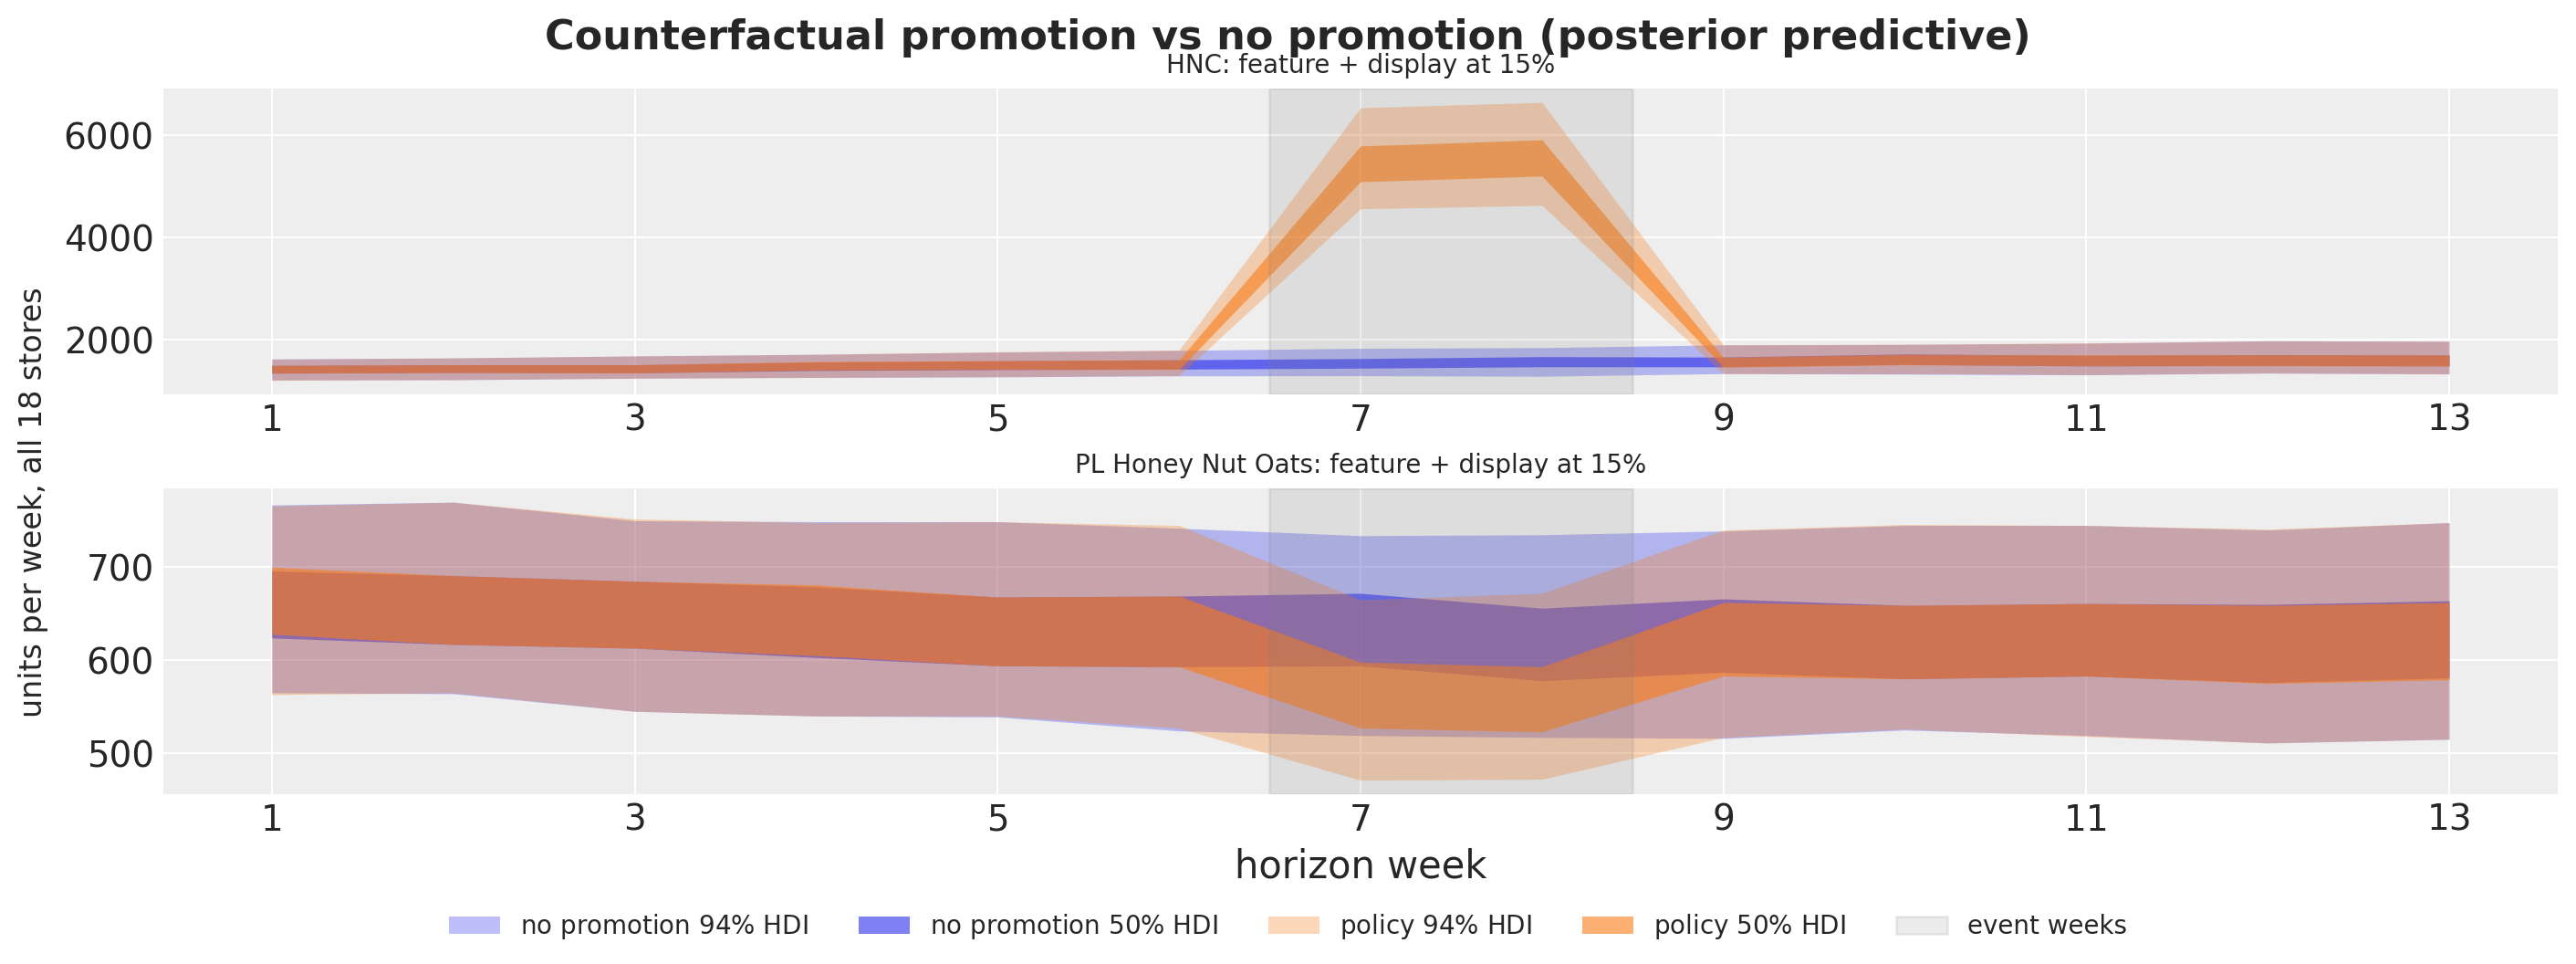

In [54]:
plot_zone_policies(
    [("feature + display", 0.15)], [FOCAL, "PL Honey Nut Oats"], figsize=(14.0, 5.0)
)

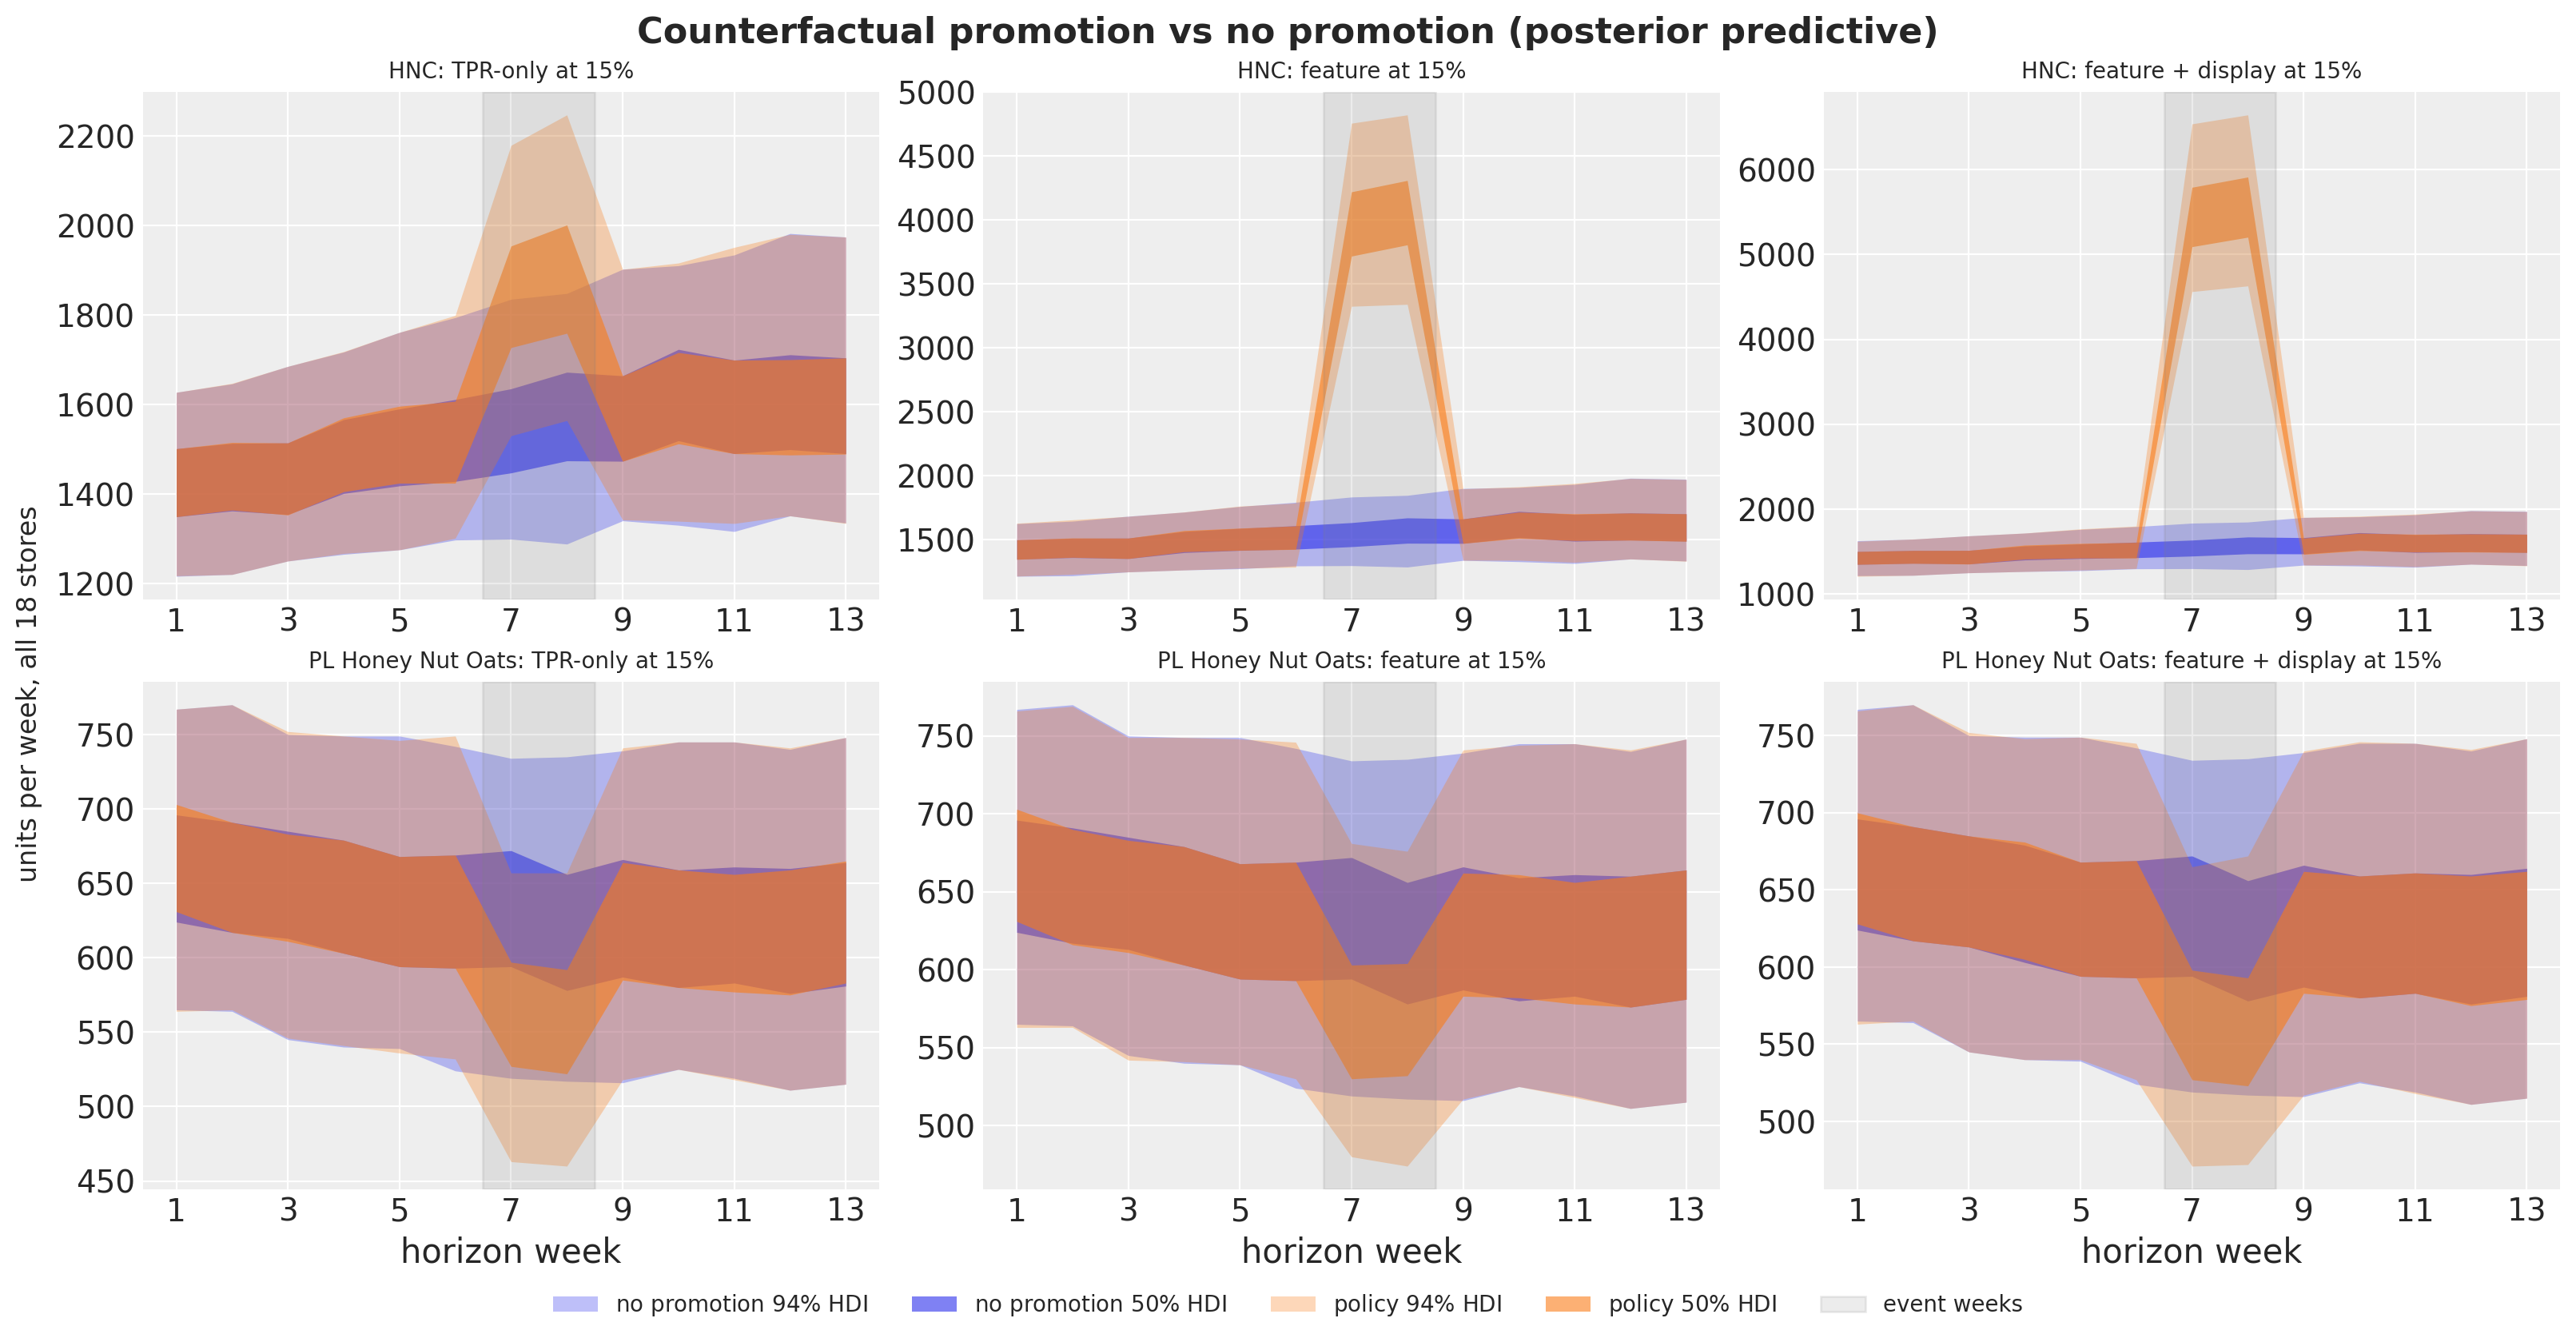

In [55]:
plot_zone_policies(
    [("TPR-only", 0.15), ("feature", 0.15), ("feature + display", 0.15)],
    [FOCAL, "PL Honey Nut Oats"],
    figsize=(16.0, 8.0),
)

## From units to profit

The model forecasts units. The decisions need money. This section states the economics once, prints them, and turns the forecast units of every draw into an event profit. The break-even, risk and order sections then work on that profit.

### The margin of a promoted unit

Take product $j$ at store $s$. Let $p_{j,s}$ be its base price at the last training week. Base prices differ across stores, so every currency number below uses the store's own price. Let $g_j$ be the gross margin on the base price: $0.28$ for the national brands and $0.38$ for the private label. The unit cost is the part of the base price that is not margin:

$$
c_{j,s} = (1 - g_j)\, p_{j,s}.
$$

Now cut the price of the focal product $\text{H}$ by a fraction $d$ of its base price. The manufacturer refunds a share $\alpha$ of the discount on every unit sold in a promotion week. We call this refund the allowance. Three flows set the margin of one promoted unit. The retailer sells the unit at the cut price. The retailer pays the unit cost. The retailer receives the allowance. The sum of the three flows is the promo-week unit margin:

\begin{align*}
m_{\text{H},s}(d) &= p_{\text{H},s}\,(1 - d) - c_{\text{H},s} + \alpha\, d\, p_{\text{H},s} \\
&= p_{\text{H},s}\, \big( g_{\text{H}} - (1 - \alpha)\, d \big).
\end{align*}

The second line is the rule to remember. Each point of depth costs the retailer $(1 - \alpha)$ points of margin rate, and the manufacturer pays the rest. At the median focal base price of $3.02$ the margin is $0.85$ per unit at full price. A $15\%$ cut at the nominal share $\alpha = 0.5$ brings it to $0.62$. An unfunded $30\%$ cut brings it to $-0.06$: the cut is deeper than the margin rate, so every unit sells below cost. The two cells below print the economics table and these worked margins.

The siblings $k \ne \text{H}$ stay at their base price during the event, so their margin is the base-price margin:

$$
m_{k,s} = g_k\, p_{k,s}.
$$

A feature or a display also uses a slot. Its cost $S_m$ per store-week is one number per mechanics, and under feature with display it covers both slots. We never assume a value for $S_m$. The next section solves for it.

In [56]:
is_private_label = np.array(
    [series_ids[n].split("::")[1].startswith("PL") for n in range(n_series)]
)
gross_margin = np.where(is_private_label, 0.38, 0.28)
unit_cost = (1.0 - gross_margin) * base_price
is_focal = series_to_product_np == FOCAL_INDEX
store_onehot = np.eye(n_stores)[series_to_store_np]  # (n_series, n_stores)
N_EVENT_WEEKS = len(EVENT_OFFSETS)
economics_table = pl.DataFrame(
    {
        "product": product_order,
        "gross_margin": [0.38 if p.startswith("PL") else 0.28 for p in product_order],
        "base_price_median": [
            float(np.median(base_price[series_to_product_np == k])) for k in range(n_products)
        ],
        "unit_cost_median": [
            float(np.median(unit_cost[series_to_product_np == k])) for k in range(n_products)
        ],
    }
)
economics_table

product,gross_margin,base_price_median,unit_cost_median
"""HNC""",0.28,3.02,2.1744
"""Cheerios 12oz""",0.28,3.055,2.1996
"""Cheerios 18oz""",0.28,4.79,3.4488
"""Mini Wheats""",0.28,3.89,2.8008
"""PL Honey Nut Oats""",0.38,1.895,1.1749
"""PL Frosted Wheat""",0.38,2.41,1.4942


In [57]:
G_FOCAL = float(gross_margin[is_focal][0])
p_focal_median = float(np.median(base_price[is_focal]))
margin_depths = [0.0, 0.15, 0.30]
margin_shares = [0.0, 0.5, 1.0]
unit_margin_table = pl.DataFrame(
    {
        "depth": margin_depths,
        **{
            f"unit margin at alpha = {alpha_value:.1f}": [
                round(p_focal_median * (G_FOCAL - (1.0 - alpha_value) * d), 2)
                for d in margin_depths
            ]
            for alpha_value in margin_shares
        },
    }
)
print(
    f"median focal base price {p_focal_median:.2f} | gross margin {G_FOCAL:.2f} | threshold "
    "elasticity (1 - alpha) / g: "
    + " | ".join(f"alpha {a:.1f}: {(1.0 - a) / G_FOCAL:.2f}" for a in margin_shares)
)
unit_margin_table

median focal base price 3.02 | gross margin 0.28 | threshold elasticity (1 - alpha) / g: alpha 0.0: 3.57 | alpha 0.5: 1.79 | alpha 1.0: 0.00


depth,unit margin at alpha = 0.0,unit margin at alpha = 0.5,unit margin at alpha = 1.0
0.0,0.85,0.85,0.85
0.15,0.39,0.62,0.85
0.3,-0.06,0.39,0.85


### The event profit and the funding share

A policy $a = (d, m)$ fixes a depth $d$ and a mechanics $m$ for the two event weeks. The quantity we want is the expected event profit of a policy under the posterior predictive, $\text{E}[\Pi(a)]$. This is the estimand of the decision layer. The rules of the next sections compare policies on it, on its lower tail, and on the order quantity.

We estimate it from posterior draws. Let $r = 1, \dots, R$ index one draw of the parameters and of the future level path; we write $\theta_r$ for both together. Let $E = \{7, 8\}$ be the set of event weeks. Let $y_{r,t,i}(a)$ be the sampled unit count of series $i$ in week $t$ under policy $a$ in draw $r$; it includes the demand noise. Write $i \in \text{H}$ for the 18 focal series, one per store, and $i \notin \text{H}$ for the sibling series. Let $\text{margin}_{i,t}(a)$ be the unit margin of series $i$ under the policy: $m_{\text{H},s(i)}(d)$ for a focal series and $m_{\text{prod}(i),s(i)}$ for a sibling series. The event profit of draw $r$ adds the margin dollars of every series over the event weeks and subtracts the slot cost:

$$
\Pi_r(a) = \sum_{t \in E} \sum_{i} \text{margin}_{i,t}(a)\, y_{r,t,i}(a) - S(a), \qquad S(a) = 2 \times 18 \times S_m.
$$

The slot is paid in each of the two event weeks in each of the 18 stores. We set $S = 0$ in every break-even and risk computation. Let $a_0$ be the no-promotion baseline and $\Delta\Pi_r(a) = \Pi_r(a) - \Pi_r(a_0)$ the incremental profit of a policy. An assumed slot cost shifts every histogram of $\Delta\Pi$ by a constant, so $\text{P}(\Delta\Pi < S)$ can be read off the same figures.

The units do not depend on $\alpha$, because the model has no funding term. Only the margin does, and it is linear in $\alpha$. So the event profit of a draw is a straight line in the funding share:

$$
\Pi_r(a) = A_r(a) + \alpha\, B_r(a),
$$

with

\begin{align*}
A_r(a) &= \sum_{t \in E} \sum_{i \in \text{H}} p_{\text{H},s(i)}\,(g_{\text{H}} - d)\, y_{r,t,i}(a) + \sum_{t \in E} \sum_{i \notin \text{H}} m_{\text{prod}(i),s(i)}\, y_{r,t,i}(a) - S(a), \\
B_r(a) &= d \sum_{t \in E} \sum_{i \in \text{H}} p_{\text{H},s(i)}\, y_{r,t,i}(a).
\end{align*}

$A_r(a)$ is the event profit when the retailer funds the whole cut. $B_r(a)$ is the discount dollars given away on the focal units sold: depth times base price times units. The allowance refunds the share $\alpha$ of these dollars. $B_r(a)$ is positive whenever $d > 0$, so a higher funding share always raises profit. One set of draws therefore serves every funding share, and `profit_parts` in the next cell returns exactly these two parts.

Profit is linear in units. So, given the parameters and the level path of draw $r$, the expected profit is the same sum with the conditional means $\mu_{r,t,i}(a)$ in place of the sampled counts:

$$
\Pi^\mu_r(a) = \text{E}[\Pi(a) \mid \theta_r] = \sum_{t \in E} \sum_{i} \text{margin}_{i,t}(a)\, \mu_{r,t,i}(a) - S(a).
$$

The average of $\Pi^\mu_r(a)$ over the draws estimates the estimand without any observation-noise error:

$$
\text{E}[\Pi(a)] = \text{E}\big[\text{E}[\Pi(a) \mid \theta]\big] \approx \frac{1}{R} \sum_{r=1}^{R} \Pi^\mu_r(a).
$$

The bands of $\Pi^\mu$ in the next section still carry the sampled level path. The sampled counts return in the risk and order sections, where the demand noise matters. The next cell builds the two parts and prints the no-promotion event profit. Over the 18 stores its mean is $10{,}269$ currency units. The parameters and the level path give it a standard deviation of $221$; with the demand noise it is $312$.

In [58]:
def profit_parts(
    units: Float[np.ndarray, " sample n_series"], depth: float, brand_only: bool = False
) -> tuple[Float[np.ndarray, " sample"], Float[np.ndarray, " sample"]]:
    """Event profit as ``A + alpha * B`` per draw: the part at zero funding and the funding coefficient."""
    margin_at_zero = np.where(
        is_focal,
        base_price * (gross_margin - depth),
        0.0 if brand_only else gross_margin * base_price,
    )
    part_a = units @ margin_at_zero
    part_b = depth * (units[:, is_focal] @ base_price[is_focal])
    return part_a, part_b


def profit_parts_by_store(
    units: Float[np.ndarray, " sample n_series"], depth: float, brand_only: bool = False
) -> tuple[Float[np.ndarray, " sample n_stores"], Float[np.ndarray, " sample n_stores"]]:
    """Decompose the event profit as ``A + alpha * B`` with one column per store."""
    margin_at_zero = np.where(
        is_focal,
        base_price * (gross_margin - depth),
        0.0 if brand_only else gross_margin * base_price,
    )
    part_a = (units * margin_at_zero) @ store_onehot
    part_b = depth * ((units * (is_focal * base_price)) @ store_onehot)
    return part_a, part_b


def event_profit(
    units: Float[np.ndarray, " sample n_series"],
    depth: float,
    alpha: float,
    brand_only: bool = False,
) -> Float[np.ndarray, " sample"]:
    """Event profit per draw at a funding share ``alpha`` and zero slot cost."""
    part_a, part_b = profit_parts(units, depth, brand_only=brand_only)
    return part_a + alpha * part_b


baseline_mu = event_profit(event_units_mu[BASELINE], 0.0, 0.5)
baseline_paths = event_profit(event_units_paths[BASELINE], 0.0, 0.5)
print(
    f"no-promotion event profit over {n_stores} stores: mean {baseline_mu.mean():,.0f} | "
    f"sd from parameters and level path {baseline_mu.std():,.0f} "
    f"| sd including demand noise {baseline_paths.std():,.0f}"
)

no-promotion event profit over 18 stores: mean 10,269 | sd from parameters and level path 221 | sd including demand noise 312


### A single-product rule of thumb

The numerical shares below come from the full model. A one-product version shows the mechanics of the answer. Let $N_0$ be the expected event units of the focal product in one store at base price and without mechanics. From the model section, a mechanics $m$ multiplies the units by the uplift $e^{b_m}$ and a cut of depth $d$ by $(1 - d)^{\varepsilon_m}$, with $\varepsilon_m < 0$ the mechanics-specific elasticity. Write $m_{\text{H}}(d)$ for the promo-week unit margin of the store. The profit of the focal product alone is margin per unit times units, minus the slot:

$$
\pi_m(d) = m_{\text{H}}(d)\, N_0\, (1 - d)^{\varepsilon_m}\, e^{b_m} - S_m.
$$

Its derivative in $d$ has the sign of

$$
\big(-g_{\text{H}}\, \varepsilon_m - (1 - \alpha)\big) + (1 - \alpha)(1 + \varepsilon_m)\, d.
$$

The first bracket is the trade-off at the first point of depth: the point raises units by $-\varepsilon_m$ percent, each worth $g_{\text{H}}$ of margin rate, and it costs $(1 - \alpha)$ points of margin rate. So a first point of depth pays if and only if $\varepsilon_m < -\varepsilon^\star(\alpha)$, with the threshold elasticity

$$
\varepsilon^\star(\alpha) = \frac{1 - \alpha}{g_{\text{H}}}.
$$

The cell above prints it: $3.57$ when the retailer funds the whole cut, $1.79$ at the nominal share, $0$ when the manufacturer funds everything. Solve the same condition for $\alpha$ instead, and you get the brand-only break-even share of a mechanics:

$$
\alpha^\star_m = 1 + g_{\text{H}}\, \varepsilon_m.
$$

It reads as follows. At or below $0$ the cut pays even if the retailer funds it alone. At or above $1$ no funding share makes it pay. The tables report its intervals unclipped with this rule. Cannibalization raises the share, because the cut moves sibling units through the cross elasticities $\gamma_{\text{H},k}$. Let $\tilde N_{j,s,m}$ be the expected event units of product $j$ at store $s$ at zero depth under mechanics $m$. The category break-even share is

$$
\alpha^\star_{\text{cat},m} = \alpha^\star_m + \frac{\sum_s \sum_{k \ne \text{H}} m_{k,s}\, \tilde N_{k,s,m}\, \gamma_{\text{H},k}}{\sum_s p_{\text{H},s}\, \tilde N_{\text{H},s,m}}.
$$

The numerator is the sibling margin lost per unit of log price change; the denominator is the focal product's promo-week gross revenue at zero depth. The ratio is the extra share the manufacturer must fund to cover what the siblings lose. With $|\varepsilon_m| \le 1$ the second bracket of the derivative grows with $d$, so the best cell of a depth grid is a corner:

- Below the event-level share of the deepest cell, the shallowest cell is best.
- Above the tangent share $\alpha^\star_m$, the deepest cell is best.
- In the narrow band between them, compare the two corners directly.

With $|\varepsilon_m| > 1$ an interior depth exists for a narrow band of funding shares. The notebook computes two numerical shares per draw from the stored conditional means, so that the cross terms and the sibling flags enter through the model. The secant share sets the profits of the two shallowest cells of a mechanics equal, $a_{\text{lo}}$ and $a_{\text{hi}}$ (zero and five points for a flagged mechanics, no promotion and ten points for a shelf tag alone):

$$
\alpha^{\text{sec}}_{r,m} = \frac{A_r(a_{\text{lo}}) - A_r(a_{\text{hi}})}{B_r(a_{\text{hi}}) - B_r(a_{\text{lo}})}.
$$

Its brand-only version drops the sibling terms from $A_r$. The event-level share of a grid cell $a$ is the funding share at which the cell breaks even against no promotion:

$$
\alpha^{\text{ev}}_r(a) = -\frac{A_r(a) - A_r(a_0)}{B_r(a)}.
$$

A negative value means the cell pays unfunded; a value above one means no funding share makes it pay. Three variants, as remarks:

- A lump-sum allowance $L$ instead of a per-unit one adds $L$ to $A_r$ and removes $\alpha B_r$, so the break-even question becomes a question about $L$.
- A perishable product replaces the holding cost of the order section by a write-off of the leftover.
- The $\Pi^\mu$ argument only uses linearity in units, so it holds under a Poisson likelihood or any likelihood whose conditional mean the model registers.

## Break-even: who funds the discount and what is a slot worth

### The funding share

The figure shows the expected event profit of the category against the depth of the focal product's cut, one row per mechanics and one column per funding share: the nominal $0.5$, the posterior median of the category break-even share of the feature-with-display mechanics, and that share plus $0.15$. The bands are the $50\%$ and $94\%$ HDIs across draws of $\Pi^\mu$, so they carry the parameter and level-path uncertainty and not the demand noise; shaded depths have thin support. The printed tables give, per mechanics, the probability that no promotion or the shallowest cell is the best choice at the nominal share, the range of expected profit across the grid at the break-even share, the threshold table, and the posteriors of the break-even shares themselves: brand-only, category, and the event-level share of every grid cell. A negative event-level share means the event pays even if the retailer funds the whole cut; a share above one means no funding makes it pay.

The posterior median of the category break-even share of feature with display is $0.71$, which becomes $\tilde\alpha$; the columns of the figure are $0.50$, $0.71$ and $0.86$. The tables bracket the decision:

- At the nominal share every curve falls with depth. The probability that no promotion or the shallowest cell is optimal is $1.00$ for all four mechanics, and the expected profit lost between the shallowest and the deepest cell is $17\%$ of the baseline event profit for a shelf-tag cut and $40\%$ for feature with display.
- At $\tilde\alpha$ the curves are flat. The range of expected profit across the grid is $1.5\%$ of the baseline for feature with display and $3.2\%$ for a shelf-tag cut, the deepest cell is optimal in $63\%$ of the draws for feature with display, and the value of perfect information about the parameters and the level path is at most $1.1\%$ of the baseline.
- The threshold table: at $\alpha = 0.5$ the threshold elasticity is $-1.79$ and the posterior probability of exceeding it is $0.00$ under every mechanics; at $\tilde\alpha$ the probability is $0.85$ for feature with display from the brand-only tangent but $0.50$ from the category secant, the difference being the cannibalization of the siblings; at $\alpha = 0.9$ every probability is $1.00$.
- The break-even shares: the brand-only shares sit between $0.68$ and $0.70$ for the four mechanics with $94\%$ HDIs about $0.1$ wide, and cannibalization adds $0.03$ under feature with display and $0.09$ under a shelf-tag cut.
- What a $15\%$ cut needs: under feature with display the event pays unfunded, with an event-level share of $-0.32$, under a feature alone $-0.12$; the same cut under a shelf tag needs a share of $0.79$, and a $30\%$ cut under feature with display needs $0.30$.

In [59]:
feature_depth_draws = np.asarray(posterior["b_feat_depth"])[:, FOCAL_INDEX]
display_depth_draws = np.asarray(posterior["b_disp_depth"])[:, FOCAL_INDEX]
eps_focal_draws = eps_prod_draws[:, FOCAL_INDEX]


def eps_m_draws(mechanics_name: str) -> Float[np.ndarray, " sample"]:
    """Zone-level mechanics-specific elasticity draws of the focal product."""
    feature_flag, display_flag = MECHANICS[mechanics_name]
    return (
        eps_focal_draws - feature_depth_draws * feature_flag - display_depth_draws * display_flag
    )


def marginal_secant(mechanics_name: str, brand_only: bool) -> Float[np.ndarray, " sample"]:
    """Per-draw funding share at which the two shallowest cells of a mechanics break even."""
    if mechanics_name == "TPR-only":
        shallow, deeper = BASELINE, ("TPR-only", 0.10)
    else:
        shallow, deeper = (mechanics_name, 0.0), (mechanics_name, 0.05)
    a_shallow, b_shallow = profit_parts(event_units_mu[shallow], shallow[1], brand_only=brand_only)
    a_deeper, b_deeper = profit_parts(event_units_mu[deeper], deeper[1], brand_only=brand_only)
    return (a_shallow - a_deeper) / (b_deeper - b_shallow)


break_even_rows = []
alpha_star_cat: dict[str, np.ndarray] = {}
for mechanics_name in MECHANICS:
    brand = marginal_secant(mechanics_name, brand_only=True)
    category = marginal_secant(mechanics_name, brand_only=False)
    tangent = 1.0 + G_FOCAL * eps_m_draws(mechanics_name)
    alpha_star_cat[mechanics_name] = category
    for label, draws_share in [
        ("brand-only secant", brand),
        ("category secant", category),
        ("brand-only tangent", tangent),
    ]:
        break_even_rows.append(
            {"mechanics": mechanics_name, "share": label, **interval_row(draws_share)}
        )
    break_even_rows.append(
        {
            "mechanics": mechanics_name,
            "share": "cannibalization (category - brand)",
            **interval_row(category - brand),
        }
    )
break_even_table = pl.DataFrame(break_even_rows)
alpha_tilde = float(np.clip(np.median(alpha_star_cat["feature + display"]), 0.0, 1.0))
print(
    f"posterior median category break-even share of feature + display: "
    f"{np.median(alpha_star_cat['feature + display']):.3f} (used as alpha tilde = {alpha_tilde:.3f})"
)
break_even_table

posterior median category break-even share of feature + display: 0.711 (used as alpha tilde = 0.711)


mechanics,share,median,hdi50_lower,hdi50_upper,hdi94_lower,hdi94_upper
"""TPR-only""","""brand-only secant""",0.697013,0.683315,0.714202,0.654446,0.741138
"""TPR-only""","""category secant""",0.790207,0.773714,0.812475,0.73587,0.847788
"""TPR-only""","""brand-only tangent""",0.697032,0.681014,0.721436,0.638847,0.754949
"""TPR-only""","""cannibalization (category - brand)""",0.092827,0.080796,0.104642,0.061416,0.126411
"""display""","""brand-only secant""",0.687541,0.669759,0.710609,0.631388,0.745311
"""display""","""category secant""",0.756083,0.734172,0.776233,0.696231,0.814705
"""display""","""brand-only tangent""",0.686353,0.662039,0.711423,0.622384,0.757348
"""display""","""cannibalization (category - brand)""",0.068226,0.060932,0.079043,0.043099,0.092802
"""feature""","""brand-only secant""",0.686663,0.6644,0.704854,0.630727,0.745228
"""feature""","""category secant""",0.73353,0.71566,0.756331,0.678535,0.793314


In [60]:
alpha_grid = sorted({0.0, 0.25, 0.5, alpha_tilde, 0.75, 0.9, 1.0})
threshold_rows = []
for alpha_value in alpha_grid:
    eps_star = (1.0 - alpha_value) / G_FOCAL
    row: dict[str, float | str] = {"alpha": alpha_value, "eps_star": eps_star}
    for mechanics_name in MECHANICS:
        row[f"P(eps_m < -eps*) {mechanics_name}"] = float(
            np.mean(eps_m_draws(mechanics_name) < -eps_star)
        )
        row[f"P(alpha*_cat < alpha) {mechanics_name}"] = float(
            np.mean(alpha_star_cat[mechanics_name] < alpha_value)
        )
    threshold_rows.append(row)
threshold_table = pl.DataFrame(threshold_rows)
threshold_table

alpha,eps_star,P(eps_m < -eps*) TPR-only,P(alpha*_cat < alpha) TPR-only,P(eps_m < -eps*) display,P(alpha*_cat < alpha) display,P(eps_m < -eps*) feature,P(alpha*_cat < alpha) feature,P(eps_m < -eps*) feature + display,P(alpha*_cat < alpha) feature + display
0.0,3.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.25,2.678571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.5,1.785714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.710882,1.032565,0.676,0.00375,0.74675,0.07225,0.7575,0.22725,0.8485,0.5
0.75,0.892857,0.956,0.0865,0.96175,0.4245,0.96025,0.708,0.9855,0.919
0.9,0.357143,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


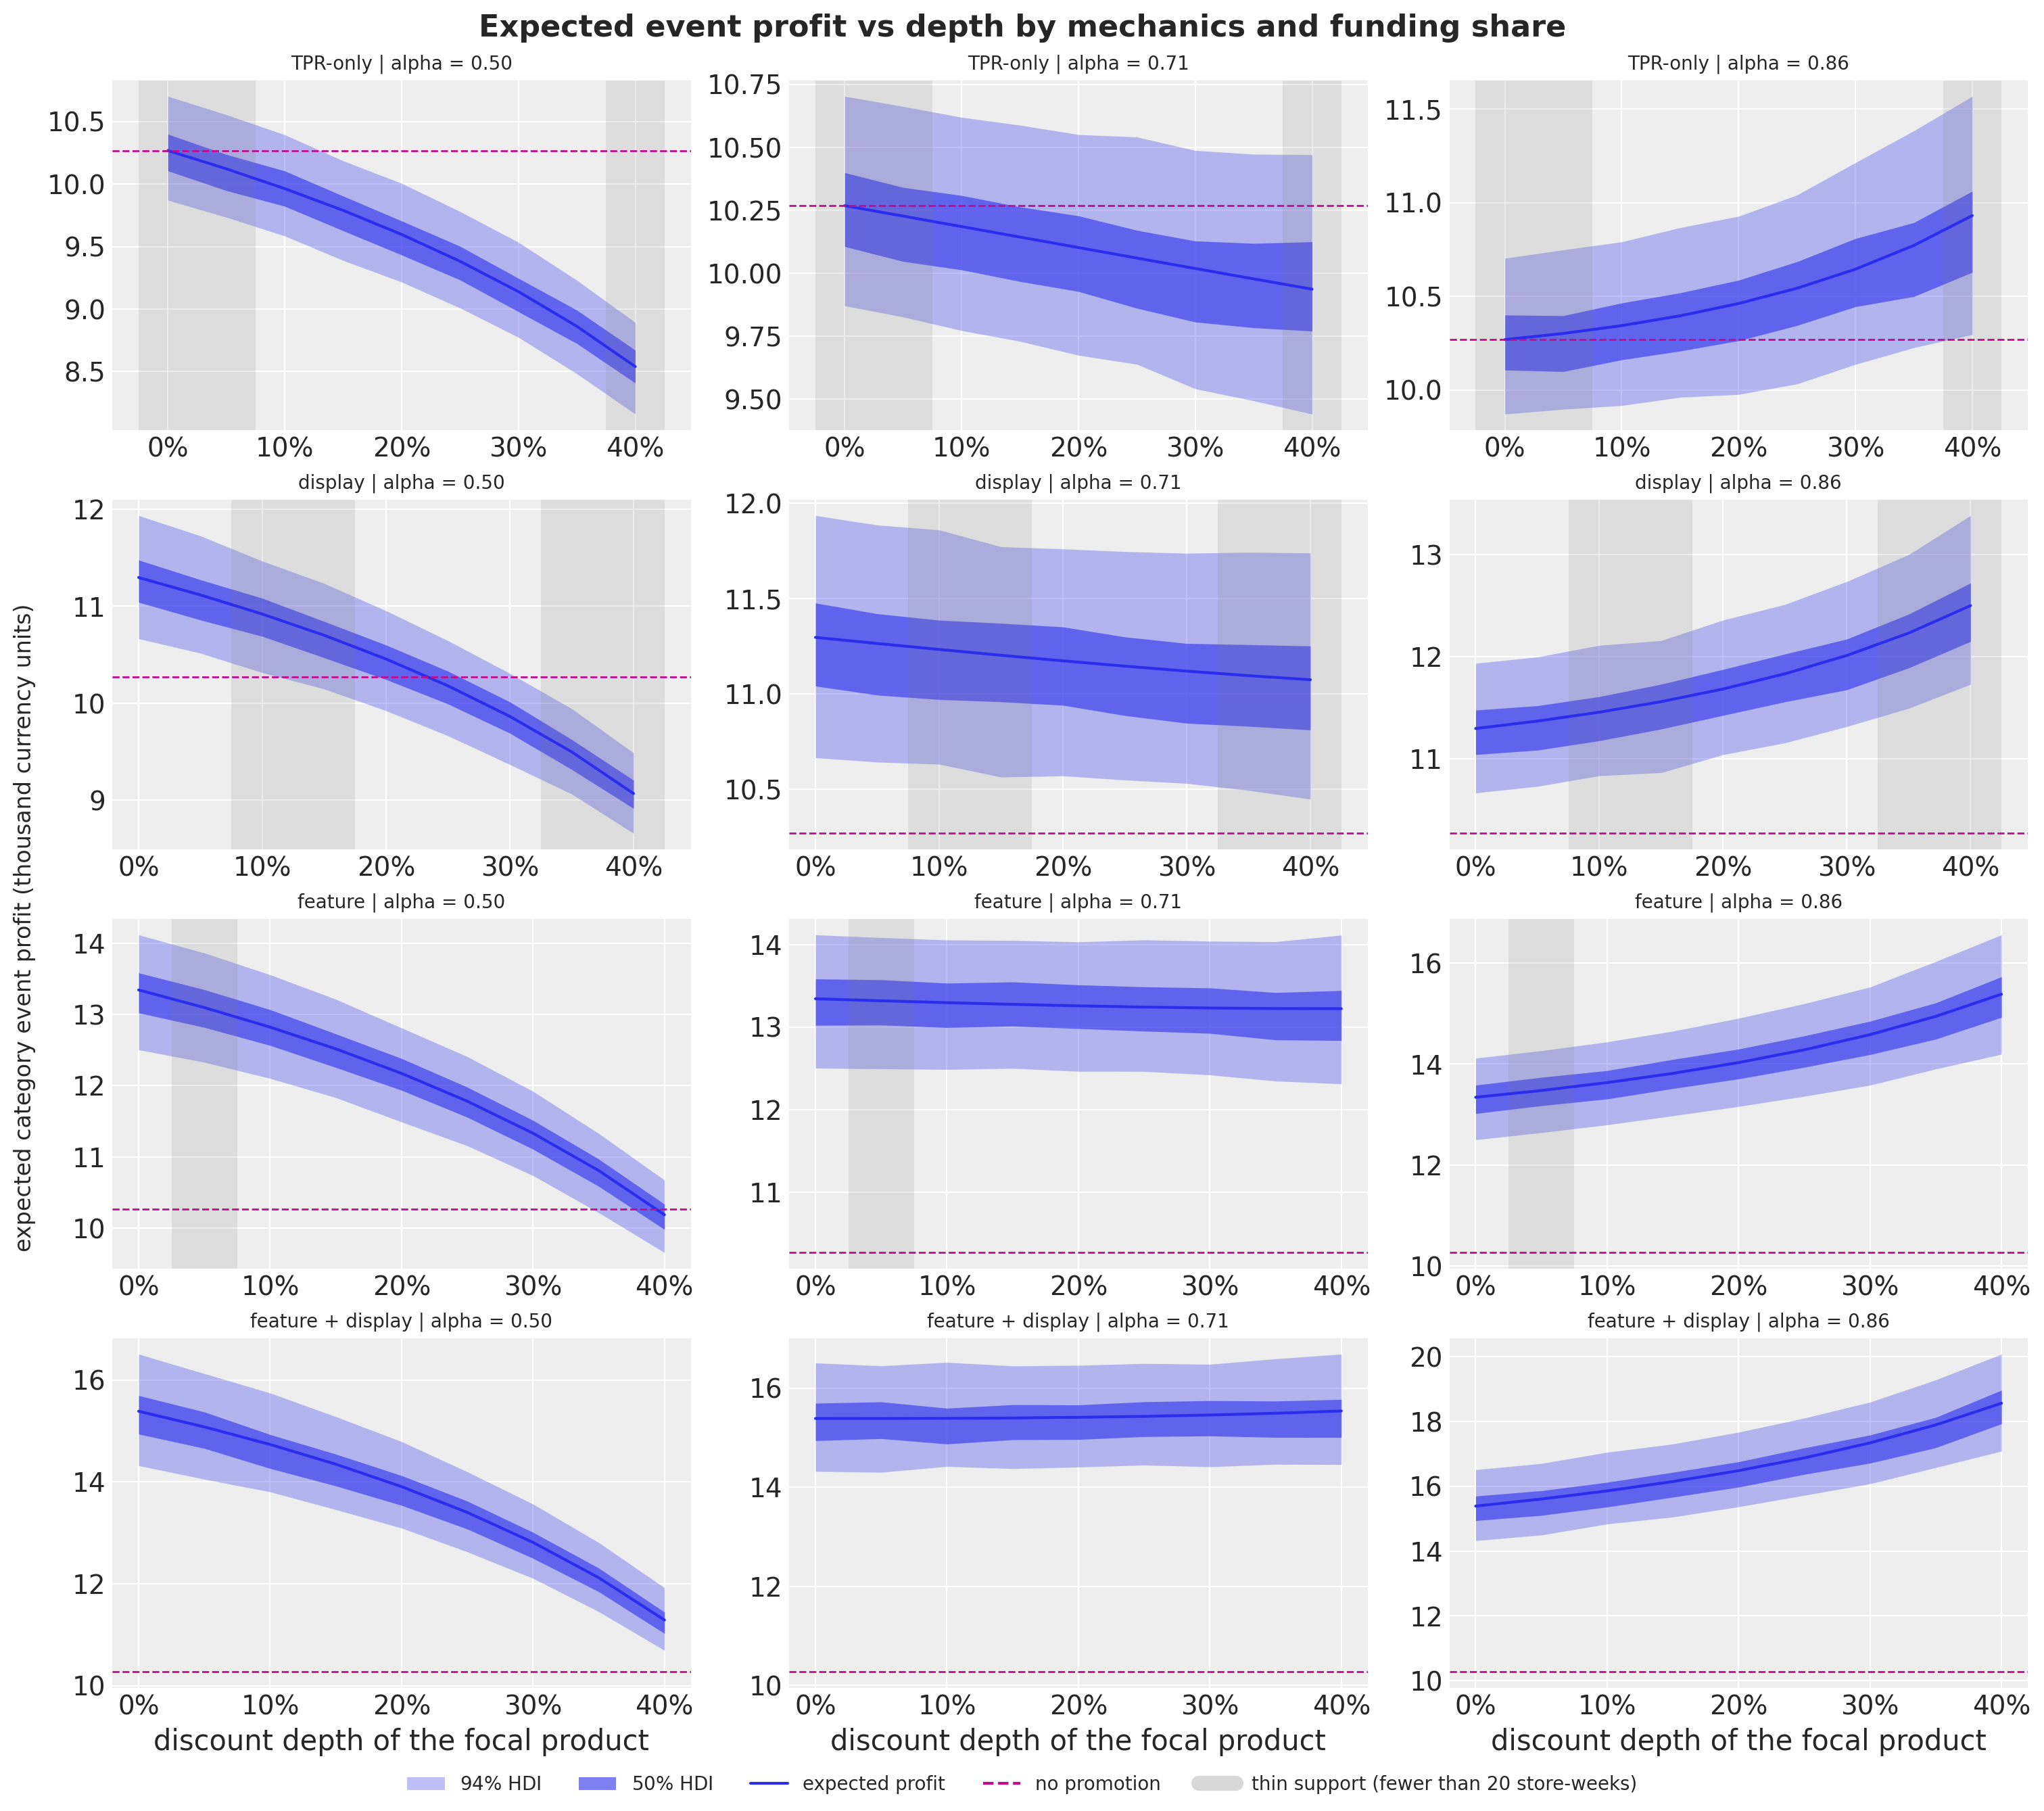

In [61]:
def profit_curve(
    mechanics_name: str, alpha_value: float, kind: str = "mu"
) -> Float[np.ndarray, " sample n_depth"]:
    """Event profit draws of one mechanics across the depth grid at a funding share."""
    source = event_units_mu if kind == "mu" else event_units_paths
    return np.stack(
        [
            event_profit(source[(mechanics_name, float(d))], float(d), alpha_value)
            for d in DEPTH_GRID
        ],
        axis=1,
    )


alpha_columns = [0.5, alpha_tilde, float(min(1.0, alpha_tilde + 0.15))]
curve_labels = [
    f"{mechanics_name} | alpha = {alpha_value:.2f}"
    for mechanics_name in MECHANICS
    for alpha_value in alpha_columns
]
curve_draws = np.stack(
    [
        profit_curve(mechanics_name, alpha_value)
        for mechanics_name in MECHANICS
        for alpha_value in alpha_columns
    ],
    axis=-1,
)
pc = az.plot_lm(
    predictions_to_datatree(curve_draws / 1_000.0, DEPTH_GRID.astype(float), curve_labels),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    col_wrap=3,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": {"color": "C0", "alpha": 1.0, "width": 1.5},
        "xlabel": False,
        "ylabel": False,
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (15, 13)},
)
for label, mechanics_name in zip(
    curve_labels, [m for m in MECHANICS for _ in alpha_columns], strict=True
):
    ax = pc.get_target("t", {"series": label})
    ax.set_title(label, fontsize=10)
    ax.axhline(float(baseline_mu.mean()) / 1_000.0, color="C3", linestyle="--", linewidth=1)
    for d, count in zip(DEPTH_GRID, support_counts[mechanics_name], strict=True):
        if count < 20:
            ax.axvspan(float(d) - 0.025, float(d) + 0.025, color="gray", alpha=0.15, linewidth=0)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
bands = pc.viz["ci_band"]["t"].sel(series=curve_labels[-1])
curve_handles = [bands.sel(prob=prob).item() for prob in (0.94, 0.5)]
for handle, prob in zip(curve_handles, (0.94, 0.5), strict=True):
    handle.set_label(hdi_label(prob))
mean_line = pc.viz["pe_line"]["t"].sel(series=curve_labels[-1]).item()
mean_line.set_label("expected profit")
curve_handles += [
    mean_line,
    mlines.Line2D([], [], color="C3", linestyle="--", label="no promotion"),
    mlines.Line2D(
        [],
        [],
        color="gray",
        linewidth=8,
        alpha=0.3,
        label="thin support (fewer than 20 store-weeks)",
    ),
]
fig = pc.viz["figure"].item()
fig.legend(handles=curve_handles, loc="outside lower center", ncols=5, fontsize=10)
for label in curve_labels[-3:]:
    pc.get_target("t", {"series": label}).set_xlabel("discount depth of the focal product")
fig.supylabel("expected category event profit (thousand currency units)")
fig.suptitle(
    "Expected event profit vs depth by mechanics and funding share",
    fontsize=16,
    fontweight="bold",
    y=1.02,
);

In [62]:
optimal_rows = []
for mechanics_name in MECHANICS:
    for alpha_value in (0.5, alpha_tilde):
        curve = profit_curve(mechanics_name, alpha_value)
        choice_set = np.concatenate(
            [baseline_mu[:, None], curve], axis=1
        )  # no promotion plus the grid
        best = choice_set.argmax(axis=1)
        regret = choice_set.max(axis=1, keepdims=True) - choice_set
        expected_regret = regret.mean(axis=0)
        grid_range = curve.mean(axis=0).max() - curve.mean(axis=0).min()
        optimal_rows.append(
            {
                "mechanics": mechanics_name,
                "alpha": alpha_value,
                "P(no promotion or shallowest optimal)": float(np.isin(best, [0, 1]).mean()),
                "P(deepest optimal)": float(np.mean(best == choice_set.shape[1] - 1)),
                "expected profit range over the grid / baseline": float(
                    grid_range / baseline_mu.mean()
                ),
                "max expected regret / baseline": float(
                    expected_regret.max() / baseline_mu.mean()
                ),
                "min expected regret (value of perfect information) / baseline": float(
                    expected_regret.min() / baseline_mu.mean()
                ),
            }
        )
optimal_table = pl.DataFrame(optimal_rows)
optimal_table

mechanics,alpha,P(no promotion or shallowest optimal),P(deepest optimal),expected profit range over the grid / baseline,max expected regret / baseline,min expected regret (value of perfect information) / baseline
"""TPR-only""",0.5,1.0,0.0,0.168363,0.168363,0.0
"""TPR-only""",0.710882,0.98775,0.01225,0.032303,0.032384,0.000082
"""display""",0.5,1.0,0.0,0.216845,0.216845,0.0
"""display""",0.710882,0.834,0.166,0.021611,0.102136,0.002087
"""feature""",0.5,1.0,0.0,0.307424,0.307424,0.0
"""feature""",0.710882,0.64275,0.35725,0.011714,0.307613,0.008284
"""feature + display""",0.5,1.0,0.0,0.399228,0.498545,0.0
"""feature + display""",0.710882,0.3675,0.6325,0.014817,0.523878,0.010572


In [63]:
event_rows_table = []
a_baseline, _ = profit_parts(event_units_mu[BASELINE], 0.0)
for mechanics_name in MECHANICS:
    for d in DEPTH_GRID:
        policy = (mechanics_name, float(d))
        a_policy, b_policy = profit_parts(event_units_mu[policy], float(d))
        incremental_at_zero = a_policy - a_baseline
        if d > 0:
            share = -incremental_at_zero / b_policy
            event_rows_table.append(
                {
                    "mechanics": mechanics_name,
                    "depth": float(d),
                    "P(pays unfunded)": float(np.mean(incremental_at_zero > 0)),
                    **interval_row(share),
                }
            )
        else:
            event_rows_table.append(
                {
                    "mechanics": mechanics_name,
                    "depth": float(d),
                    "P(pays unfunded)": float(np.mean(incremental_at_zero > 0)),
                    "median": float("nan"),
                    "hdi50_lower": float("nan"),
                    "hdi50_upper": float("nan"),
                    "hdi94_lower": float("nan"),
                    "hdi94_upper": float("nan"),
                }
            )
event_share_table = pl.DataFrame(event_rows_table)
event_share_table.filter(pl.col("depth").is_in([0.0, 0.15, 0.30]))

mechanics,depth,P(pays unfunded),median,hdi50_lower,hdi50_upper,hdi94_lower,hdi94_upper
"""TPR-only""",0.0,0.0,NaN,NaN,NaN,NaN,NaN
"""TPR-only""",0.15,0.0,0.7855,0.766753,0.804573,0.733981,0.843155
"""TPR-only""",0.3,0.0,0.771285,0.754647,0.7894,0.72233,0.821388
"""display""",0.0,1.0,NaN,NaN,NaN,NaN,NaN
"""display""",0.15,0.0,0.320007,0.275784,0.352053,0.219066,0.432905
"""display""",0.3,0.0,0.568122,0.548148,0.579725,0.526168,0.615842
"""feature""",0.0,1.0,NaN,NaN,NaN,NaN,NaN
"""feature""",0.15,1.0,-0.122924,-0.143968,-0.106459,-0.174297,-0.068881
"""feature""",0.3,0.0,0.382358,0.374322,0.39086,0.358368,0.406404
"""feature + display""",0.0,1.0,NaN,NaN,NaN,NaN,NaN


### The slot cost

A feature or a display is a slot with a cost the data do not contain, so we solve for it. The break-even slot cost of a mechanics at a depth is the incremental gross event profit it adds over a shelf-tag-only cut of the same depth, divided by the number of store-weeks it occupies; at zero depth the comparison is against no promotion at all (a pure mechanics uplift, which is not comparable to a shelf-tag cut at ten points). The forest plot shows these break-even slot costs with their HDIs at the nominal and at the break-even funding share. The table then assumes a cost per slot and store-week, the same for a feature and for a display (the pair costs twice as much), and prints the posterior probability that each mechanics is the best choice over the whole grid as that cost rises.

The slot values and the ladder, from the cells below:

- At a $15\%$ cut and the break-even share, a display is worth $29$ currency units per store-week over the same cut with a shelf tag alone ($94\%$ HDI $20$ to $39$), a feature $87$ ($74$ to $102$) and the pair $145$ ($126$ to $167$).
- At the nominal share the same values are $25$, $75$ and $126$, because the margin lost on the extra units counts against the slot.
- With slots at $25$ per store-week, feature with display is the best choice with probability $1.00$ at both shares.
- At $50$ it keeps a probability of $0.74$ at the nominal share and $0.89$ at the break-even share, against a feature alone.
- At $75$ the feature alone wins with probability $0.86$ and $0.87$; at $100$ no promotion wins with probability $0.96$ and $0.92$.

In [64]:
slot_rows = []
slot_draws: dict[tuple[str, float, float], np.ndarray] = {}
for mechanics_name in ["display", "feature", "feature + display"]:
    for d in (0.0, 0.15, 0.30):
        for alpha_value in (0.5, alpha_tilde):
            with_mechanics = event_profit(event_units_mu[(mechanics_name, d)], d, alpha_value)
            reference = (
                baseline_mu
                if d == 0.0
                else event_profit(event_units_mu[("TPR-only", d)], d, alpha_value)
            )
            slot_cost_draws = (with_mechanics - reference) / (N_EVENT_WEEKS * n_stores)
            slot_draws[(mechanics_name, d, alpha_value)] = slot_cost_draws
            slot_rows.append(
                {
                    "mechanics": mechanics_name,
                    "depth": d,
                    "alpha": alpha_value,
                    **interval_row(slot_cost_draws),
                }
            )
slot_table = pl.DataFrame(slot_rows)
slot_table

mechanics,depth,alpha,median,hdi50_lower,hdi50_upper,hdi94_lower,hdi94_upper
"""display""",0.0,0.5,28.2748,24.367533,32.177065,17.83479,40.102751
"""display""",0.0,0.710882,28.2748,24.367533,32.177065,17.83479,40.102751
"""display""",0.15,0.5,25.132089,21.187563,27.276858,16.993795,34.191711
"""display""",0.15,0.710882,29.183999,24.676837,31.629881,19.796266,39.334415
"""display""",0.3,0.5,20.091773,17.735554,22.596463,13.714185,27.389253
"""display""",0.3,0.710882,30.523789,27.812051,34.736939,21.073995,40.435422
"""feature""",0.0,0.5,85.030022,78.347939,89.288312,70.367315,101.062421
"""feature""",0.0,0.710882,85.030022,78.347939,89.288312,70.367315,101.062421
"""feature""",0.15,0.5,75.414691,70.808471,79.123069,64.392674,88.398613
"""feature""",0.15,0.710882,86.618457,81.552727,91.111667,74.062825,101.682816


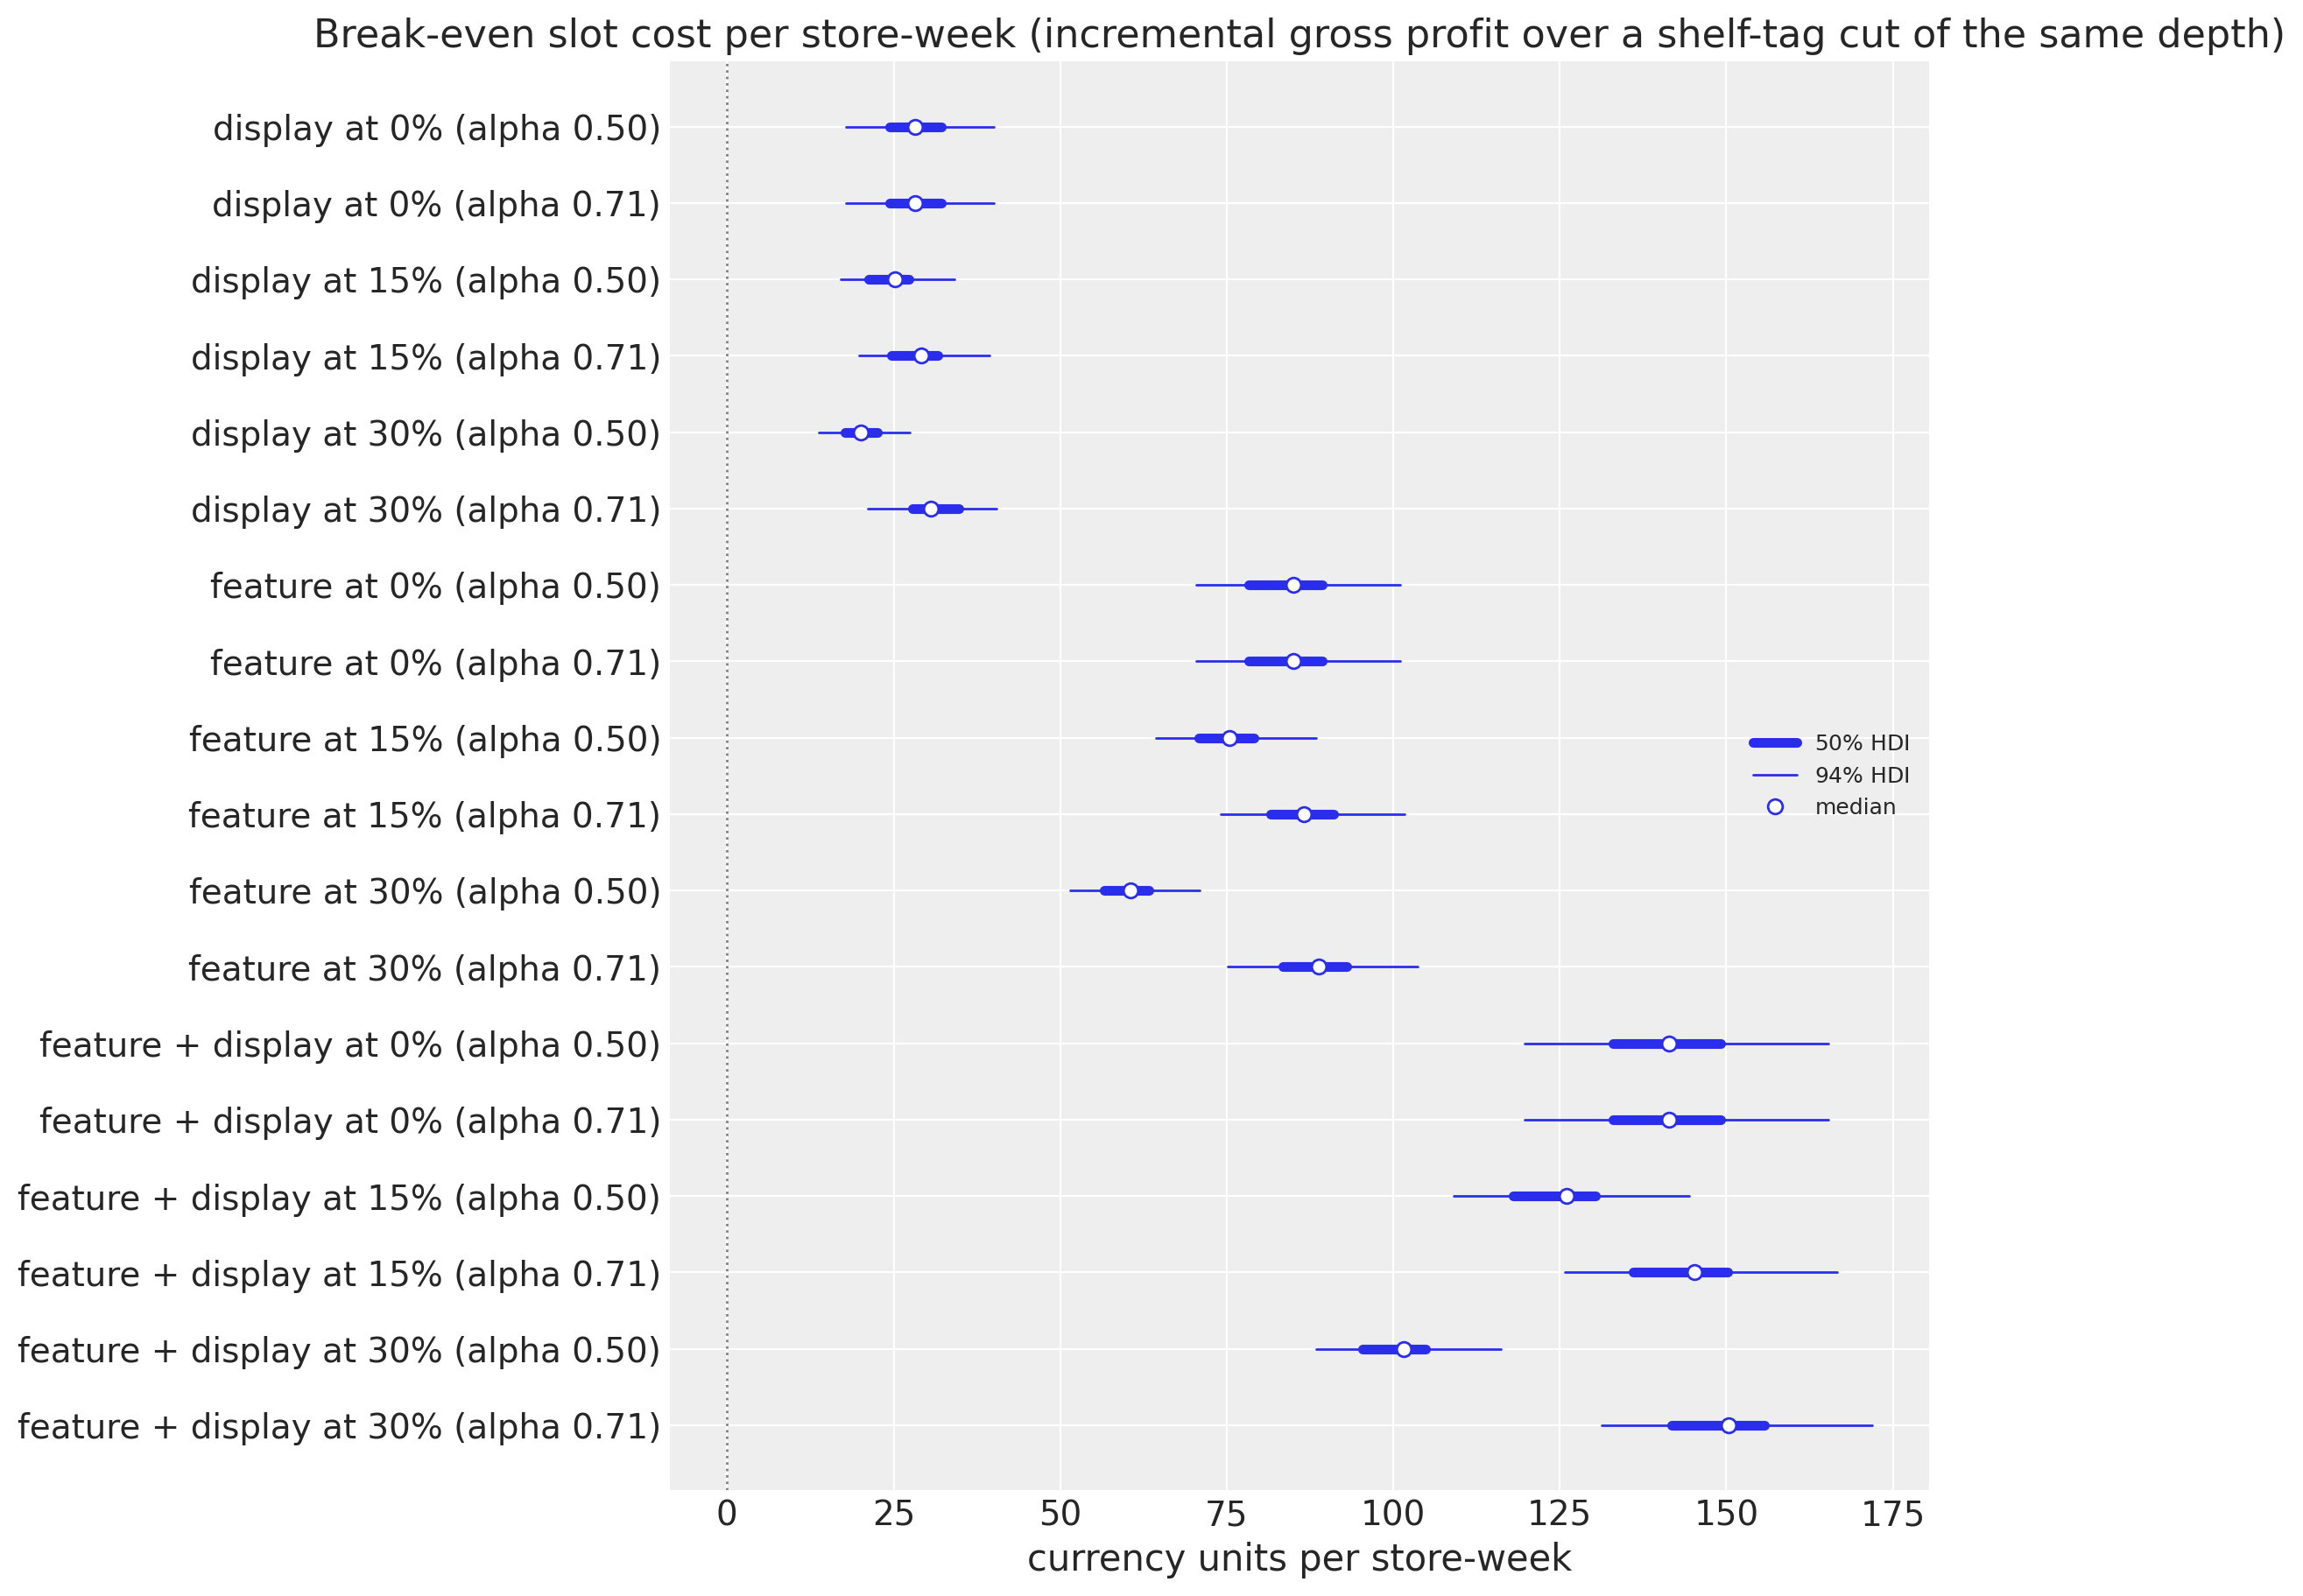

In [65]:
slot_labels = [
    f"{m} at {d:.0%} (alpha {a:.2f})"
    for m in ["display", "feature", "feature + display"]
    for d in (0.0, 0.15, 0.30)
    for a in (0.5, alpha_tilde)
]
slot_stack = np.stack(
    [
        slot_draws[(m, d, a)]
        for m in ["display", "feature", "feature + display"]
        for d in (0.0, 0.15, 0.30)
        for a in (0.5, alpha_tilde)
    ],
    axis=1,
)
fig, ax = plt.subplots(figsize=(11, 9), layout="constrained")
plot_intervals(ax, slot_labels, slot_stack)
ax.legend(handles=interval_handles[:3], loc="center right", fontsize=9)
ax.set(
    title="Break-even slot cost per store-week (incremental gross profit over a shelf-tag cut of the same depth)",
    xlabel="currency units per store-week",
);

In [66]:
SLOT_LADDER = [0.0, 25.0, 50.0, 75.0, 100.0, 150.0]
slots_used = {"TPR-only": 0.0, "display": 1.0, "feature": 1.0, "feature + display": 2.0}
choice_rows = []
for alpha_value in (0.5, alpha_tilde):
    for slot_cost in SLOT_LADDER:
        stacks, names = [baseline_mu], ["no promotion"]
        for mechanics_name in MECHANICS:
            curve = (
                profit_curve(mechanics_name, alpha_value)
                - N_EVENT_WEEKS * n_stores * slots_used[mechanics_name] * slot_cost
            )
            stacks.append(curve)
            names.extend([mechanics_name] * len(DEPTH_GRID))
        choice_set = np.concatenate([stacks[0][:, None], *stacks[1:]], axis=1)
        best_names = np.asarray(names)[choice_set.argmax(axis=1)]
        row: dict[str, float | str] = {"alpha": alpha_value, "cost per slot": slot_cost}
        for name in ["no promotion", *MECHANICS]:
            row[f"P({name} optimal)"] = float(np.mean(best_names == name))
        choice_rows.append(row)
pl.DataFrame(choice_rows)

alpha,cost per slot,P(no promotion optimal),P(TPR-only optimal),P(display optimal),P(feature optimal),P(feature + display optimal)
0.5,0.0,0.0,0.0,0.0,0.0,1.0
0.5,25.0,0.0,0.0,0.0,0.0,1.0
0.5,50.0,0.0,0.0,0.0,0.265,0.735
0.5,75.0,0.097,0.0,0.0,0.85725,0.04575
0.5,100.0,0.9555,0.0,0.0,0.0445,0.0
0.5,150.0,1.0,0.0,0.0,0.0,0.0
0.710882,0.0,0.0,0.0,0.0,0.0,1.0
0.710882,25.0,0.0,0.0,0.0,0.0,1.0
0.710882,50.0,0.0,0.0,0.0,0.1055,0.8945
0.710882,75.0,0.0455,0.00025,0.0,0.8715,0.08275


### Store by store

The break-even shares are computable per store because the model has no cross-store terms, so the per-store decisions are separable. The figure shows the category break-even share of the feature-with-display mechanics per store, brand-only and with cannibalization, ordered by the number of identifying weeks of the store; the table prints, per store, the probability that a cut pays at the nominal and at the break-even funding share. Where the intervals are wide, the store's decision is genuinely uncertain, and it is the partial pooling of the store-level elasticities that keeps the intervals from being prior-dominated.

The store table and the figure show the spread:

- At the nominal share the probability that the cut pays is below $0.35$ in every store and below $0.02$ in fifteen of them.
- At the break-even share it ranges from $0.00$ to $1.00$: the upscale stores 2513, 11993 and 2277 sit at $0.03$ or less, the mainstream stores 19265 and 25027 above $0.99$.
- The store-level break-even shares (brand-only medians from $0.53$ to $0.87$, category medians from $0.57$ to $0.89$) line up by segment more than by the number of identifying weeks, and their $94\%$ HDIs are about twice as wide as the zone-level one.

In [67]:
policy_shallow, policy_deeper = ("feature + display", 0.0), ("feature + display", 0.05)
a_shallow_s, b_shallow_s = profit_parts_by_store(event_units_mu[policy_shallow], 0.0)
a_deeper_s, b_deeper_s = profit_parts_by_store(event_units_mu[policy_deeper], 0.05)
store_share_cat = (a_shallow_s - a_deeper_s) / (b_deeper_s - b_shallow_s)
a_shallow_b, b_shallow_b = profit_parts_by_store(
    event_units_mu[policy_shallow], 0.0, brand_only=True
)
a_deeper_b, b_deeper_b = profit_parts_by_store(
    event_units_mu[policy_deeper], 0.05, brand_only=True
)
store_share_brand = (a_shallow_b - a_deeper_b) / (b_deeper_b - b_shallow_b)
eps_store_fd = eps_store_draws - feature_depth_draws[:, None] - display_depth_draws[:, None]
store_rows = []
for j, store in enumerate(hnc_store_ids):
    row = {
        "store": store,
        "segment": store_segment[store],
        "tpr_only_weeks": int(store_tpr_weeks[j]),
    }
    for alpha_value in (0.5, alpha_tilde):
        eps_star = (1.0 - alpha_value) / G_FOCAL
        row[f"P(cut pays | alpha={alpha_value:.2f})"] = float(
            np.mean(eps_store_fd[:, j] < -eps_star)
        )
    row["alpha*_category_median"] = float(np.median(store_share_cat[:, j]))
    row["alpha*_brand_median"] = float(np.median(store_share_brand[:, j]))
    store_rows.append(row)
store_table = pl.DataFrame(store_rows).sort("tpr_only_weeks", descending=True)
store_table

store,segment,tpr_only_weeks,P(cut pays | alpha=0.50),P(cut pays | alpha=0.71),alpha*_category_median,alpha*_brand_median
9825,"""MAINSTREAM""",22,0.0025,0.9575,0.666967,0.632392
19265,"""MAINSTREAM""",20,0.34775,1.0,0.573566,0.528595
2281,"""UPSCALE""",19,0.0,0.61425,0.751862,0.697736
25027,"""MAINSTREAM""",17,0.1705,0.99975,0.586479,0.553858
25021,"""VALUE""",15,0.10075,0.99125,0.648283,0.577343
2513,"""UPSCALE""",14,0.0,0.0175,0.839245,0.814681
23349,"""VALUE""",13,0.0045,0.92275,0.675589,0.640883
21479,"""VALUE""",12,0.00025,0.7605,0.693553,0.6784
4259,"""VALUE""",11,0.0105,0.86725,0.708092,0.644411
21237,"""MAINSTREAM""",10,0.004,0.954,0.676426,0.632472


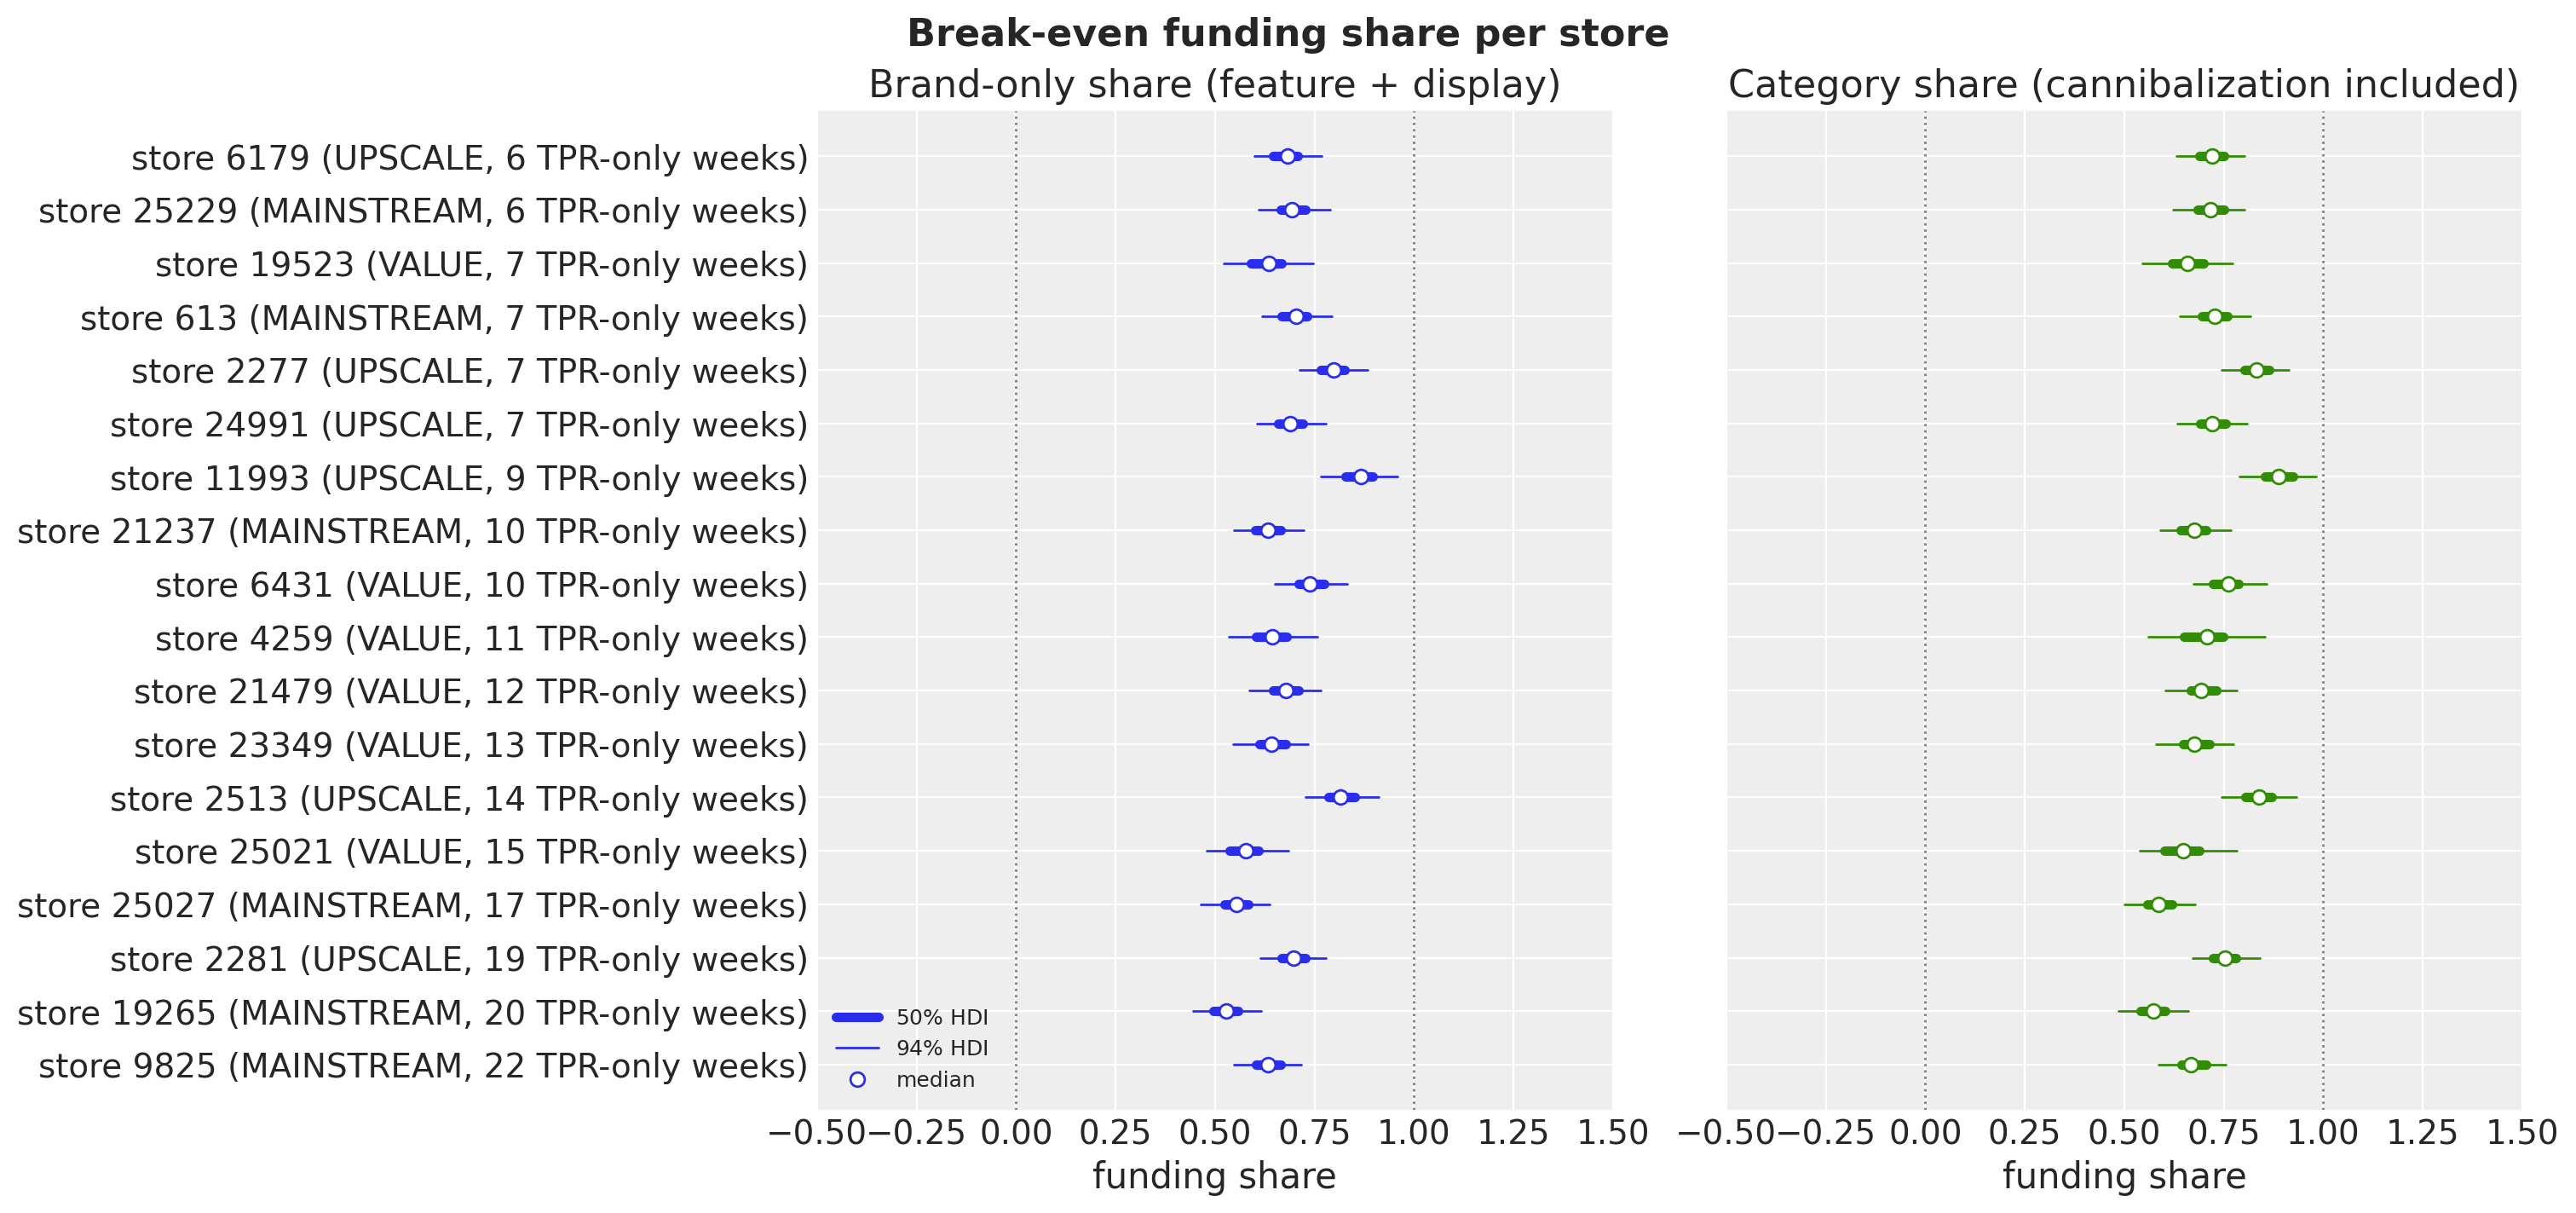

In [68]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 7), sharey=True, layout="constrained")
store_labels_ordered = [
    f"store {hnc_store_ids[j]} ({store_segment[hnc_store_ids[j]]}, {store_tpr_weeks[j]} TPR-only weeks)"
    for j in store_order
]
plot_intervals(axes[0], store_labels_ordered, store_share_brand[:, store_order])
axes[0].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].set(title="Brand-only share (feature + display)", xlabel="funding share", xlim=(-0.5, 1.5))
plot_intervals(axes[1], store_labels_ordered, store_share_cat[:, store_order], color="C2")
axes[1].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[1].set(
    title="Category share (cannibalization included)", xlabel="funding share", xlim=(-0.5, 1.5)
)
axes[0].legend(handles=interval_handles[:3], loc="lower left", fontsize=9)
fig.suptitle("Break-even funding share per store", fontsize=16, fontweight="bold");

## Risk: the go/no-go

Expected profit is not the whole decision. The incremental profit of a policy against no promotion, $\Delta\Pi_r(a) = \Pi_r(a) - \Pi_r(a_0)$, is computed here on the sampled event paths, so it carries the demand noise as well as the parameter and level-path uncertainty, draw by draw under common random numbers (the same posterior draw, the same level path, coupled demand draws). That coupling is an assumption the data cannot identify: the potential outcomes of the same week under two policies are never observed together. We report the conditional value at risk at the $10\%$ level, $\text{CVaR}_{0.10}$, the mean of the worst tenth of the draws ([Rockafellar and Uryasev, 2000](https://doi.org/10.21314/JOR.2000.038)), with two standard errors: an iid bootstrap over the draws and the between-chain error of the per-chain values, which respects the autocorrelation of the NUTS draws. A different-key baseline, in which the level path and the demand noise are redrawn while the parameters are shared, is printed as a sensitivity to the coupling, not as a bound. The go/no-go rule is $\text{CVaR}_{0.10}(\Delta\Pi) \ge 0$: in the worst tenth of the worlds the promotion still does not lose money on average, before any slot cost. Where the expected profit is flat across depths, this is the tie-breaker. A remark: the CVaR of the level $\Pi$ instead of the increment answers a different question, the total event risk.

The risk table, the sensitivity and the go/no-go ladder say the following:

- At a zero slot cost every policy with a feature or a display has a positive $\text{CVaR}_{0.10}$ and a probability of loss of $0.00$, so the go/no-go is a go at the break-even share for all of them; the shelf-tag cuts are the only policies with a negative downside.
- The three deepest feature-with-display cells have $\text{CVaR}_{0.10}$ values of $4{,}392$, $4{,}403$ and $4{,}400$, with bootstrap standard errors of $12$ to $13$ and between-chain standard errors of $6$ to $8$, so the risk measure does not separate them either; the deepest cell has the highest expected increment, $5{,}263$, and the earlier table gave it a $63\%$ chance of being the best cell.
- The coupling matters for the downside number: the committed policy has a $\text{CVaR}_{0.10}$ of $4{,}339$ under common random numbers and $3{,}952$ with a redrawn baseline, a difference the data cannot arbitrate.
- The slot-cost ladder turns the histogram into a decision: with slots at $25$ per store-week the committed event still has a probability of loss of $0.00$ at both shares; at $50$ the probability is $0.11$ at the nominal share and $0.00$ at the break-even share; at $75$ it is $1.00$ and $0.73$.

In [69]:
n_chains = 4


def incremental_paths(
    policy: tuple[str, float], alpha_value: float
) -> Float[np.ndarray, " sample"]:
    """Incremental event profit of a policy over no promotion, per draw, on the sampled paths."""
    return event_profit(event_units_paths[policy], policy[1], alpha_value) - event_profit(
        event_units_paths[BASELINE], 0.0, alpha_value
    )


def cvar(draws: Float[np.ndarray, " sample"], level: float = 0.10) -> float:
    """Mean of the lowest ``level`` share of the draws."""
    ordered = np.sort(draws)
    return float(ordered[: max(1, int(np.floor(level * ordered.size)))].mean())


def cvar_bootstrap_se(draws: Float[np.ndarray, " sample"], n_boot: int = 2_000) -> float:
    """Estimate the standard error of the CVaR with an iid bootstrap over the draws."""
    boot_rng = np.random.default_rng(seed=0)
    resampled = boot_rng.choice(draws, size=(n_boot, draws.size), replace=True)
    lowest = np.sort(resampled, axis=1)[:, : int(np.floor(0.10 * draws.size))]
    return float(lowest.mean(axis=1).std(ddof=1))


def cvar_chain_se(draws: Float[np.ndarray, " sample"]) -> float:
    """Estimate the standard error of the CVaR from the spread of the per-chain values."""
    if n_chains < 2:
        return float("nan")
    per_chain = np.array([cvar(chain) for chain in draws.reshape(n_chains, -1)])
    return float(per_chain.std(ddof=1) / np.sqrt(n_chains))


risk_rows = []
for policy in policies:
    if policy == BASELINE:
        continue
    delta = incremental_paths(policy, alpha_tilde)
    risk_rows.append(
        {
            "mechanics": policy[0],
            "depth": policy[1],
            "expected_increment": float(delta.mean()),
            "P(loss)": float(np.mean(delta < 0)),
            "cvar_10": cvar(delta),
        }
    )
risk_table = pl.DataFrame(risk_rows).sort("expected_increment", descending=True)
top_policies = [
    (row["mechanics"], row["depth"]) for row in risk_table.head(3).iter_rows(named=True)
]
for policy in top_policies:
    delta = incremental_paths(policy, alpha_tilde)
    print(
        f"{policy[0]} at {policy[1]:.0%}: CVaR10 {cvar(delta):,.0f} | bootstrap se {cvar_bootstrap_se(delta):,.0f} | "
        f"between-chain se {cvar_chain_se(delta):,.0f}"
    )
risk_table.head(10)

feature + display at 40%: CVaR10 4,400 | bootstrap se 13 | between-chain se 8
feature + display at 35%: CVaR10 4,403 | bootstrap se 12 | between-chain se 6


feature + display at 30%: CVaR10 4,392 | bootstrap se 12 | between-chain se 6


mechanics,depth,expected_increment,P(loss),cvar_10
"""feature + display""",0.4,5263.055091,0.0,4400.175597
"""feature + display""",0.35,5217.502863,0.0,4402.791111
"""feature + display""",0.3,5182.392866,0.0,4391.721151
"""feature + display""",0.25,5155.341689,0.0,4378.410548
"""feature + display""",0.2,5135.639616,0.0,4359.728478
"""feature + display""",0.15,5122.948226,0.0,4338.612252
"""feature + display""",0.1,5115.035875,0.0,4315.730318
"""feature + display""",0.0,5113.553921,0.0,4273.552736
"""feature + display""",0.05,5112.227595,0.0,4295.985766
"""feature""",0.0,3068.963931,0.0,2522.549936


In [70]:
committed = ("feature + display", 0.15)
rng_key, key_alt = random.split(rng_key)
out_alt = scenario_draws(
    key_alt, nuts_model, posterior, y_train, policy_covariates(0.0, *MECHANICS["TPR-only"])
)
baseline_alt_units = np.asarray(out_alt["forecast"], dtype=np.float32)[:, EVENT_OFFSETS, :].sum(
    axis=1
)
delta_common = incremental_paths(committed, alpha_tilde)
delta_alt = event_profit(event_units_paths[committed], committed[1], alpha_tilde) - event_profit(
    baseline_alt_units, 0.0, alpha_tilde
)
print(
    f"{committed[0]} at {committed[1]:.0%}, alpha {alpha_tilde:.2f}: "
    f"CVaR10 with common random numbers {cvar(delta_common):,.0f} | "
    f"with a redrawn baseline {cvar(delta_alt):,.0f} | P(loss) "
    f"{np.mean(delta_common < 0):.2f} vs {np.mean(delta_alt < 0):.2f}"
)

feature + display at 15%, alpha 0.71: CVaR10 with common random numbers 4,339 | with a redrawn baseline 3,952 | P(loss) 0.00 vs 0.00


In [71]:
go_rows = []
for slot_cost in SLOT_LADDER:
    total_slot_cost = N_EVENT_WEEKS * n_stores * slots_used[committed[0]] * slot_cost
    for alpha_value in (0.5, alpha_tilde):
        delta = incremental_paths(committed, alpha_value) - total_slot_cost
        go_rows.append(
            {
                "cost per slot": slot_cost,
                "alpha": alpha_value,
                "expected increment": float(delta.mean()),
                "P(loss)": float(np.mean(delta < 0)),
                "cvar_10": cvar(delta),
            }
        )
pl.DataFrame(go_rows)

cost per slot,alpha,expected increment,P(loss),cvar_10
0.0,0.5,4073.783472,0.0,3426.271506
0.0,0.710882,5122.948226,0.0,4338.612252
25.0,0.5,2273.783472,0.0,1626.271506
25.0,0.710882,3322.948226,0.0,2538.612252
50.0,0.5,473.783472,0.107,-173.728494
50.0,0.710882,1522.948226,0.0,738.612252
75.0,0.5,-1326.216528,0.9975,-1973.728494
75.0,0.710882,-277.051774,0.7315,-1061.387748
100.0,0.5,-3126.216528,1.0,-3773.728494
100.0,0.710882,-2077.051774,0.9995,-2861.387748


best policy with CVaR10 >= 0: feature + display at 40% (expected increment 5,263)
highest expected increment: feature + display at 40% (5,263, CVaR10 4,400)


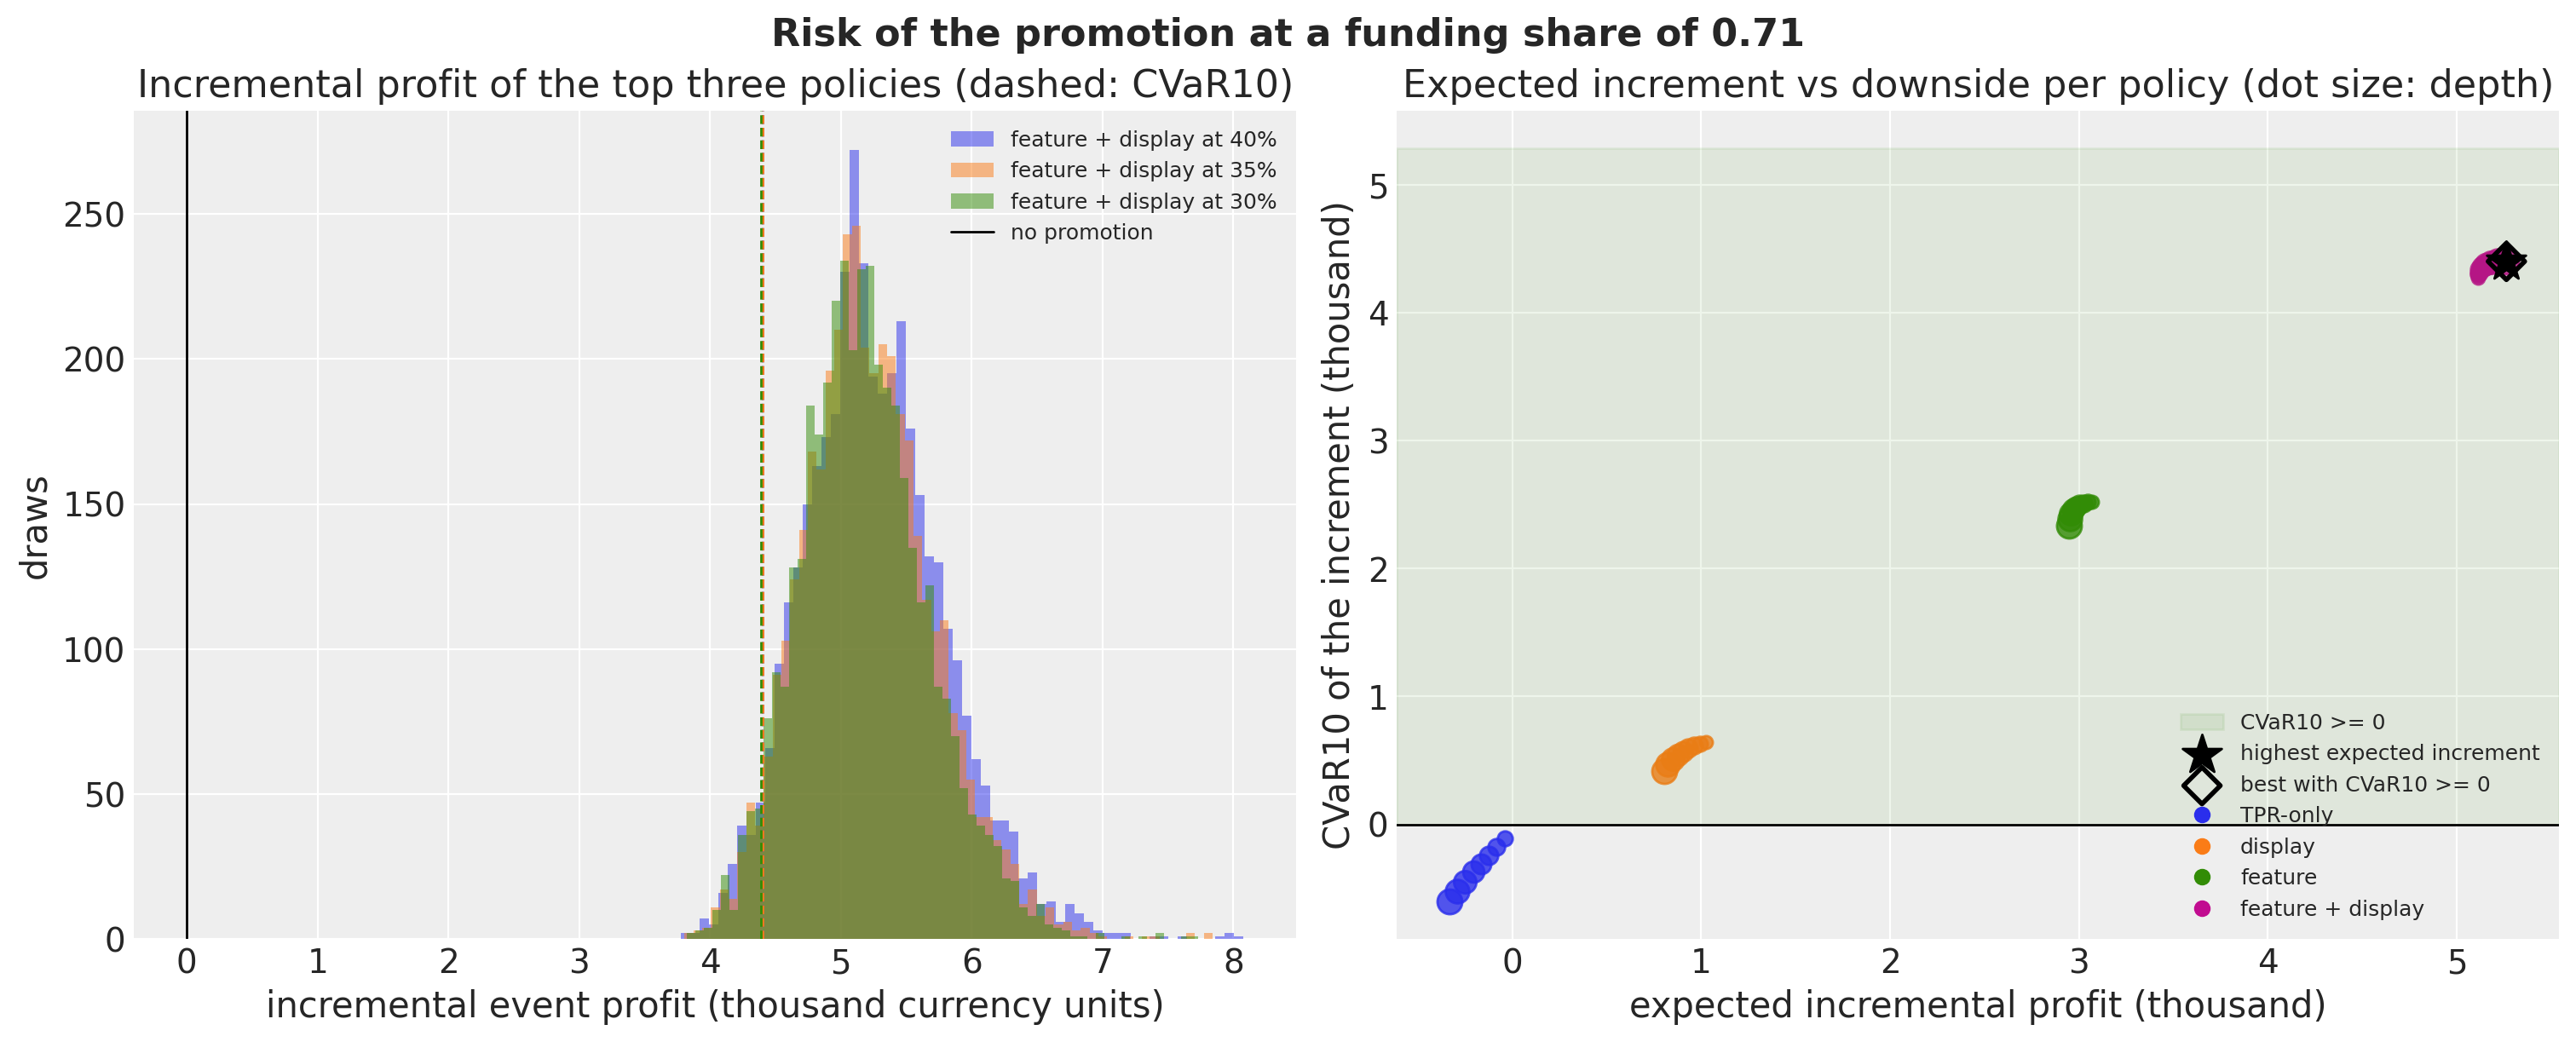

In [72]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 6), layout="constrained")
for policy, color in zip(top_policies, ("C0", "C1", "C2"), strict=True):
    delta = incremental_paths(policy, alpha_tilde) / 1_000.0
    axes[0].hist(delta, bins=60, color=color, alpha=0.5, label=f"{policy[0]} at {policy[1]:.0%}")
    axes[0].axvline(cvar(delta), color=color, linestyle="--", linewidth=1)
axes[0].axvline(0.0, color="black", linewidth=1, label="no promotion")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set(
    xlabel="incremental event profit (thousand currency units)",
    ylabel="draws",
    title="Incremental profit of the top three policies (dashed: CVaR10)",
)
colors = dict(zip(MECHANICS, ("C0", "C1", "C2", "C3"), strict=True))
for row in risk_table.iter_rows(named=True):
    axes[1].scatter(
        row["expected_increment"] / 1_000.0,
        row["cvar_10"] / 1_000.0,
        color=colors[row["mechanics"]],
        s=30 + 200 * row["depth"],
        alpha=0.8,
    )
feasible = risk_table.filter(pl.col("cvar_10") >= 0)
best_unconstrained = risk_table.row(0, named=True)
best_feasible = (
    feasible.sort("expected_increment", descending=True).row(0, named=True)
    if feasible.height > 0
    else None
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].axhspan(
    0.0,
    max(0.1, float(risk_table["cvar_10"].to_numpy().max()) / 1_000.0 * 1.2),
    color="C2",
    alpha=0.08,
    label="CVaR10 >= 0",
)
axes[1].scatter(
    best_unconstrained["expected_increment"] / 1_000.0,
    best_unconstrained["cvar_10"] / 1_000.0,
    marker="*",
    s=300,
    color="black",
    label="highest expected increment",
)
if best_feasible is not None:
    axes[1].scatter(
        best_feasible["expected_increment"] / 1_000.0,
        best_feasible["cvar_10"] / 1_000.0,
        marker="D",
        s=120,
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        label="best with CVaR10 >= 0",
    )
    print(
        f"best policy with CVaR10 >= 0: {best_feasible['mechanics']} at {best_feasible['depth']:.0%} "
        f"(expected increment {best_feasible['expected_increment']:,.0f})"
    )
print(
    f"highest expected increment: {best_unconstrained['mechanics']} at {best_unconstrained['depth']:.0%} "
    f"({best_unconstrained['expected_increment']:,.0f}, CVaR10 {best_unconstrained['cvar_10']:,.0f})"
)
axes[1].legend(
    handles=[
        *axes[1].get_legend_handles_labels()[0],
        *[
            mlines.Line2D([], [], color=c, marker="o", linewidth=0, label=m)
            for m, c in colors.items()
        ],
    ],
    loc="lower right",
    fontsize=9,
)
axes[1].set(
    xlabel="expected incremental profit (thousand)",
    ylabel="CVaR10 of the increment (thousand)",
    title="Expected increment vs downside per policy (dot size: depth)",
)
fig.suptitle(
    f"Risk of the promotion at a funding share of {alpha_tilde:.2f}",
    fontsize=16,
    fontweight="bold",
);

## Point planner vs posterior planner

The expected-value planner of stochastic programming replaces the random units by their expectation and optimizes. Profit is linear in units, so that planner and the posterior planner rank every policy identically and the value of the stochastic solution for the pricing lever alone is zero, by construction. The interesting comparison is with planners that use point estimates of the parameters:

| planner | inputs | what it ignores | printed comparison |
|---|---|---|---|
| expected value | posterior expected units | the spread of the units | nothing to print: identical ranking |
| posterior-mean plug-in | parameters at their posterior means | Jensen's gap between $\text{E}[(1-d)^{\varepsilon}]$ and $(1-d)^{\text{E}[\varepsilon]}$ | the ratio of the two, per depth |
| store least-squares plug-in | within-store least-squares elasticity, pooled least-squares mechanics multipliers | shrinkage across stores, the selection effect of choosing on noisy estimates | store-by-store decisions and the postdecision disappointment |
| posterior | the partially pooled posterior | nothing the model does not | store-by-store decisions |

The Jensen gap is small whenever the elasticity posterior is tight, and the cell below prints it. The store least-squares planner is where the difference shows. It faces two store-level decisions about the committed event, feature with display at $15\%$: whether to run the event at all against no promotion, and whether to add the cut against the same mechanics at base price. It decides each with the store's own within-store elasticity (the specification with flags, plus the focal product's least-squares depth slopes), the focal product's least-squares mechanics multipliers and the least-squares cross terms, applied to the same reference units and margins as the posterior planner. Both plans are evaluated under the posterior, stated as the evaluation measure: the posterior planner is optimal under it by construction, so the gap measures what shrinkage buys if the model is right, not an out-of-sample validation. The first decision is not a test of shrinkage, because the mechanics uplift is far larger than any elasticity error. The second one is: whether a cut pays depends on the store's elasticity against the threshold of the funding share, and the within-store estimates are noisy where the identifying weeks are few. The postdecision disappointment of [Smith and Winkler (2006)](https://doi.org/10.1287/mnsc.1050.0451), the planner's own predicted gain minus the posterior-evaluated gain over the stores it chose, is nonnegative in expectation when the planner chooses on noisy estimates, because choosing selects favorable noise; it can be negative when the point estimates are systematically pessimistic.

The planner table and the scatter show where shrinkage matters:

- The Jensen ratio is at most $1.002$ across the grid, so the posterior-mean plug-in and the posterior planner agree.
- For the decision to run the event, both planners choose all 18 stores at both shares; the least-squares planner's disappointment is negative ($-718$ and $-696$), because its own mechanics multipliers under-predict the uplift the posterior expects.
- For the decision to add the cut at the nominal share, the posterior planner adds it in no store and the least-squares planner in 3; that plan is worth $-110$ under the posterior, a disappointment of $222$.
- At the break-even share the least-squares planner adds the cut in all 18 stores and the posterior planner in 9; the least-squares plan is worth $11$ under the posterior against $162$ for the posterior plan, and the disappointment is $865$: the stores with the most extreme least-squares elasticities are the ones whose predicted gains evaporate under the posterior, the optimizer's curse in a table.
- The scatter shows it: at the break-even share nearly every store sits on or below the identity line, and the store with the largest predicted gain keeps a small part of it.

In [73]:
eps_fd_zone = eps_m_draws("feature + display")
jensen_rows = []
for d in DEPTH_GRID[1:]:
    expectation_of_power = float(np.mean((1.0 - d) ** eps_fd_zone))
    power_of_expectation = float((1.0 - d) ** np.mean(eps_fd_zone))
    jensen_rows.append(
        {
            "depth": float(d),
            "E[(1-d)^eps]": expectation_of_power,
            "(1-d)^E[eps]": power_of_expectation,
            "ratio": expectation_of_power / power_of_expectation,
        }
    )
pl.DataFrame(jensen_rows)

depth,E[(1-d)^eps],(1-d)^E[eps],ratio
0.05,1.061188,1.061167,1.000019
0.1,1.129789,1.129698,1.000081
0.15,1.207196,1.206964,1.000192
0.2,1.295168,1.2947,1.000362
0.25,1.395957,1.395118,1.000601
0.3,1.512493,1.511096,1.000924
0.35,1.648655,1.646435,1.001348
0.4,1.809685,1.806259,1.001896


In [74]:
ls_effects = dict(zip(hnc_full_ols["term"].to_list(), hnc_full_ols["coef"].to_list(), strict=True))
cross_on_focal = {
    row["units of"]: float(row[f"price of {FOCAL}"]) for row in cross_ols.iter_rows(named=True)
}
ls_eps_store = {
    store: float(store_ols[j] - ls_effects["feature_lam"] - ls_effects["display_lam"])
    for j, store in enumerate(hnc_store_ids)
}
committed_depth = committed[1]


def least_squares_units(
    reference_units: Float[np.ndarray, " n_series"], add_mechanics: bool
) -> Float[np.ndarray, " n_series"]:
    """Event units the store least-squares planner predicts for the committed policy from ``reference_units``."""
    units = np.empty(n_series)
    for n in range(n_series):
        store, product = series_ids[n].split("::")
        if product == FOCAL:
            uplift = (
                np.exp(
                    ls_effects["feature"] + ls_effects["display"] + ls_effects["feature_display"]
                )
                if add_mechanics
                else 1.0
            )
            units[n] = (
                reference_units[n] * (1.0 - committed_depth) ** ls_eps_store[int(store)] * uplift
            )
        else:
            uplift = (
                np.exp(ls_effects["sib_feature"] + ls_effects["sib_display"])
                if add_mechanics
                else 1.0
            )
            units[n] = (
                reference_units[n] * (1.0 - committed_depth) ** cross_on_focal[product] * uplift
            )
    return units


a_committed_s, b_committed_s = profit_parts_by_store(event_units_mu[committed], committed_depth)
planner_rows = []
planner_scatter: dict[float, tuple[np.ndarray, np.ndarray]] = {}
for decision_label, reference_policy, add_mechanics in [
    ("run the event vs no promotion", BASELINE, True),
    ("add the cut vs the mechanics at base price", (committed[0], 0.0), False),
]:
    reference_units_mean = event_units_mu[reference_policy].mean(axis=0)
    ls_units = least_squares_units(reference_units_mean, add_mechanics)
    a_reference_s, _ = profit_parts_by_store(event_units_mu[reference_policy], 0.0)
    a_ls, b_ls = profit_parts_by_store(ls_units[None, :], committed_depth)
    a_ls_reference, _ = profit_parts_by_store(reference_units_mean[None, :], 0.0)
    for alpha_value in (0.5, alpha_tilde):
        posterior_gain = (a_committed_s + alpha_value * b_committed_s - a_reference_s).mean(
            axis=0
        )  # (n_stores,)
        predicted_gain = (a_ls + alpha_value * b_ls - a_ls_reference)[0]
        choose_ls, choose_bayes = predicted_gain > 0, posterior_gain > 0
        planner_rows.append(
            {
                "decision": decision_label,
                "alpha": alpha_value,
                "stores chosen by least squares": int(choose_ls.sum()),
                "stores chosen by posterior": int(choose_bayes.sum()),
                "stores where they disagree": int((choose_ls != choose_bayes).sum()),
                "posterior value of least-squares plan": float((choose_ls * posterior_gain).sum()),
                "posterior value of posterior plan": float((choose_bayes * posterior_gain).sum()),
                "least-squares disappointment": float(
                    (choose_ls * (predicted_gain - posterior_gain)).sum()
                ),
            }
        )
        if not add_mechanics:
            planner_scatter[alpha_value] = (predicted_gain, posterior_gain)
pl.DataFrame(planner_rows)

decision,alpha,stores chosen by least squares,stores chosen by posterior,stores where they disagree,posterior value of least-squares plan,posterior value of posterior plan,least-squares disappointment
"""run the event vs no promotion""",0.5,18,18,0,4079.610051,4079.610051,-718.140271
"""run the event vs no promotion""",0.710882,18,18,0,5130.077241,5130.077241,-696.438115
"""add the cut vs the mechanics at base price""",0.5,3,0,3,-109.679484,0.0,221.736542
"""add the cut vs the mechanics at base price""",0.710882,18,9,9,10.697087,162.14862,864.696882


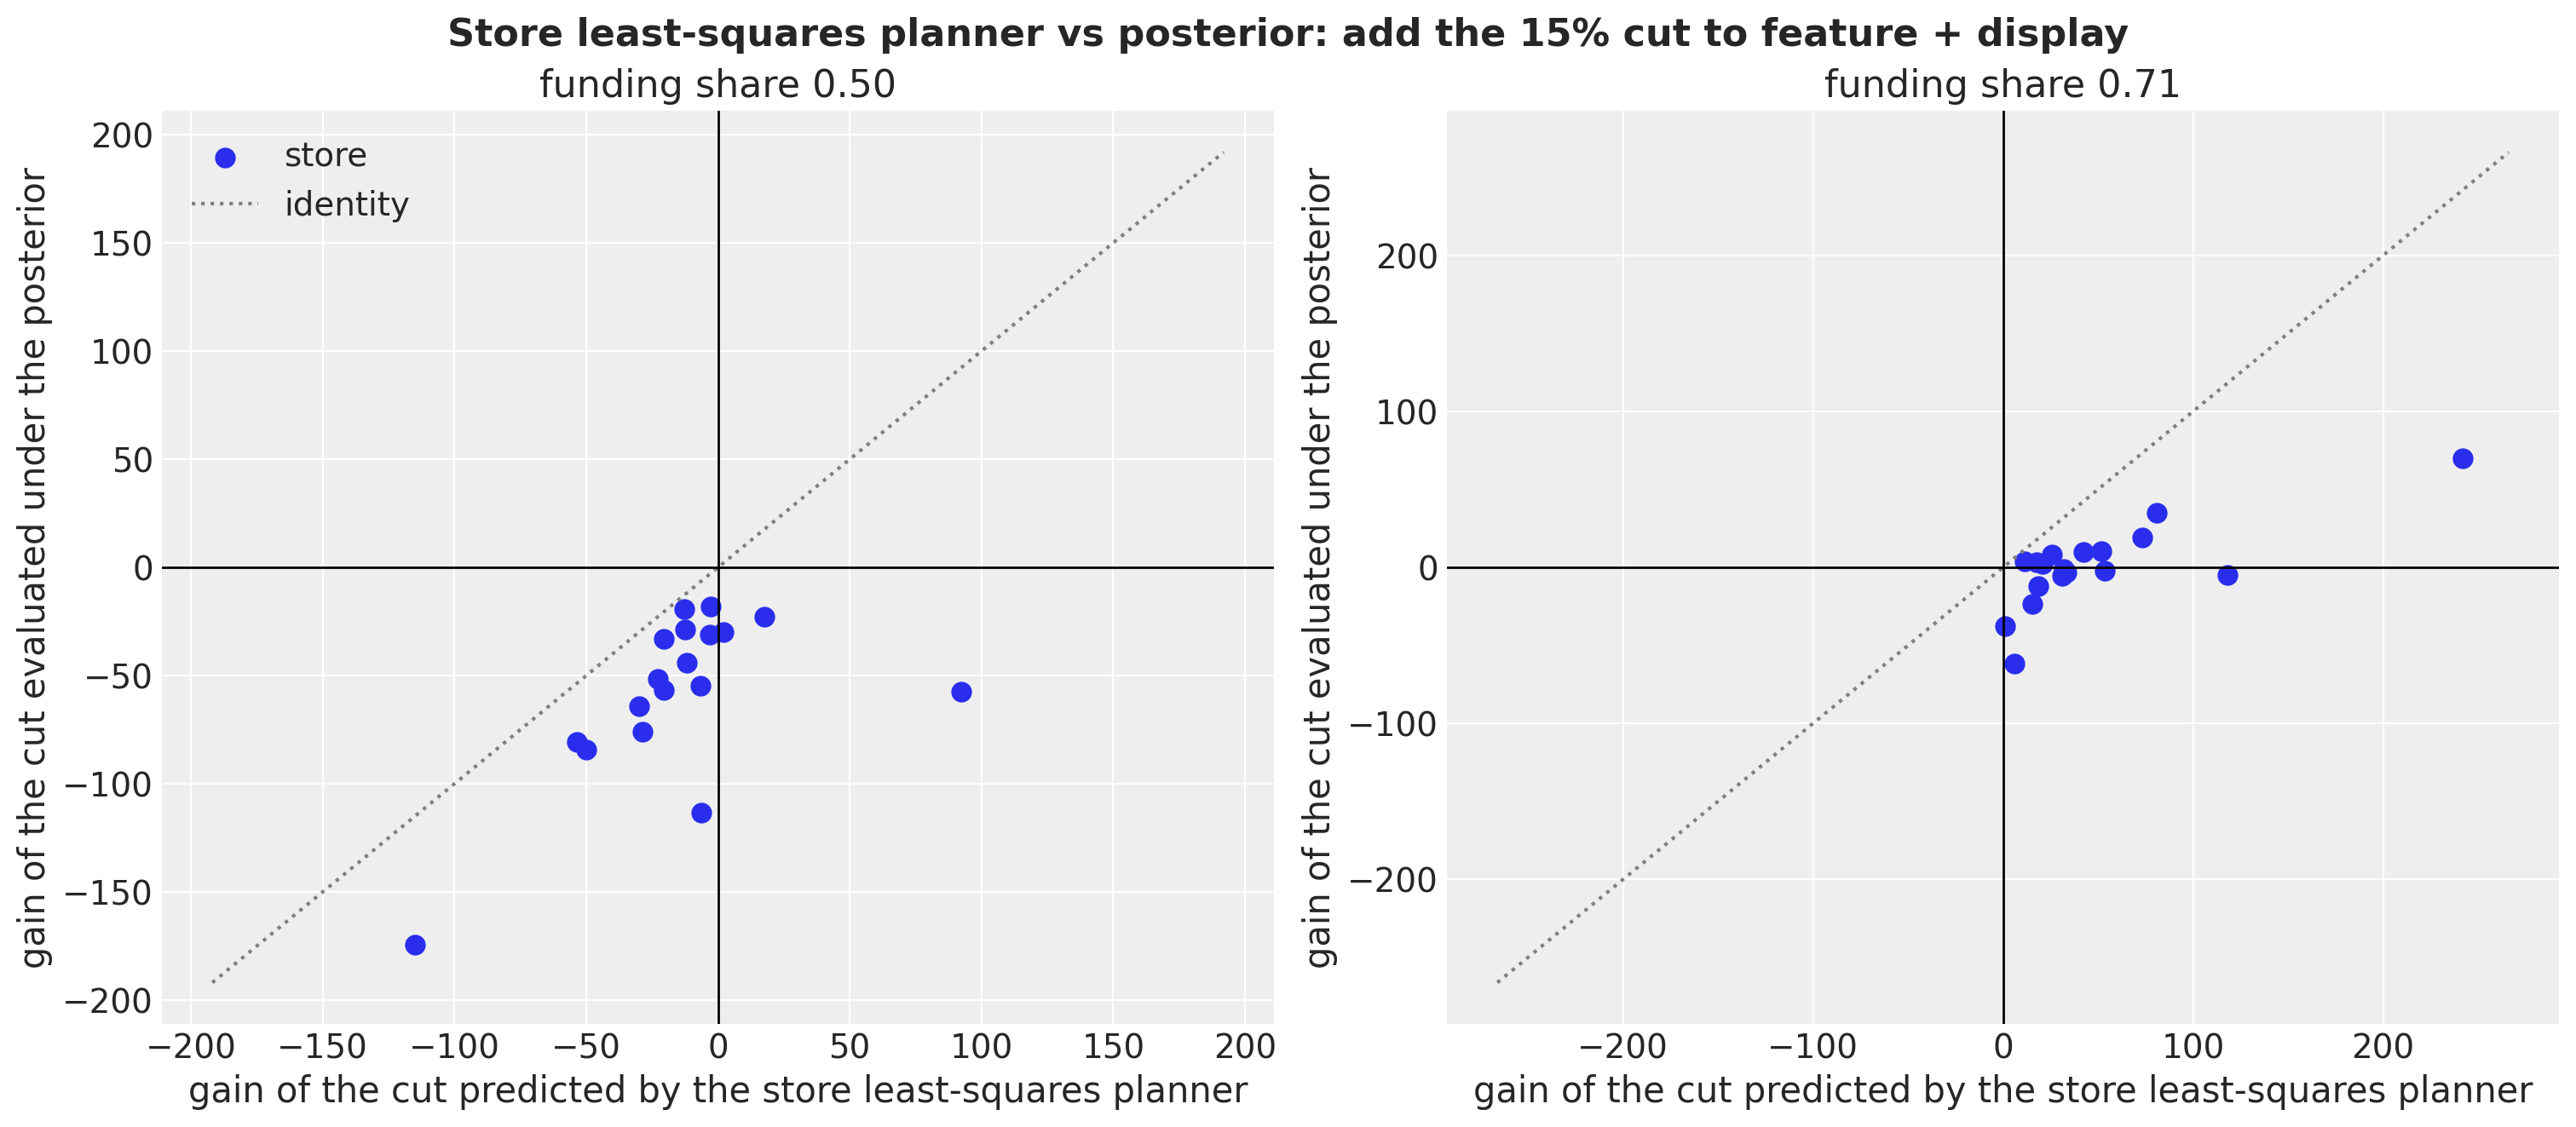

In [75]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 6.5), layout="constrained")
for ax, alpha_value in zip(axes, (0.5, alpha_tilde), strict=True):
    predicted_gain, posterior_gain = planner_scatter[alpha_value]
    ax.scatter(predicted_gain, posterior_gain, color="C0", s=60, label="store")
    limit = max(np.abs(predicted_gain).max(), np.abs(posterior_gain).max()) * 1.1
    ax.plot([-limit, limit], [-limit, limit], color="gray", linestyle=":", label="identity")
    ax.axhline(0.0, color="black", linewidth=1)
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set(
        xlabel="gain of the cut predicted by the store least-squares planner",
        ylabel="gain of the cut evaluated under the posterior",
        title=f"funding share {alpha_value:.2f}",
    )
axes[0].legend(loc="upper left")
fig.suptitle(
    f"Store least-squares planner vs posterior: add the {committed[1]:.0%} cut to {committed[0]}",
    fontsize=16,
    fontweight="bold",
);

## The promotion order

The funding and go/no-go questions belong to the category manager. The order belongs to the replenishment planner, who takes the promotion as committed: feature with display at a $15\%$ cut, the grid cell nearest the realized Thanksgiving event, under the nominal funding share of $0.5$.

### Event demand, costs and the critical fractile

Every quantity here is per store; the printed totals sum the 18 stores. Let $y_{r,t,\text{H}}$ be the sampled units of the focal product in one store in event week $t$ under the committed policy, in draw $r$. One order covers both event weeks with no mid-event replenishment, so the demand the order faces is the two-week sum of the same sampled path, which keeps the correlation between the weeks:

$$
W_r = \sum_{t \in E} y_{r,t,\text{H}}.
$$

A unit short loses the margin it would have earned. The underage cost is the promo-week unit margin at the committed depth and the nominal share, because the allowance is earned only on units sold:

$$
c_u = m_{\text{H},s}(0.15) = p_{\text{H},s}\, \big(g_{\text{H}} - 0.5 \times 0.15\big).
$$

The true underage cost is a little lower, since part of the stockout demand is recovered at the private-label margin, so the fractile below is an upper bound and the order leans high. A unit left over is carried and sold later at the regular margin, because cereal is shelf-stable, so only the holding cost is lost. The overage cost is a holding share $\eta$ of the unit cost, and a realistic $\eta$ is small:

$$
c_o = \eta\, c_{\text{H},s}.
$$

The critical fractile is the service level that balances the two costs. Both costs scale with the base price, so it is the same in every store:

$$
\kappa = \frac{c_u}{c_u + c_o}.
$$

The newsvendor profit of an order $Q$ against a demand $W$ earns $c_u$ on every unit sold and pays $c_o$ on every unit left over, with $(x)^+ = \max(x, 0)$:

$$
\text{prof}(Q; W) = c_u\, \min(W, Q) - c_o\, (Q - W)^+.
$$

### Three order rules

- The paths rule takes the $\kappa$-quantile of the joint event demand, the newsvendor optimum: $Q^\star = \min\{Q : \text{P}(W \le Q) \ge \kappa\}$.
- The marginal rule adds up per-week safety stocks, with $q_\kappa$ the per-week $\kappa$-quantile, and ignores the correlation between the weeks: $Q_{\text{marg}} = \sum_{t \in E} q_\kappa(y_{t,\text{H}})$.
- The mean rule orders the expected demand, which is what a point forecast delivers: $Q_{\text{mean}} = \text{E}[W]$.

### What the joint predictive is worth

The vocabulary follows [Birge and Louveaux (2011)](https://doi.org/10.1007/978-1-4614-0237-4), whose news vendor example of chapter 1 fixes it. Here $\theta$ stands for the parameters and the level path of one draw, and every expectation is over the posterior predictive of $W$.

\begin{align*}
\text{RP} &= \max_Q \text{E}[\text{prof}(Q; W)] && \text{recourse value, attained by } Q^\star \\
\text{EEV} &= \text{E}[\text{prof}(Q_{\text{mean}}; W)] && \text{expected result of the mean order} \\
\text{VSS} &= \text{RP} - \text{EEV} \ge 0 && \text{value of the stochastic solution} \\
\text{WS} &= \text{E}[c_u\, W] && \text{wait-and-see: order after seeing the demand} \\
\text{EVPI}_W &= \text{WS} - \text{RP} && \text{value of perfect information about the demand} \\
\text{EVPI}_\theta &= \text{E}_\theta\big[\max_Q \text{E}[\text{prof}(Q; W) \mid \theta]\big] - \text{RP} && \text{value of perfect information about } \theta
\end{align*}

$\text{EVPI}_W$ is a loose ceiling: it includes the irreducible demand noise, which no model removes. $\text{EVPI}_\theta$ is the tighter one, the value of knowing the parameters and the level path, computed with inner negative binomial draws per posterior draw. Two caveats:

- The inner maximum is optimistic by about one part in the number of inner draws, so RP is recomputed on the same inner draws and the difference is not Monte Carlo noise.
- RP, VSS and both ceilings are maxima on the evaluation draws, so we also print a split-half VSS: the rule is chosen on one half of the draws and evaluated on the other.

The sweep over $\eta$ then shows the value of the stochastic solution as a function of the cost asymmetry $c_u / c_o$. The results, from the three cells below:

- Costs and dependence: with a holding share of $0.1$ the critical fractile is $0.74$, the underage cost is $0.54$ to $0.63$ per unit across stores, and the two event weeks of a store have a correlation of $0.27$ across draws in the median store.
- Orders: the recourse value is $5{,}936$; the mean order loses $112$ against it, a value of the stochastic solution of $1.9\%$ of RP ($116$ on the split-half check); the marginal rule loses only $5$.
- Why the marginal rule loses little: its per-week quantiles add up to an order above the joint quantile in 17 of the 18 stores, by $5$ to $41$ units (the remaining store orders $2$ units less), and over-ordering is cheap at a fractile of $0.74$.
- Service of the paths rule: a fill rate of $0.94$ and an expected leftover of $2{,}206$ units over the 18 stores.
- Information ceilings: perfect information about the demand itself would be worth $14.5\%$ of RP; about the parameters and the level path $5.5\%$, from 300 inner draws.
- The sweep: the value of the stochastic solution is smallest, $0.1\%$ of RP, at a holding share of $0.2$, where the critical fractile of $0.59$ sits nearest the probability that demand falls below its mean, $0.54$ in the median store; it grows to $7.0\%$ at a fractile of $0.93$ and to $15.0\%$ at $0.26$, and the marginal-rule loss stays below $0.8\%$ of RP everywhere.

In [76]:
ALPHA_ORDER = 0.5
paths_committed = hnc_event_paths[committed]  # (draws, event weeks, stores)
event_demand = paths_committed.sum(axis=1)  # (draws, stores)
base_focal = base_price[hnc_series_index]
cost_focal = unit_cost[hnc_series_index]
c_u = base_focal * (G_FOCAL - (1.0 - ALPHA_ORDER) * committed_depth)
between_week_corr = np.array(
    [
        np.corrcoef(paths_committed[:, 0, j], paths_committed[:, 1, j])[0, 1]
        for j in range(n_stores)
    ]
)
print(
    f"underage cost per unit: {c_u.min():.3f} to {c_u.max():.3f} | between-week correlation "
    f"of event demand across draws, median store {np.median(between_week_corr):.2f}"
)


def integer_quantile(
    draws: Float[np.ndarray, " sample k"], kappa: float
) -> Float[np.ndarray, " k"]:
    """Smallest integer order with ``P(W <= Q) >= kappa`` under the empirical distribution of the draws."""
    return np.quantile(draws, kappa, axis=0, method="inverted_cdf")


def newsvendor_profit(
    order: np.ndarray, demand: np.ndarray, underage: np.ndarray, overage: np.ndarray
) -> np.ndarray:
    """Newsvendor profit of an order against demand draws (broadcast over leading axes)."""
    return underage * np.minimum(demand, order) - overage * np.maximum(order - demand, 0.0)


def order_rules(eta: float) -> dict[str, float | np.ndarray]:
    """Orders, expected profits, VSS and the demand-information ceiling at a holding share ``eta``."""
    c_o = eta * cost_focal
    kappa = float((c_u / (c_u + c_o))[0])
    q_paths = integer_quantile(event_demand, kappa)
    q_marginal = integer_quantile(paths_committed[:, 0, :], kappa) + integer_quantile(
        paths_committed[:, 1, :], kappa
    )
    q_mean = np.rint(event_demand.mean(axis=0))
    rp = float(newsvendor_profit(q_paths, event_demand, c_u, c_o).mean(axis=0).sum())
    eev = float(newsvendor_profit(q_mean, event_demand, c_u, c_o).mean(axis=0).sum())
    marginal_value = float(
        newsvendor_profit(q_marginal, event_demand, c_u, c_o).mean(axis=0).sum()
    )
    ws = float((c_u * event_demand).mean(axis=0).sum())
    half = event_demand.shape[0] // 2
    q_half = integer_quantile(event_demand[:half], kappa)
    q_mean_half = np.rint(event_demand[:half].mean(axis=0))
    vss_split = float(
        newsvendor_profit(q_half, event_demand[half:], c_u, c_o).mean(axis=0).sum()
        - newsvendor_profit(q_mean_half, event_demand[half:], c_u, c_o).mean(axis=0).sum()
    )
    return {
        "eta": eta,
        "kappa": kappa,
        "q_paths": q_paths,
        "q_marginal": q_marginal,
        "q_mean": q_mean,
        "RP": rp,
        "EEV": eev,
        "VSS": rp - eev,
        "VSS_split_half": vss_split,
        "marginal_rule_loss": rp - marginal_value,
        "EVPI_W": ws - rp,
        "fill_rate": float(
            np.minimum(event_demand, q_paths).mean(axis=0).sum() / event_demand.mean(axis=0).sum()
        ),
        "expected_leftover": float(np.maximum(q_paths - event_demand, 0.0).mean(axis=0).sum()),
    }


nominal_eta = 0.1
nominal = order_rules(nominal_eta)
store_orders = pl.DataFrame(
    {
        "store": hnc_store_ids,
        "expected_demand": event_demand.mean(axis=0),
        "Q_paths": nominal["q_paths"],
        "Q_marginal": nominal["q_marginal"],
        "Q_mean": nominal["q_mean"],
    }
).with_columns(marginal_minus_paths=pl.col("Q_marginal") - pl.col("Q_paths"))
print(
    f"eta {nominal_eta}: kappa {nominal['kappa']:.3f} | RP {nominal['RP']:,.0f} | EEV {nominal['EEV']:,.0f} | "
    f"VSS {nominal['VSS']:,.0f} ({nominal['VSS'] / nominal['RP']:.1%} "
    f"of RP, split-half {nominal['VSS_split_half']:,.0f}) | "
    f"marginal-rule loss {nominal['marginal_rule_loss']:,.0f} | EVPI_W "
    f"{nominal['EVPI_W']:,.0f} ({nominal['EVPI_W'] / nominal['RP']:.1%})"
)
print(
    f"fill rate {nominal['fill_rate']:.3f} | expected leftover {nominal['expected_leftover']:,.0f} units | "
    f"stores with Q_marginal >= Q_paths: "
    f"{int(np.sum(np.asarray(nominal['q_marginal']) >= np.asarray(nominal['q_paths'])))} of {n_stores}"
)
store_orders

underage cost per unit: 0.535 to 0.629 | between-week correlation of event demand across draws, median store 0.27
eta 0.1: kappa 0.740 | RP 5,936 | EEV 5,824 | VSS 112 (1.9% of RP, split-half 116) | marginal-rule loss 5 | EVPI_W 863 (14.5%)
fill rate 0.943 | expected leftover 2,206 units | stores with Q_marginal >= Q_paths: 17 of 18


store,expected_demand,Q_paths,Q_marginal,Q_mean,marginal_minus_paths
25027,1310.271973,1521.0,1544.0,1310.0,23.0
21237,698.522522,790.0,810.0,699.0,20.0
25229,595.529724,667.0,690.0,596.0,23.0
19265,599.775024,679.0,697.0,600.0,18.0
9825,992.892517,1133.0,1159.0,993.0,26.0
613,419.285004,473.0,488.0,419.0,15.0
2277,1174.550537,1316.0,1357.0,1175.0,41.0
24991,1123.129761,1263.0,1295.0,1123.0,32.0
6179,555.458008,626.0,642.0,555.0,16.0
2513,478.426239,539.0,558.0,478.0,19.0


In [77]:
conc_focal = np.asarray(posterior["conc"])[:, FOCAL_INDEX]
mu_committed = hnc_event_mu[committed]  # (draws, event weeks, stores)
inner_rng = np.random.default_rng(seed=7)
inner_chunks = []
for _ in range(3):
    inner = inner_rng.negative_binomial(
        conc_focal[:, None, None, None],
        (
            conc_focal[:, None, None, None]
            / (conc_focal[:, None, None, None] + mu_committed[:, None, :, :])
        ),
        size=(n_draws, 100, N_EVENT_WEEKS, n_stores),
    )
    inner_chunks.append(inner.sum(axis=2).astype(np.float32))
inner_demand = np.concatenate(inner_chunks, axis=1)  # (draws, inner, stores)
n_inner = inner_demand.shape[1]


def theta_information_value(eta: float) -> float:
    """Value of perfect information about the parameters and the level path (inner draws), as a share of RP."""
    c_o = eta * cost_focal
    kappa = float((c_u / (c_u + c_o))[0])
    q_theta = np.quantile(inner_demand, kappa, axis=1, method="inverted_cdf")  # (draws, stores)
    profit_theta = newsvendor_profit(q_theta[:, None, :], inner_demand, c_u, c_o).mean(
        axis=1
    )  # (draws, stores)
    q_paths = integer_quantile(event_demand, kappa)
    rp_inner = (
        newsvendor_profit(q_paths[None, :], inner_demand.reshape(-1, n_stores), c_u, c_o)
        .mean(axis=0)
        .sum()
    )
    return float((profit_theta.mean(axis=0).sum() - rp_inner) / rp_inner)


print(
    f"value of perfect information about parameters and level path at eta {nominal_eta}: "
    f"{theta_information_value(nominal_eta):.1%} of RP ({n_inner} inner draws)"
)

value of perfect information about parameters and level path at eta 0.1: 5.5% of RP (300 inner draws)


In [78]:
sweep_rows = []
for eta in (0.02, 0.05, 0.1, 0.2, 0.4, 0.8):
    rules = order_rules(eta)
    sweep_rows.append(
        {
            "eta": eta,
            "kappa": rules["kappa"],
            "c_u / c_o": float((c_u / (eta * cost_focal))[0]),
            "VSS / RP": rules["VSS"] / rules["RP"],
            "VSS split-half / RP": rules["VSS_split_half"] / rules["RP"],
            "marginal-rule loss / RP": rules["marginal_rule_loss"] / rules["RP"],
            "EVPI_W / RP": rules["EVPI_W"] / rules["RP"],
            "EVPI_theta / RP": theta_information_value(eta),
        }
    )
sweep_table = pl.DataFrame(sweep_rows)
kappa_zero = float(np.median((event_demand <= event_demand.mean(axis=0)).mean(axis=0)))
print(
    f"P(W <= E[W]) median across stores: {kappa_zero:.3f} (the critical fractile at which the mean order is optimal)"
)
sweep_table

P(W <= E[W]) median across stores: 0.544 (the critical fractile at which the mean order is optimal)


eta,kappa,c_u / c_o,VSS / RP,VSS split-half / RP,marginal-rule loss / RP,EVPI_W / RP,EVPI_theta / RP
0.02,0.934366,14.236111,0.070443,0.071692,0.001718,0.048695,0.021857
0.05,0.850622,5.694444,0.043824,0.044779,0.001691,0.09251,0.037948
0.1,0.740072,2.847222,0.01887,0.019497,0.00083,0.145417,0.055345
0.2,0.587393,1.423611,0.00114,0.001289,0.000024,0.219178,0.077295
0.4,0.415822,0.711806,0.021346,0.020233,0.001265,0.314106,0.102992
0.8,0.262484,0.355903,0.150088,0.146713,0.007486,0.426959,0.131114


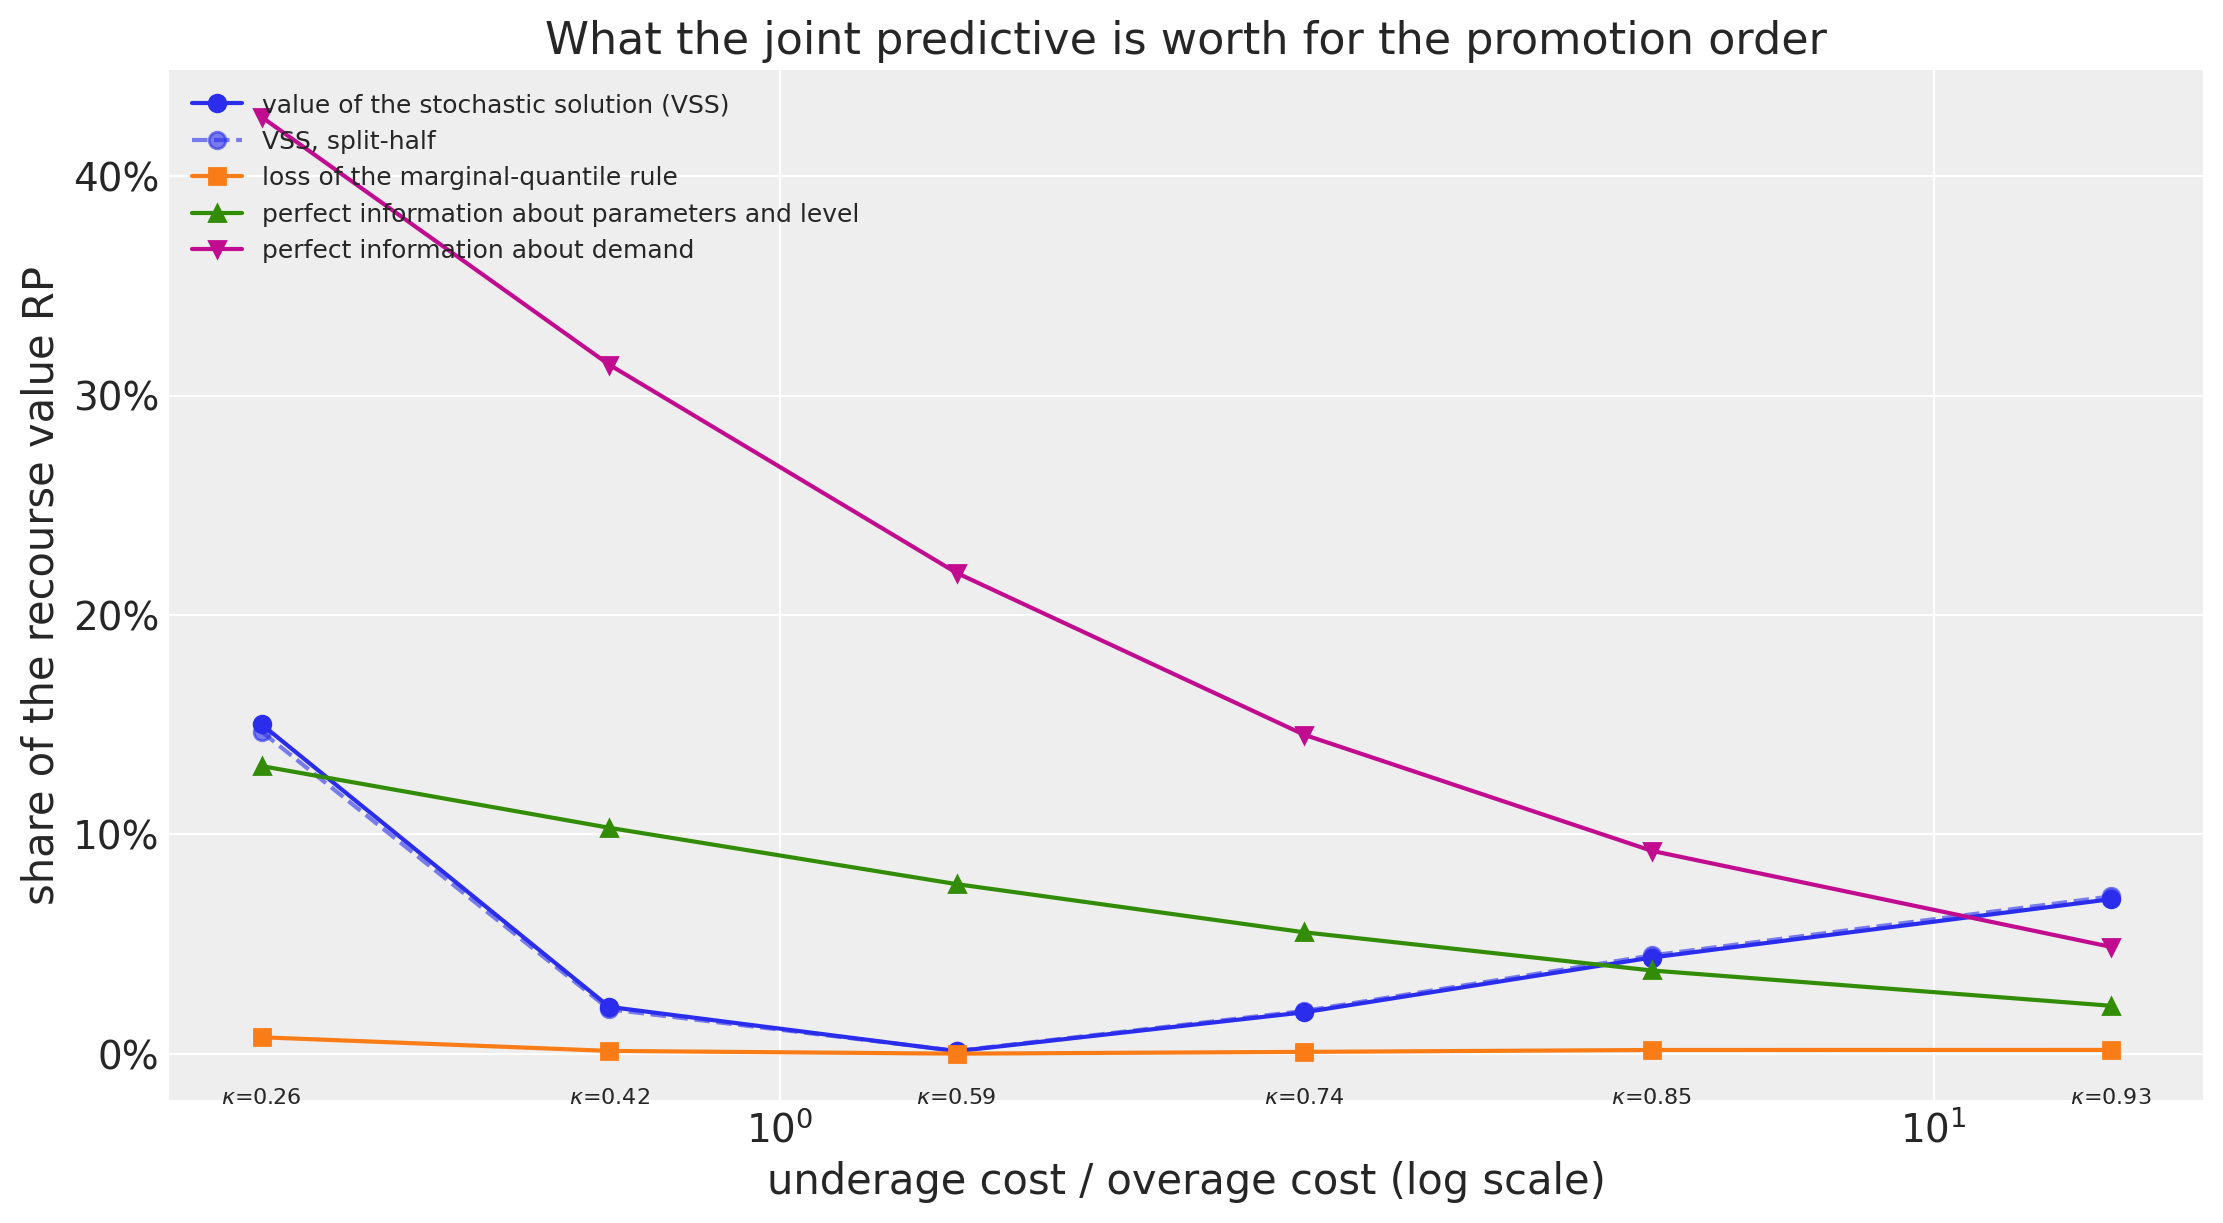

In [79]:
fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
ratio = sweep_table["c_u / c_o"].to_numpy()
ax.plot(
    ratio,
    sweep_table["VSS / RP"].to_numpy(),
    "o-",
    color="C0",
    label="value of the stochastic solution (VSS)",
)
ax.plot(
    ratio,
    sweep_table["VSS split-half / RP"].to_numpy(),
    "o--",
    color="C0",
    alpha=0.6,
    label="VSS, split-half",
)
ax.plot(
    ratio,
    sweep_table["marginal-rule loss / RP"].to_numpy(),
    "s-",
    color="C1",
    label="loss of the marginal-quantile rule",
)
ax.plot(
    ratio,
    sweep_table["EVPI_theta / RP"].to_numpy(),
    "^-",
    color="C2",
    label="perfect information about parameters and level",
)
ax.plot(
    ratio,
    sweep_table["EVPI_W / RP"].to_numpy(),
    "v-",
    color="C3",
    label="perfect information about demand",
)
for x_value, kappa in zip(ratio, sweep_table["kappa"].to_numpy(), strict=True):
    ax.annotate(
        f"$\\kappa$={kappa:.2f}",
        (x_value, 0.0),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=8,
    )
ax.set_xscale("log")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", fontsize=9)
ax.set(
    xlabel="underage cost / overage cost (log scale)",
    ylabel="share of the recourse value RP",
    title="What the joint predictive is worth for the promotion order",
);

## What the posterior buys you

The four promises of the introduction, each backed by a table above.

- The right expectation. The store-level elasticities are partially pooled (a posterior-median spread of $0.31$ across stores against $0.37$ for within-store least squares). The store least-squares planner, which is not pooled, adds the cut in 3 stores at the nominal share where the posterior adds it in none, and in all 18 at the break-even share where the posterior adds it in 9; its predicted gains exceed the posterior-evaluated ones by $222$ and $865$, the postdecision disappointment of the planner table.
- A reservation share with an interval instead of an argmax. At the nominal share the posterior puts probability $1.00$ on a falling profit curve for every mechanics, so the depth decision is a corner. What the posterior adds is the break-even funding share, $0.71$ for feature with display including cannibalization, with a $94\%$ HDI about $0.1$ wide at zone level and about twice that per store, and the event-level share of every cell, negative for a $15\%$ cut under a feature.
- A downside, and a tie-breaker where the objective is flat. Near the break-even share the expected profit moves by $1.5\%$ of the baseline across the whole depth grid, every featured policy has a positive $\text{CVaR}_{0.10}$, and the three deepest cells have downside values within their standard errors of each other; the risk table with slot costs is where the go turns into a no-go, between $50$ and $75$ per slot and store-week.
- An order from joint paths rather than from summed quantiles. The value of the stochastic solution is $1.9\%$ of the recourse value at the nominal holding share, smallest ($0.1\%$) where the critical fractile meets the probability that demand falls below its mean, and up to $15\%$ at low fractiles; the marginal-quantile rule over-orders in 17 of the 18 stores but loses below $1\%$ everywhere, because the two event weeks are only weakly correlated ($0.27$) and over-ordering is cheap at high fractiles.

## Limitations

- No experiment. Every elasticity rests on the selection-on-observables assumption drawn in the causal graph; the holdout validates the forecasting engine under the realized calendar, not the counterfactual ones.
- The joint no-promotion baseline over a holiday quarter is never observed; its units rest on the log-additivity of the model.
- Common random numbers are a coupling assumption; the different-key baseline is a sensitivity, not a bound.
- The centering values are chosen by a mean-field guide, a heuristic for the sampler's geometry, not part of the posterior; another guide could pick other values without changing any posterior quantity.
- Shelf capacity censors the sales in the strongest promotion weeks, which biases the feature-with-display uplift and the order quantities downward; the [censored demand example](censored_demand.html) shows the likelihood that would address it.
- The elasticity is promotional, not regular-price; base-price changes are absorbed by the level.
- The economics are assumptions: gross margins, a per-unit allowance, base prices frozen at the last training week (the brand-only break-even share is price-free; the category version depends on price ratios only), a holding-cost overage.
- The holdout is the holiday quarter with two earlier Decembers to learn from, and the holdout forecasts run high on average: the PIT histogram slopes downward, with $16\%$ of the cells in the lowest decile.
- Post, Quaker, the products of other sub-categories and other retailers are omitted competitors; the manufacturer's side of the deal is outside the model (General Mills also owns two of the siblings, so part of the cannibalization is internal to it); the sibling-mechanics effects are averages over any featured sibling; part of the stockout demand of the focal product spills to the private-label twin.

## Next steps

- Make the calendar a lever: add a post-promotion term and let the seasonal profile choose the event weeks.
- Replace the average sibling-mechanics effects by per-pair terms, and give the mechanics effects a store level.
- Add the censored likelihood of the [censored demand example](censored_demand.html) for the weeks at shelf capacity.
- Run a rolling backtest with `backtest` over several promotion quarters.
- Use `VISITS` and `HHS` to separate traffic from basket effects.
- Pool the orders at the distribution center and compare with the per-store orders.
- Promote the decision helpers (profit contraction, CVaR, newsvendor rules, VSS) into a package module, and let `forecast` return extra sites such as the conditional mean.

## References

- dunnhumby. [*Source files: Breakfast at the Frat*](https://www.dunnhumby.com/source-files/).
- Ghaedrahmati, E. (2025). [*Breakfast at the Frat: A Time Series Analysis*](https://doi.org/10.6084/m9.figshare.30121060). figshare copy of the dunnhumby workbook.
- Blattberg, R. C., Briesch, R., Fox, E. J. (1995). [*How Promotions Work*](https://doi.org/10.1287/mksc.14.3.G122). Marketing Science, 14(3 supplement), G122-G132.
- van Heerde, H. J., Leeflang, P. S. H., Wittink, D. R. (2000). [*The Estimation of Pre- and Postpromotion Dips with Store-Level Scanner Data*](https://doi.org/10.1509/jmkr.37.3.383.18782). Journal of Marketing Research, 37(3), 383-395.
- Bijmolt, T. H. A., van Heerde, H. J., Pieters, R. G. M. (2005). [*New Empirical Generalizations on the Determinants of Price Elasticity*](https://doi.org/10.1509/jmkr.42.2.141.62296). Journal of Marketing Research, 42(2), 141-156.
- NumPyro documentation. [*Example: Hilbert space approximation for Gaussian processes*](https://num.pyro.ai/en/stable/examples/hsgp.html) and [*Reparameterization*](https://num.pyro.ai/en/stable/reparam.html).
- Gorinova, M. I., Moore, D., Hoffman, M. D. (2020). [*Automatic Reparameterisation of Probabilistic Programs*](https://arxiv.org/abs/1906.03028). Proceedings of the 37th International Conference on Machine Learning.
- Gneiting, T., Katzfuss, M. (2014). [*Probabilistic Forecasting*](https://doi.org/10.1146/annurev-statistics-062713-085831). Annual Review of Statistics and Its Application, 1, 125-151.
- Czado, C., Gneiting, T., Held, L. (2009). [*Predictive Model Assessment for Count Data*](https://doi.org/10.1111/j.1541-0420.2009.01191.x). Biometrics, 65(4), 1254-1261.
- Rockafellar, R. T., Uryasev, S. (2000). [*Optimization of conditional value-at-risk*](https://doi.org/10.21314/JOR.2000.038). Journal of Risk, 2(3), 21-41.
- Smith, J. E., Winkler, R. L. (2006). [*The Optimizer's Curse: Skepticism and Postdecision Surprise in Decision Analysis*](https://doi.org/10.1287/mnsc.1050.0451). Management Science, 52(3), 311-322.
- Birge, J. R., Louveaux, F. (2011). [*Introduction to Stochastic Programming*](https://doi.org/10.1007/978-1-4614-0237-4). Springer.
- Related examples: [hierarchical forecasting 1](hierarchical_forecasting_1.html) (the sampled centering idiom), [fresh retail stockout](fresh_retail_stockout.html) (the model factory and the covariate-swap counterfactual), [availability TSB](availability_tsb.html) (scenario covariates), [censored demand](censored_demand.html) (the NUTS template and the censored likelihood).